**## IMPLEMENTING A GPT MODEL FROM SCRATCH TO GENERATE TEXT**

In [1]:
# Configuration dictionary containing all hyperparameters for the GPT-124M model.
# These values define the architecture, size, and behavior of the transformer model.
GPT_CONFIG_124M = {

    # Total number of unique tokens the tokenizer can recognize.
    # Each token is assigned an embedding vector during training.
    "vocab_size": 50257,

    # Maximum number of tokens the model can process at once.
    # This determines the size of the attention window (context).
    "context_length": 1024,

    # Size of each token embedding and hidden representation.
    # Every token is represented as a 768-dimensional vector.
    "emb_dim": 768,

    # Number of parallel attention heads in each Multi-Head Attention block.
    # Multiple heads allow the model to learn different relationships between tokens.
    "n_heads": 12,

    # Number of transformer blocks stacked sequentially.
    # More layers enable the model to learn more complex language patterns.
    "n_layers": 12,

    # Dropout probability used during training to reduce overfitting.
    # Randomly deactivates 10% of neurons in certain layers.
    "drop_rate": 0.1,

    # Whether to include bias terms in Query, Key, and Value projection layers.
    # GPT-2 uses bias=False for QKV projections.
    "qkv_bias": False
}

In [2]:
# Import PyTorch, the core deep learning library used to build and train neural networks.
import torch

# Import the neural network module, which provides layers such as Embedding,
# Linear, Dropout, and the base Module class.
import torch.nn as nn


# Define a simplified GPT model.
# This version focuses on the overall architecture and uses placeholder
# Transformer blocks and LayerNorm instead of their actual implementations.
class DummyGPTModel(nn.Module):

    # Constructor that initializes all model components using the configuration dictionary.
    def __init__(self, cfg):

        # Initialize the parent nn.Module class so PyTorch can track parameters.
        super().__init__()

        # Token embedding layer.
        # Converts each token ID into a dense embedding vector of size emb_dim.
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding layer.
        # Learns a unique embedding for each position in the input sequence.
        # This allows the model to understand token order.
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Dropout layer applied after adding token and positional embeddings.
        # Helps prevent overfitting during training.
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack multiple Transformer blocks sequentially.
        # In a real GPT model, each block contains self-attention and feed-forward networks.
        # Here, DummyTransformerBlock is used as a placeholder.
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Final Layer Normalization applied before prediction.
        # Helps stabilize activations and improve training.
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])

        # Output projection layer.
        # Maps hidden representations back to vocabulary space.
        # Produces one score (logit) for every token in the vocabulary.
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    # Defines how data flows through the model during inference/training.
    def forward(self, in_idx):

        # Extract batch size and sequence length from the input tensor.
        # Shape: (batch_size, seq_len)
        batch_size, seq_len = in_idx.shape

        # Convert token IDs into embedding vectors.
        # Shape: (batch_size, seq_len, emb_dim)
        tok_embeds = self.tok_emb(in_idx)

        # Create position indices [0, 1, 2, ..., seq_len-1]
        # and obtain corresponding positional embeddings.
        # Shape: (seq_len, emb_dim)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Combine token information and positional information.
        # Broadcasting automatically expands positional embeddings
        # across all sequences in the batch.
        x = tok_embeds + pos_embeds

        # Apply dropout to embeddings for regularization.
        x = self.drop_emb(x)

        # Pass embeddings through all Transformer blocks.
        # In a real GPT, contextual understanding is learned here.
        x = self.trf_blocks(x)

        # Normalize the final hidden representations.
        x = self.final_norm(x)

        # Convert hidden states into vocabulary logits.
        # Shape: (batch_size, seq_len, vocab_size)
        logits = self.out_head(x)

        # Return prediction scores for every token position.
        return logits


# Placeholder Transformer block.
# Used only to demonstrate the GPT architecture structure.
class DummyTransformerBlock(nn.Module):

    # Constructor receives configuration but does not create any layers.
    def __init__(self, cfg):

        # Initialize parent Module class.
        super().__init__()

        # No attention or feed-forward layers are implemented here.
        # This is only a placeholder.

    # Forward pass of the placeholder block.
    def forward(self, x):

        # Return the input unchanged.
        # In a real Transformer block, attention and feed-forward
        # computations would happen here.
        return x


# Placeholder Layer Normalization class.
# Mimics the interface of nn.LayerNorm without performing normalization.
class DummyLayerNorm(nn.Module):

    # Constructor accepts normalization shape and epsilon value.
    def __init__(self, normalized_shape, eps=1e-5):

        # Initialize parent Module class.
        super().__init__()

        # Parameters are included only to match the LayerNorm API.
        # No learnable weights or normalization logic are implemented.

    # Forward pass of the placeholder LayerNorm.
    def forward(self, x):

        # Return the input unchanged.
        # A real LayerNorm would normalize each embedding vector.
        return x

**### Step 1: Tokenization**

In [3]:
# Import the tiktoken library, which provides GPT-compatible tokenizers.
# GPT models cannot process raw text directly, so text must first be converted into token IDs.
import tiktoken

# Load the GPT-2 tokenizer.
# This tokenizer uses Byte Pair Encoding (BPE), the same tokenization scheme
# used by GPT-2 and many GPT-based language models.
tokenizer = tiktoken.get_encoding("gpt2")

# Create an empty list to store tokenized sentences.
# Each sentence will be converted into a tensor and added to this batch.
batch = []

# First input sentence.
txt1 = "Every effort moves you"

# Second input sentence.
txt2 = "Every day holds a"

# Tokenize the first sentence and convert the resulting token IDs into a PyTorch tensor.
# Example output: [6109, 3626, 6100, 345] (actual IDs may vary).
batch.append(torch.tensor(tokenizer.encode(txt1)))

# Tokenize the second sentence and convert the token IDs into a tensor.
batch.append(torch.tensor(tokenizer.encode(txt2)))

# Stack individual sentence tensors into a single batch tensor.
# dim=0 creates a new batch dimension.
#
# Before stacking:
# Sentence 1 → [token1, token2, token3, token4]
# Sentence 2 → [token1, token2, token3, token4]
#
# After stacking:
# [
#   [token1, token2, token3, token4],
#   [token1, token2, token3, token4]
# ]
#
# Shape: (batch_size, sequence_length)
batch = torch.stack(batch, dim=0)

# Display the final batch of token IDs.
# This tensor will be the input to the GPT model.
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


**CREATE AN INSTANCE OF DUMMY GPT MODEL**

In [4]:
# Set a fixed random seed for PyTorch.
# This ensures that random values (such as initial model weights)
# are generated consistently every time the code is run.
# Useful for reproducibility and debugging.
torch.manual_seed(123)

# Create an instance of the DummyGPTModel using the GPT-124M configuration.
# During initialization, all layers (embeddings, output layer, etc.)
# are created according to the specified hyperparameters.
model = DummyGPTModel(GPT_CONFIG_124M)

# Pass the batch of token IDs through the model.
# This triggers the forward() method and performs:
# 1. Token Embedding
# 2. Positional Embedding
# 3. Dropout
# 4. Transformer Blocks (dummy placeholders here)
# 5. Layer Normalization (dummy placeholder)
# 6. Output Projection to Vocabulary Space
#
# The result is a tensor of logits.
# Logits are unnormalized prediction scores for every token
# in the vocabulary at every position in the sequence.
logits = model(batch)

# Display the shape of the output tensor.
# Shape:
# (batch_size, sequence_length, vocab_size)
#
# For this example:
# batch_size = 2
# sequence_length = 4
# vocab_size = 50257
#
# Output shape:
# (2, 4, 50257)
print("Output shape:", logits.shape)

# Print the actual logits tensor.
# Each value represents the model's score for a particular vocabulary token.
# Higher values indicate higher confidence for that token.
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)
Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.17

**Step 2: Layer Normalization**

In [5]:
# Set a fixed random seed so that the randomly generated numbers
# and initialized weights remain the same every time the code runs.
# This makes results reproducible for learning and debugging.
torch.manual_seed(123)

# Create a sample input batch containing random values drawn
# from a standard normal distribution (mean=0, std=1).
#
# Shape: (2, 5)
# 2 = number of samples in the batch
# 5 = number of input features for each sample
#
# Example:
# [
#   [x1, x2, x3, x4, x5],
#   [x1, x2, x3, x4, x5]
# ]
batch_example = torch.randn(2, 5)  # A

# Create a simple neural network using Sequential.
# Layers are executed one after another.
#
# Layer 1: Linear(5 → 6)
# - Takes 5 input features
# - Produces 6 output features
#
# Layer 2: ReLU activation
# - Replaces negative values with 0
# - Introduces non-linearity into the network
layer = nn.Sequential(
    nn.Linear(5, 6),
    nn.ReLU()
)

# Pass the input batch through the network.
#
# Step 1:
# Linear transformation:
# y = xWᵀ + b
#
# Shape:
# (2, 5) → (2, 6)
#
# Step 2:
# ReLU activation:
# ReLU(x) = max(0, x)
#
# Negative values become 0.
out = layer(batch_example)

# Display the final output after the Linear layer and ReLU activation.
#
# Shape:
# (2, 6)
#
# Notice that all negative values have become 0 because of ReLU.
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [6]:
# Compute the mean of each sample across its feature dimension.
#
# dim=-1 means calculate the mean across the last dimension
# (the 6 output features produced by the Linear + ReLU layers).
#
# keepdim=True preserves the dimension so that the result can be
# easily broadcast during normalization later.
#
# Input shape:
# (2, 6)
#
# Output shape:
# (2, 1)
#
# Example:
# [0.0, 1.2, 0.0, 3.5, 0.8, 0.0]
# Mean = (0.0 + 1.2 + 0.0 + 3.5 + 0.8 + 0.0) / 6
mean = out.mean(dim=-1, keepdim=True)

# Compute the variance of each sample across its feature dimension.
#
# Variance measures how spread out the feature values are
# around the mean.
#
# dim=-1:
# Calculate variance across the 6 features.
#
# keepdim=True:
# Keeps the output shape as (2, 1) for broadcasting.
#
# Input shape:
# (2, 6)
#
# Output shape:
# (2, 1)
var = out.var(dim=-1, keepdim=True)

# Print the mean value for each sample in the batch.
#
# Example output:
# tensor([[0.8500],
#         [1.2300]])
#
# Each row corresponds to one sample.
print("Mean:\n", mean)

# Print the variance value for each sample in the batch.
#
# Example output:
# tensor([[1.1200],
#         [2.4500]])
#
# Larger variance indicates greater spread among feature values.
print("Variance:\n", var)

In [7]:
# Normalize the output activations using the computed mean and variance.
#
# Formula:
# x_norm = (x - mean) / sqrt(variance)
#
# Step 1: Subtract the mean
# - Centers the data around 0.
#
# Step 2: Divide by the standard deviation (sqrt(variance))
# - Scales the data so that its spread becomes approximately 1.
#
# Broadcasting automatically expands mean and variance
# from shape (2, 1) to match the shape of out (2, 6).
#
# Input shape:
# out      -> (2, 6)
# mean     -> (2, 1)
# variance -> (2, 1)
#
# Output shape:
# out_norm -> (2, 6)
out_norm = (out - mean) / torch.sqrt(var)

# Compute the mean of the normalized outputs.
#
# After normalization, the mean should be very close to 0
# for each sample.
mean = out_norm.mean(dim=-1, keepdim=True)

# Compute the variance of the normalized outputs.
#
# After normalization, the variance should be very close to 1
# for each sample.
var = out_norm.var(dim=-1, keepdim=True)

# Display the normalized activations.
#
# Positive values indicate features above the original mean.
# Negative values indicate features below the original mean.
# Values near 0 are close to the original mean.
print("Normalized layer outputs:\n", out_norm)

# Verify that normalization centered each sample around 0.
#
# Expected output:
# approximately [[0.0],
#                [0.0]]
#
# Small numerical differences may appear due to floating-point precision.
print("Mean:\n", mean)

# Verify that normalization scaled each sample to unit variance.
#
# Expected output:
# approximately [[1.0],
#                [1.0]]
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)
Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [8]:
# Configure PyTorch's printing behavior.
#
# sci_mode=False disables scientific notation when displaying tensors.
#
# Instead of:
# 5.9605e-08
#
# PyTorch will print:
# 0.000000059605
#
# This makes the values easier to read when inspecting
# means, variances, and other statistics.
torch.set_printoptions(sci_mode=False)

# Print the mean of the normalized outputs.
#
# Since we previously normalized the activations,
# the mean should be extremely close to 0.
#
# Example:
# tensor([[0.000000],
#         [0.000000]])
#
# Small non-zero values may still appear due to
# floating-point arithmetic limitations.
print("Mean:\n", mean)

# Print the variance of the normalized outputs.
#
# Since the activations were normalized,
# the variance should be very close to 1.
#
# Example:
# tensor([[1.000000],
#         [1.000000]])
#
# This confirms that the normalization step worked correctly.
print("Variance:\n", var)

Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)
Mean:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [9]:
# Define a custom Layer Normalization class.
# LayerNorm is widely used in Transformer architectures such as GPT.
# It normalizes the features of each token independently, helping
# stabilize training and improve gradient flow.
class LayerNorm(nn.Module):

    # Constructor that initializes LayerNorm parameters.
    def __init__(self, emb_dim):

        # Initialize the parent nn.Module class.
        super().__init__()

        # Small constant added to the variance before taking the square root.
        # Prevents division by zero and improves numerical stability.
        self.eps = 1e-5

        # Learnable scaling parameter (γ - gamma).
        #
        # Initially all values are 1, meaning the normalized output
        # is not scaled at the beginning.
        #
        # Shape:
        # (emb_dim,)
        #
        # Example for emb_dim=768:
        # [1, 1, 1, ..., 1]
        #
        # nn.Parameter tells PyTorch that this tensor should be
        # updated during training.
        self.scale = nn.Parameter(torch.ones(emb_dim))

        # Learnable shifting parameter (β - beta).
        #
        # Initially all values are 0, meaning no shift is applied.
        #
        # Shape:
        # (emb_dim,)
        #
        # Example:
        # [0, 0, 0, ..., 0]
        #
        # Also updated automatically during training.
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    # Defines how LayerNorm processes an input tensor.
    def forward(self, x):

        # Compute the mean across the embedding dimension.
        #
        # dim=-1 means normalize across the last dimension.
        #
        # For GPT input shape:
        # (batch_size, seq_len, emb_dim)
        #
        # The mean is computed separately for every token.
        #
        # Output shape:
        # (batch_size, seq_len, 1)
        mean = x.mean(dim=-1, keepdim=True)

        # Compute the variance across the embedding dimension.
        #
        # unbiased=False calculates the population variance,
        # which is the version used in LayerNorm implementations.
        #
        # Output shape:
        # (batch_size, seq_len, 1)
        var = x.var(
            dim=-1,
            keepdim=True,
            unbiased=False
        )

        # Normalize the input.
        #
        # Step 1: Subtract the mean
        # Step 2: Divide by the standard deviation
        #
        # eps is added for numerical stability.
        #
        # Result:
        # Mean ≈ 0
        # Variance ≈ 1
        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        # Apply learnable scale (γ) and shift (β).
        #
        # These parameters allow the model to learn the
        # most useful output distribution instead of being
        # restricted to exactly mean=0 and variance=1.
        #
        # Broadcasting automatically expands:
        #
        # scale: (emb_dim,)
        # shift: (emb_dim,)
        #
        # to match:
        # norm_x: (batch_size, seq_len, emb_dim)
        return self.scale * norm_x + self.shift

In [10]:
# Create an instance of the custom LayerNorm class.
#
# emb_dim=5 means the normalization will be performed across
# 5 features for each input sample.
#
# Internally, LayerNorm creates:
# scale (γ): [1, 1, 1, 1, 1]
# shift (β): [0, 0, 0, 0, 0]
#
# At initialization, these values do not alter the normalized output.
ln = LayerNorm(emb_dim=5)

# Pass the input batch through LayerNorm.
#
# Input shape:
# (2, 5)
#
# For each sample:
# 1. Compute mean across 5 features
# 2. Compute variance across 5 features
# 3. Normalize the features
# 4. Apply learnable scale and shift
#
# Output shape:
# (2, 5)
out_ln = ln(batch_example)

# Compute the mean of the LayerNorm output.
#
# dim=-1 means calculate the mean across the feature dimension.
#
# Since LayerNorm normalizes each sample independently,
# the mean should be very close to 0.
#
# Output shape:
# (2, 1)
mean = out_ln.mean(dim=-1, keepdim=True)

# Compute the variance of the LayerNorm output.
#
# unbiased=False is used because LayerNorm itself uses
# population variance during normalization.
#
# The variance should be very close to 1.
#
# Output shape:
# (2, 1)
var = out_ln.var(
    dim=-1,
    unbiased=False,
    keepdim=True
)

# Display the mean of each normalized sample.
#
# Expected:
# tensor([[0.0000],
#         [0.0000]])
#
# Small numerical differences may occur because of
# floating-point precision.
print("Mean:\n", mean)

# Display the variance of each normalized sample.
#
# Expected:
# tensor([[1.0000],
#         [1.0000]])
#
# This confirms that LayerNorm successfully standardized
# the feature values.
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)
Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)
Mean:
 tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


**Step 3: FEEDFORWARD NEURAL NETWORK WITH GELU ACTIVATION**

In [11]:
# Define a custom implementation of the GELU (Gaussian Error Linear Unit)
# activation function.
#
# GELU is the activation function used in GPT, BERT, and many modern
# Transformer architectures instead of ReLU.
#
# It introduces non-linearity, allowing the model to learn complex patterns.
class GELU(nn.Module):

    # Constructor for the GELU layer.
    def __init__(self):

        # Initialize the parent nn.Module class.
        super().__init__()

    # Defines how the GELU activation is applied to the input.
    def forward(self, x):

        # Compute the GELU activation using the approximation
        # employed in the original GPT implementation.
        #
        # Formula:
        #
        # GELU(x) ≈ 0.5x(1 + tanh(√(2/π)(x + 0.044715x³)))
        #
        # Unlike ReLU, GELU does not completely discard all
        # negative values. Instead, it smoothly scales them,
        # leading to better gradient flow and improved performance
        # in Transformer models.
        return 0.5 * x * (
            1 + torch.tanh(

                # Compute √(2/π), a constant used in the GELU approximation.
                torch.sqrt(torch.tensor(2.0 / torch.pi))

                *

                # Compute:
                # x + 0.044715x³
                #
                # This cubic term helps approximate the exact GELU function.
                (
                    x +
                    0.044715 * torch.pow(x, 3)
                )
            )
        )

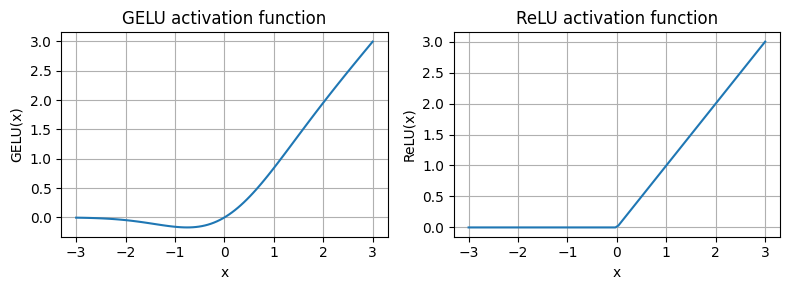

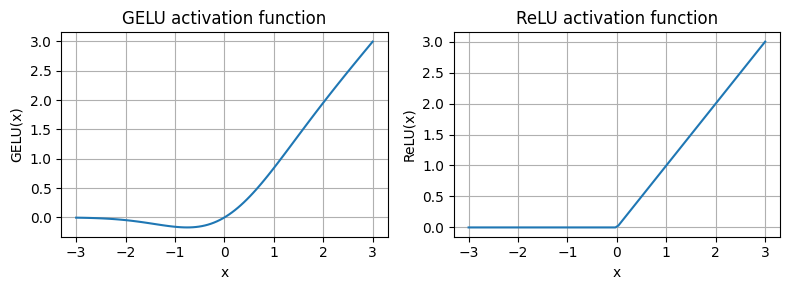

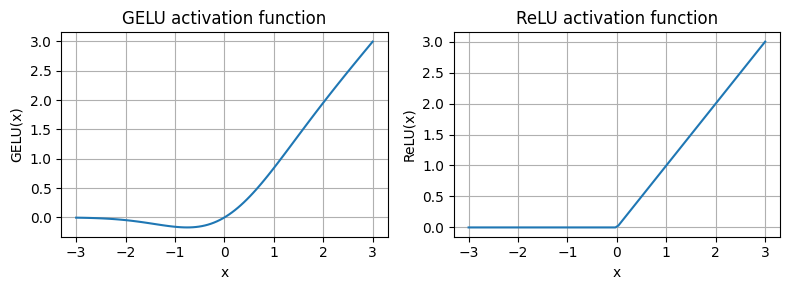

In [12]:
# Import Matplotlib, a plotting library used to visualize data and functions.
# Here it is used to compare the shapes of GELU and ReLU activation functions.
import matplotlib.pyplot as plt

# Create instances of the GELU and ReLU activation functions.
#
# GELU:
# Used in GPT and Transformer architectures.
#
# ReLU:
# Common activation function used in traditional neural networks.
gelu, relu = GELU(), nn.ReLU()

# Generate 100 evenly spaced values between -3 and 3.
#
# These values will serve as input to the activation functions.
#
# Shape:
# (100,)
#
# Example:
# [-3.00, -2.94, -2.88, ..., 2.94, 3.00]
x = torch.linspace(-3, 3, 100)

# Apply GELU to every value in x.
#
# Output shape:
# (100,)
#
# Produces the GELU activation curve.
y_gelu = gelu(x)

# Apply ReLU to every value in x.
#
# Output shape:
# (100,)
#
# Produces the ReLU activation curve.
y_relu = relu(x)

# Create a figure that will contain both plots.
#
# figsize=(8,3):
# Width = 8 inches
# Height = 3 inches
#
# Creates a compact side-by-side comparison.
plt.figure(figsize=(8, 3))

# Loop through the two activation functions and their labels.
#
# zip(...) pairs:
# (y_gelu, "GELU")
# (y_relu, "ReLU")
#
# enumerate(..., 1) generates:
# i=1 for GELU
# i=2 for ReLU
for i, (y, label) in enumerate(
    zip([y_gelu, y_relu], ["GELU", "ReLU"]),
    1
):

    # Create a subplot inside a 1-row, 2-column layout.
    #
    # (1, 2, i)
    #
    # i=1 → left plot
    # i=2 → right plot
    plt.subplot(1, 2, i)

    # Plot activation output (y) against input values (x).
    #
    # x-axis:
    # Input values
    #
    # y-axis:
    # Activated output values
    plt.plot(x, y)

    # Add a title above the current subplot.
    #
    # Examples:
    # "GELU activation function"
    # "ReLU activation function"
    plt.title(f"{label} activation function")

    # Label the x-axis.
    plt.xlabel("x")

    # Label the y-axis.
    #
    # Examples:
    # GELU(x)
    # ReLU(x)
    plt.ylabel(f"{label}(x)")

    # Display grid lines to make the curve easier to read.
    plt.grid(True)

# Automatically adjust spacing between plots.
#
# Prevents overlapping titles, labels, and axes.
plt.tight_layout()

# Render and display the figure.
# This opens a window (or displays inline in notebooks)
# containing both activation function graphs.
plt.show()

In [13]:
# Define the Feed Forward Network (FFN) used inside a Transformer block.
#
# In GPT, each Transformer block contains:
# 1. Multi-Head Self-Attention
# 2. Feed Forward Network (FFN)
#
# The FFN processes each token independently and helps the model
# learn complex non-linear patterns after the attention mechanism.
class FeedForward(nn.Module):

    # Constructor that creates the FFN layers.
    def __init__(self, cfg):

        # Initialize the parent nn.Module class.
        super().__init__()

        # Define the feed-forward network as a sequence of layers.
        #
        # Architecture:
        #
        # emb_dim
        #    ↓
        # Linear Expansion
        #    ↓
        # GELU Activation
        #    ↓
        # Linear Compression
        #    ↓
        # emb_dim
        #
        # GPT typically expands the hidden dimension by a factor of 4.
        self.layers = nn.Sequential(

            # First Linear Layer (Expansion Layer)
            #
            # Expands the embedding dimension by 4×.
            #
            # Example for GPT-2 Small:
            #
            # 768 → 3072
            #
            # This larger hidden space allows the model
            # to learn richer feature representations.
            nn.Linear(
                cfg["emb_dim"],
                4 * cfg["emb_dim"]
            ),

            # Apply GELU activation.
            #
            # Introduces non-linearity so the network can
            # learn complex transformations.
            #
            # GPT uses GELU instead of ReLU because GELU
            # provides smoother gradients and better performance.
            GELU(),

            # Second Linear Layer (Projection Layer)
            #
            # Projects the expanded representation back to
            # the original embedding size.
            #
            # Example:
            # 3072 → 768
            #
            # This ensures the output shape matches the input shape,
            # allowing residual connections in the Transformer block.
            nn.Linear(
                4 * cfg["emb_dim"],
                cfg["emb_dim"]
            ),
        )

    # Forward pass through the Feed Forward Network.
    def forward(self, x):

        # Pass the input through:
        # Linear Expansion
        # → GELU
        # → Linear Compression
        # Input shape:
        # (batch_size, seq_len, emb_dim)
        #
        # Output shape:
        # (batch_size, seq_len, emb_dim)
        return self.layers(x)

In [14]:
# Access the value associated with the key "emb_dim"
# from the GPT configuration dictionary.
# "emb_dim" represents the embedding dimension (hidden size)
# used throughout the GPT model.
# For GPT-2 Small (124M), emb_dim = 768.
print(GPT_CONFIG_124M["emb_dim"])

768


In [15]:
# Create an instance of the FeedForward Network (FFN)
# using the GPT-124M configuration.
# Internally, this creates:
# Linear(768 → 3072)
# GELU()
# Linear(3072 → 768)
# because:
# emb_dim = 768
# 4 * emb_dim = 3072
ffn = FeedForward(GPT_CONFIG_124M)

# Create a random input tensor.
# Shape:
# (2, 3, 768)
# Meaning:
# 2 = batch size (2 sequences)
# 3 = sequence length (3 tokens per sequence)
# 768 = embedding dimension
# Each token is represented by a 768-dimensional vector.
# Example visualization:
# Batch 1:
#   Token 1 → [768 values]
#   Token 2 → [768 values]
#   Token 3 → [768 values]
# Batch 2:
#   Token 1 → [768 values]
#   Token 2 → [768 values]
#   Token 3 → [768 values]
x = torch.rand(2, 3, 768)  # A

# Pass the input through the Feed Forward Network.
# Step 1:
# Linear(768 → 3072)
# Shape:
# (2, 3, 768)
# (2, 3, 3072)
# Step 2:
# GELU activation
# Shape remains:
# (2, 3, 3072)
# Step 3:
# Linear(3072 → 768)
# Shape:
# (2, 3, 3072)
# (2, 3, 768)
# The FFN transforms the token representations while
# preserving the original shape.
out = ffn(x)

# Print the shape of the FFN output.
# Expected output:
# torch.Size([2, 3, 768])
# The output shape matches the input shape because
# Transformer blocks rely on residual connections:
# output = input + FFN(input)
# Both tensors must have identical dimensions.
print(out.shape)

torch.Size([2, 3, 768])


**Step 4: SHORTCUT CONNECTIONS**

In [16]:
# Define a deep neural network to demonstrate the effect
# of shortcut (residual) connections.
#
# Shortcut connections are one of the key ideas behind
# ResNet and Transformer architectures such as GPT.
#
# They help gradients flow through deep networks and
# make training more stable.
class ExampleDeepNeuralNetwork(nn.Module):

    # Constructor that builds the network.
    def __init__(self, layer_sizes, use_shortcut):

        # Initialize the parent nn.Module class.
        super().__init__()

        # Store whether shortcut connections should be used.
        #
        # True  → enable residual connections
        # False → use a standard deep network
        self.use_shortcut = use_shortcut

        # Create a list of neural network layers.
        #
        # ModuleList registers all layers with PyTorch
        # so their parameters are tracked during training.
        self.layers = nn.ModuleList([

            # Layer 1:
            # layer_sizes[0] → layer_sizes[1]
            # followed by GELU activation
            nn.Sequential(
                nn.Linear(layer_sizes[0], layer_sizes[1]),
                GELU()
            ),

            # Layer 2:
            # layer_sizes[1] → layer_sizes[2]
            nn.Sequential(
                nn.Linear(layer_sizes[1], layer_sizes[2]),
                GELU()
            ),

            # Layer 3:
            # layer_sizes[2] → layer_sizes[3]
            nn.Sequential(
                nn.Linear(layer_sizes[2], layer_sizes[3]),
                GELU()
            ),

            # Layer 4:
            # layer_sizes[3] → layer_sizes[4]
            nn.Sequential(
                nn.Linear(layer_sizes[3], layer_sizes[4]),
                GELU()
            ),

            # Layer 5:
            # layer_sizes[4] → layer_sizes[5]
            nn.Sequential(
                nn.Linear(layer_sizes[4], layer_sizes[5]),
                GELU()
            )
        ])

    # Define the forward pass.
    def forward(self, x):

        # Iterate through all layers one by one.
        for layer in self.layers:

            # Compute the output of the current layer.
            #
            # Example:
            # x → Linear → GELU → layer_output
            layer_output = layer(x)

            # Check whether:
            # 1. Shortcut connections are enabled.
            # 2. Input and output have the same shape.
            #
            # Residual addition requires:
            #
            # x.shape == layer_output.shape
            #
            # because tensors must have identical dimensions
            # for element-wise addition.
            if self.use_shortcut and x.shape == layer_output.shape:

                # Apply shortcut (residual) connection.
                #
                # Instead of:
                # x = layer_output
                #
                # we use:
                # x = x + layer_output
                #
                # This allows information and gradients
                # to bypass the current layer directly.
                x = x + layer_output

            else:

                # If shortcut cannot be applied,
                # simply use the layer output.
                x = layer_output

        # Return the final output after all layers.
        return x

In [17]:
# Define the size of each layer in the network.
#
# Interpretation:
#
# Input Layer  : 3 neurons
# Hidden Layer1: 3 neurons
# Hidden Layer2: 3 neurons
# Hidden Layer3: 3 neurons
# Hidden Layer4: 3 neurons
# Output Layer : 1 neuron
#
# This creates the following architecture:
#
# 3 → 3 → 3 → 3 → 3 → 1
#
# Notice:
# The first four transformations preserve the dimensionality (3 → 3),
# which means shortcut connections can potentially be applied there.
#
# The final layer changes the dimension (3 → 1),
# so a shortcut connection cannot be used for that layer.
layer_sizes = [3, 3, 3, 3, 3, 1]

# Create a sample input tensor.
#
# Shape:
# (1, 3)
#
# Meaning:
# 1 = batch size
# 3 = input features
#
# Example vector:
# [1, 0, -1]
#
# This input will be passed through the network
# to study how activations and gradients behave.
sample_input = torch.tensor([[1., 0., -1.]])

# Set a fixed random seed.
#
# Neural network weights are initialized randomly.
#
# By fixing the seed, the same weights are generated
# every time the code runs, ensuring reproducibility.
#
# This is especially important when comparing:
# - Network without shortcuts
# - Network with shortcuts
#
# because both models should start from identical weights.
torch.manual_seed(123)

# Create an instance of the deep neural network.
#
# use_shortcut=False means:
#
# x → Layer1 → Layer2 → Layer3 → Layer4 → Layer5
#
# No residual/skip connections are used.
#
# The output of each layer becomes the input
# to the next layer directly.
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes,
    use_shortcut=False
)

In [18]:
# Define a helper function to inspect gradients in a neural network.
#
# The purpose of this function is to demonstrate how gradients
# propagate through a deep network during backpropagation.
#
# This is especially useful when comparing:
# - A network without shortcut connections
# - A network with shortcut connections
#
# and observing the vanishing gradient problem.
def print_gradients(model, x):

    # ---------------------------
    # Forward Pass
    # ---------------------------

    # Pass the input through the network.
    #
    # Shape:
    # x -> model -> output
    #
    # The network produces a prediction based on the input.
    output = model(x)

    # Create a target value.
    #
    # Shape:
    # (1, 1)
    #
    # We want the network's output to be as close as possible
    # to this target during training.
    target = torch.tensor([[0.]])

    # ---------------------------
    # Loss Computation
    # ---------------------------

    # Create a Mean Squared Error (MSE) loss function.
    #
    # Formula:
    #
    # MSE = (1/N) Σ(prediction - target)²
    #
    # This measures how far the model's prediction
    # is from the desired target.
    loss = nn.MSELoss()

    # Compute the loss value.
    #
    # Smaller loss:
    # prediction ≈ target
    #
    # Larger loss:
    # prediction far from target
    loss = loss(output, target)

    # ---------------------------
    # Backward Pass
    # ---------------------------

    # Compute gradients using backpropagation.
    #
    # PyTorch automatically calculates:
    #
    # ∂Loss/∂Weight
    #
    # for every trainable parameter in the network.
    #
    # These gradients are stored in:
    #
    # param.grad
    loss.backward()

    # ---------------------------
    # Gradient Inspection
    # ---------------------------

    # Iterate through all trainable parameters
    # in the model.
    for name, param in model.named_parameters():

        # Only inspect weight matrices.
        #
        # Skip bias vectors to keep the output concise.
        if 'weight' in name:

            # Compute the mean absolute gradient.
            #
            # param.grad:
            # contains gradients for every weight.
            #
            # abs():
            # removes positive/negative signs.
            #
            # mean():
            # gives an overall measure of gradient size.
            #
            # Larger value:
            # stronger learning signal.
            #
            # Smaller value:
            # weaker learning signal.
            print(
                f"{name} has gradient mean of "
                f"{param.grad.abs().mean().item()}"
            )

In [19]:
# Call the helper function to inspect gradients
# in the network that DOES NOT use shortcut connections.
#
# Arguments:
#
# model_without_shortcut
#     → Deep neural network without residual connections.
#
# sample_input
#     → Input tensor:
#       [[ 1., 0., -1. ]]
#
# This function will:
#
# 1. Perform a forward pass through the network.
# 2. Compute the prediction.
# 3. Calculate MSE loss against the target [[0.]].
# 4. Perform backpropagation using loss.backward().
# 5. Print the mean absolute gradient of each weight matrix.
#
# The goal is to observe how gradients behave
# in a deep network without shortcut connections.
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031
layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031
layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [20]:
# Reset the random seed to 123.
#
# This ensures that the new model starts with exactly
# the same randomly initialized weights as the previous
# model_without_shortcut.
#
# By keeping the weights identical, any difference in
# gradient behavior can be attributed solely to the
# shortcut connections.
torch.manual_seed(123)

# Create a deep neural network with shortcut
# (residual) connections enabled.
#
# During the forward pass:
#
# if x.shape == layer_output.shape:
#     x = x + layer_output
#
# This allows information and gradients to bypass
# intermediate layers through shortcut paths.
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes,
    use_shortcut=True
)

# Compute and print gradient statistics.
#
# This function will:
#
# 1. Run a forward pass.
# 2. Compute MSE loss.
# 3. Perform backpropagation.
# 4. Print the mean absolute gradient for each weight matrix.
#
# The goal is to compare these gradients with those
# from model_without_shortcut.
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694108307361603
layers.2.0.weight has gradient mean of 0.3289699852466583
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472
layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694108307361603
layers.2.0.weight has gradient mean of 0.3289699852466583
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


**Step 5: CODING ATTENTION AND LINEAR LAYERS IN A TRANSFORMER BLOCK**

In [21]:
# Configuration dictionary containing all hyperparameters for the GPT-124M model.
# These values define the architecture, size, and behavior of the transformer model.
GPT_CONFIG_124M = {

    # Total number of unique tokens the tokenizer can recognize.
    # Each token is assigned an embedding vector during training.
    "vocab_size": 50257,

    # Maximum number of tokens the model can process at once.
    # This determines the size of the attention window (context).
    "context_length": 1024,

    # Size of each token embedding and hidden representation.
    # Every token is represented as a 768-dimensional vector.
    "emb_dim": 768,

    # Number of parallel attention heads in each Multi-Head Attention block.
    # Multiple heads allow the model to learn different relationships between tokens.
    "n_heads": 12,

    # Number of transformer blocks stacked sequentially.
    # More layers enable the model to learn more complex language patterns.
    "n_layers": 12,

    # Dropout probability used during training to reduce overfitting.
    # Randomly deactivates 10% of neurons in certain layers.
    "drop_rate": 0.1,

    # Whether to include bias terms in Query, Key, and Value projection layers.
    # GPT-2 uses bias=False for QKV projections.
    "qkv_bias": False
}

In [22]:
# Custom implementation of Layer Normalization used in GPT.
# It normalizes each token's embedding vector independently.
class LayerNorm(nn.Module):

    # Initialize LayerNorm parameters.
    def __init__(self, emb_dim):
        super().__init__()

        # Small constant added to variance for numerical stability.
        self.eps = 1e-5

        # Learnable scaling parameter (γ).
        # Starts as all ones so normalized values remain unchanged initially.
        self.scale = nn.Parameter(torch.ones(emb_dim))

        # Learnable shifting parameter (β).
        # Starts as all zeros so no shift is applied initially.
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    # Forward pass for LayerNorm.
    def forward(self, x):

        # Compute mean across embedding dimension.
        mean = x.mean(dim=-1, keepdim=True)

        # Compute variance across embedding dimension.
        # unbiased=False calculates population variance.
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        # Normalize input so that mean ≈ 0 and variance ≈ 1.
        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        # Apply learnable scale and shift.
        return self.scale * norm_x + self.shift


# Custom implementation of GELU activation.
# GPT uses GELU instead of ReLU because it provides smoother activations.
class GELU(nn.Module):

    # Initialize GELU layer.
    def __init__(self):
        super().__init__()

    # Forward pass of GELU activation.
    def forward(self, x):

        # Approximate GELU formula used in GPT.
        #
        # GELU(x) ≈ 0.5x(1 + tanh(√(2/π)(x + 0.044715x³)))
        #
        # Smoothly scales positive and negative values.
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


# Feed Forward Network (FFN) used inside every Transformer block.
# Performs non-linear transformation after self-attention.
class FeedForward(nn.Module):

    # Initialize FFN layers.
    def __init__(self, cfg):
        super().__init__()

        # FFN architecture:
        #
        # emb_dim
        #    ↓
        # 4 × emb_dim (Expansion)
        #    ↓
        # GELU Activation
        #    ↓
        # emb_dim (Contraction)
        #
        # Example for GPT-2 Small:
        # 768 → 3072 → 768
        self.layers = nn.Sequential(

            # Expand embedding dimension by 4×.
            nn.Linear(
                cfg["emb_dim"],
                4 * cfg["emb_dim"]
            ),  # Expansion

            # Apply non-linear activation.
            GELU(),  # Activation

            # Project back to original embedding size.
            nn.Linear(
                4 * cfg["emb_dim"],
                cfg["emb_dim"]
            ),  # Contraction
        )

    # Forward pass through FFN.
    def forward(self, x):

        # Pass input through:
        # Linear → GELU → Linear
        return self.layers(x)

In [23]:
import torch
import torch.nn as nn


class MultiHeadAttention(nn.Module):
    def __init__(
        self,
        d_in,
        d_out,
        context_length,
        dropout,
        num_heads,
        qkv_bias=False
    ):
        super().__init__()

        # Ensure output dimension can be evenly divided among heads
        assert d_out % num_heads == 0, \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads

        # Dimension handled by each attention head
        self.head_dim = d_out // num_heads

        # Learnable projections for Query, Key, and Value
        self.W_query = nn.Linear(
            d_in, d_out, bias=qkv_bias
        )
        self.W_key = nn.Linear(
            d_in, d_out, bias=qkv_bias
        )
        self.W_value = nn.Linear(
            d_in, d_out, bias=qkv_bias
        )

        # Final projection after concatenating all heads
        self.out_proj = nn.Linear(
            d_out, d_out
        )

        # Dropout applied to attention weights
        self.dropout = nn.Dropout(dropout)

        # Causal mask (prevents looking into the future)
        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(context_length, context_length),
                diagonal=1
            )
        )

    def forward(self, x):

        # Input shape:
        # (batch_size, num_tokens, d_in)
        b, num_tokens, d_in = x.shape

        # Create Queries, Keys, and Values
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        # ----------------------------------------
        # Split into multiple heads
        # ----------------------------------------

        # Shape:
        # (batch_size, num_tokens, d_out)
        # ->
        # (batch_size, num_tokens, num_heads, head_dim)
        queries = queries.view(
            b, num_tokens,
            self.num_heads,
            self.head_dim
        )

        keys = keys.view(
            b, num_tokens,
            self.num_heads,
            self.head_dim
        )

        values = values.view(
            b, num_tokens,
            self.num_heads,
            self.head_dim
        )

        # Move head dimension forward
        #
        # (b, tokens, heads, head_dim)
        # ->
        # (b, heads, tokens, head_dim)
        queries = queries.transpose(1, 2)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)

        # ----------------------------------------
        # Compute attention scores
        # ----------------------------------------

        attn_scores = queries @ keys.transpose(2, 3)

        # Apply causal mask
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(
            mask_bool,
            -torch.inf
        )

        # Scale scores
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,
            dim=-1
        )

        # Apply dropout
        attn_weights = self.dropout(attn_weights)

        # Compute context vectors
        context_vec = attn_weights @ values

        # ----------------------------------------
        # Concatenate heads
        # ----------------------------------------

        # (b, heads, tokens, head_dim)
        # ->
        # (b, tokens, heads, head_dim)
        context_vec = context_vec.transpose(1, 2)

        # Merge heads
        context_vec = context_vec.contiguous().view(
            b,
            num_tokens,
            self.d_out
        )

        # Final linear projection
        context_vec = self.out_proj(context_vec)

        return context_vec

In [24]:
# Define a Transformer Block.
#
# This is the core building block of GPT.
#
# A GPT model is essentially a stack of multiple
# Transformer blocks:
#
# Input Embeddings
#       ↓
# Transformer Block 1
#       ↓
# Transformer Block 2
#       ↓
# ...
#       ↓
# Transformer Block N
#       ↓
# Output Head
#
# Each block contains:
# 1. Multi-Head Self-Attention
# 2. Feed Forward Network (FFN)
# 3. Layer Normalization
# 4. Residual (Shortcut) Connections
# 5. Dropout
class TransformerBlock(nn.Module):

    # Constructor that creates all components of the block.
    def __init__(self, cfg):

        # Initialize the parent nn.Module class.
        super().__init__()

        # --------------------------------------------------
        # Multi-Head Self-Attention Layer
        # --------------------------------------------------
        #
        # Responsible for allowing each token to attend
        # to other tokens in the sequence.
        #
        # Example:
        #
        # "The cat sat on the mat because it was tired."
        #
        # The word "it" can attend to "cat" and learn
        # that "it" refers to the cat.
        #
        # Input shape:
        # (batch_size, seq_len, emb_dim)
        #
        # Output shape:
        # (batch_size, seq_len, emb_dim)
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],

            # Output dimension equals input dimension
            # so residual connections can be applied.
            d_out=cfg["emb_dim"],

            # Maximum context window size.
            context_length=cfg["context_length"],

            # Number of attention heads.
            #
            # GPT-2 Small:
            # 12 heads
            num_heads=cfg["n_heads"],

            # Dropout inside attention.
            dropout=cfg["drop_rate"],

            # Whether Query, Key, and Value projections
            # use bias terms.
            qkv_bias=cfg["qkv_bias"]
        )

        # --------------------------------------------------
        # Feed Forward Network (FFN)
        # --------------------------------------------------
        #
        # Performs deep non-linear processing after attention.
        #
        # Typical GPT architecture:
        #
        # 768 → 3072 → GELU → 768
        self.ff = FeedForward(cfg)

        # --------------------------------------------------
        # Layer Normalization Before Attention
        # --------------------------------------------------
        #
        # Normalizes token representations before
        # they enter the attention mechanism.
        #
        # This architecture is called:
        #
        # Pre-LayerNorm Transformer
        #
        # and is used in GPT-2 and modern LLMs.
        self.norm1 = LayerNorm(cfg["emb_dim"])

        # --------------------------------------------------
        # Layer Normalization Before FFN
        # --------------------------------------------------
        #
        # Normalizes activations before the
        # feed-forward network.
        self.norm2 = LayerNorm(cfg["emb_dim"])

        # --------------------------------------------------
        # Dropout for Residual Paths
        # --------------------------------------------------
        #
        # Randomly removes some activations during training.
        #
        # Helps prevent overfitting.
        self.drop_shortcut = nn.Dropout(
            cfg["drop_rate"]
        )

    # Forward pass through the Transformer block.
    def forward(self, x):

        # ==================================================
        # PART 1: ATTENTION SUBLAYER
        # ==================================================

        # Save the original input.
        #
        # This will later be added back through
        # a residual (shortcut) connection.
        shortcut = x

        # Apply Layer Normalization.
        #
        # Shape remains:
        # (batch_size, seq_len, emb_dim)
        x = self.norm1(x)

        # Apply Multi-Head Self-Attention.
        #
        # Each token gathers information from
        # other tokens in the sequence.
        #
        # Shape:
        # (batch_size, seq_len, emb_dim)
        x = self.att(x)

        # Apply dropout.
        #
        # Active only during training.
        x = self.drop_shortcut(x)

        # Residual (shortcut) connection.
        #
        # Instead of:
        # x = Attention(x)
        #
        # we use:
        # x = x + Attention(x)
        #
        # This improves gradient flow.
        x = x + shortcut

        # ==================================================
        # PART 2: FEED FORWARD SUBLAYER
        # ==================================================

        # Save the current representation.
        #
        # This will be used for the second
        # residual connection.
        shortcut = x

        # Normalize before FFN.
        x = self.norm2(x)

        # Feed Forward Network.
        #
        # Shape flow:
        #
        # 768 → 3072 → GELU → 768
        #
        # Applied independently to each token.
        x = self.ff(x)

        # Apply dropout.
        x = self.drop_shortcut(x)

        # Second residual connection.
        #
        # Adds the FFN output to the original input.
        x = x + shortcut

        # Return the transformed token representations.
        return x

In [25]:
# Set a fixed random seed.
#
# This ensures that:
# 1. The random input tensor is the same every run.
# 2. The TransformerBlock weights are initialized identically.
#
# This makes results reproducible for learning and debugging.
torch.manual_seed(123)

# Create a random input tensor.
#
# Shape:
# (2, 4, 768)
#
# Meaning:
#
# 2   → Batch size
#       (2 independent sequences)
#
# 4   → Sequence length
#       (4 tokens per sequence)
#
# 768 → Embedding dimension
#       (each token represented by 768 features)
#
# Visual representation:
#
# Batch 1:
#   Token1 → 768 values
#   Token2 → 768 values
#   Token3 → 768 values
#   Token4 → 768 values
#
# Batch 2:
#   Token1 → 768 values
#   Token2 → 768 values
#   Token3 → 768 values
#   Token4 → 768 values
x = torch.rand(2, 4, 768)  # A

# Create one Transformer block using the GPT-124M configuration.
#
# Internally this creates:
#
# MultiHeadAttention
# FeedForward Network
# LayerNorm #1
# LayerNorm #2
# Dropout
#
# This is one complete GPT Transformer block.
block = TransformerBlock(GPT_CONFIG_124M)

# Pass the input through the Transformer block.
#
# The block performs:
#
# Input
#   ↓
# LayerNorm
#   ↓
# Multi-Head Attention
#   ↓
# Residual Connection
#   ↓
# LayerNorm
#   ↓
# Feed Forward Network
#   ↓
# Residual Connection
#   ↓
# Output
#
# Even though the token representations are transformed,
# the overall tensor shape remains unchanged.
output = block(x)

# Print the input tensor shape.
#
# Expected:
# torch.Size([2, 4, 768])
print("Input shape:", x.shape)

# Print the output tensor shape.
#
# Expected:
# torch.Size([2, 4, 768])
#
# The output shape matches the input shape because:
#
# 1. Attention:
#    768 → 768
#
# 2. Feed Forward:
#    768 → 3072 → 768
#
# 3. Residual additions require matching dimensions.
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


**Step 6: ENTIRE GPT MODEL ARCHITECTURE IMPLEMENTATION**

In [26]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Token Embedding Layer
        # Converts each token ID into a dense vector representation.
        # This allows the model to learn semantic relationships between words/tokens.
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional Embedding Layer
        # Adds position information to token embeddings because
        # Transformers process all tokens simultaneously and do not
        # inherently know the order of words in a sequence.
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Dropout Layer
        # Randomly disables some neurons during training to reduce overfitting
        # and improve the model's ability to generalize.
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer Blocks
        # Each block contains:
        # 1. Multi-Head Self-Attention
        # 2. Feed Forward Network
        # 3. Residual Connections
        # 4. Layer Normalization
        # These blocks enable the model to learn contextual relationships
        # between tokens in the sequence.
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Final Layer Normalization
        # Stabilizes activations before generating output predictions.
        # Helps improve training convergence and model performance.
        self.final_norm = LayerNorm(cfg["emb_dim"])

        # Output Projection Layer (Language Modeling Head)
        # Converts the final hidden representation of each token
        # into logits over the entire vocabulary.
        # Each logit represents the score for a possible next token.
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        # Input shape:
        # [batch_size, sequence_length]
        batch_size, seq_len = in_idx.shape

        # Convert token IDs into embedding vectors
        # Shape: [batch_size, seq_len, emb_dim]
        tok_embeds = self.tok_emb(in_idx)

        # Generate positional embeddings for each position in the sequence
        # Shape: [seq_len, emb_dim]
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Combine token and positional embeddings
        # This gives each token both semantic meaning and position information.
        # Shape: [batch_size, seq_len, emb_dim]
        x = tok_embeds + pos_embeds

        # Apply dropout for regularization
        x = self.drop_emb(x)

        # Pass embeddings through all Transformer blocks
        # Contextual information is learned here.
        x = self.trf_blocks(x)

        # Normalize the final hidden representations
        x = self.final_norm(x)

        # Project hidden states to vocabulary logits
        # Shape: [batch_size, seq_len, vocab_size]
        logits = self.out_head(x)

        # Return raw prediction scores for each vocabulary token
        return logits

In [27]:
torch.manual_seed(123)

# Create a GPT model using the GPT-2 124M configuration
model = GPTModel(GPT_CONFIG_124M)

# Pass the input batch through the model
# The model returns logits for every token position and vocabulary token
out = model(batch)

# Display the input token IDs
print("Input batch:\n", batch)

# Output shape:
# [batch_size, sequence_length, vocab_size]
# For GPT-2 124M:
# vocab_size = 50257
print("\nOutput shape:", out.shape)

# Print the predicted logits
# Each value represents an unnormalized score for a vocabulary token
# at a specific position in the sequence.
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)
Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],


In [28]:
# Count the total number of trainable parameters in the model
# p.numel() returns the total number of elements (parameters)
# in each tensor (weights or biases).
total_params = sum(p.numel() for p in model.parameters())

# Display the result with comma separators for readability
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [29]:
# Display the shape of the token embedding matrix
# Rows   = vocabulary tokens
# Columns = embedding dimensions
print("Token embedding layer shape:", model.tok_emb.weight.shape)

# Display the shape of the output projection matrix
# Rows   = vocabulary tokens
# Columns = embedding dimensions
# This layer converts hidden representations into vocabulary logits.
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [30]:
# Calculate the number of parameters after accounting for weight tying

# The output layer (out_head) shares its weights with the token
# embedding layer in GPT-2. Therefore, we subtract the parameters
# of the output layer to avoid counting them twice.

total_params_gpt2 = total_params - sum(
    p.numel() for p in model.out_head.parameters()
)

# Display the effective number of trainable parameters
# after applying weight sharing.
print(
    f"Number of trainable parameters considering weight tying: "
    f"{total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


In [31]:
# Calculate the memory required to store all model parameters

# A) Each parameter is stored as a float32 value by default.
# A float32 occupies 4 bytes of memory.
total_size_bytes = total_params * 4

# B) Convert bytes to megabytes (MB)
# 1 MB = 1024 × 1024 bytes
total_size_mb = total_size_bytes / (1024 * 1024)

# Display the estimated model size
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


**Step 7: GENERATING TEXT FROM OUTPUT TOKENS**

In [32]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """
    Generates new tokens one at a time using a trained GPT model.

    Parameters:
    model           : Trained GPT model
    idx             : Input token IDs of shape (batch_size, sequence_length)
    max_new_tokens  : Number of new tokens to generate
    context_size    : Maximum context length supported by the model

    Returns:
    idx             : Original sequence plus generated tokens
    """

    # idx contains the current token sequence
    # Shape: (batch_size, n_tokens)
    for _ in range(max_new_tokens):

        # If the sequence becomes longer than the model's context window,
        # keep only the most recent tokens that fit within the context size.
        #
        # Example:
        # Context size = 1024
        # Current sequence length = 1200
        # Only the last 1024 tokens are used for prediction.
        idx_cond = idx[:, -context_size:]

        # Disable gradient computation since we are only generating text,
        # not training the model. This saves memory and computation.
        with torch.no_grad():

            # Forward pass through GPT model
            # Output shape:
            # (batch_size, sequence_length, vocab_size)
            logits = model(idx_cond)

        # Select predictions for the last token position only.
        # We want GPT's prediction for the next token.
        #
        # Before:
        # (batch_size, sequence_length, vocab_size)
        #
        # After:
        # (batch_size, vocab_size)
        logits = logits[:, -1, :]

        # Convert logits into probabilities using Softmax.
        # Probabilities across the vocabulary sum to 1.
        probas = torch.softmax(logits, dim=-1)

        # Select the token with the highest probability.
        #
        # Shape:
        # (batch_size, 1)
        #
        # This is called greedy decoding because the most likely
        # token is always chosen.
        idx_next = torch.argmax(
            probas,
            dim=-1,
            keepdim=True
        )

        # Append the predicted token to the existing sequence.
        #
        # Before:
        # (batch_size, n_tokens)
        #
        # After:
        # (batch_size, n_tokens + 1)
        idx = torch.cat((idx, idx_next), dim=1)

    # Return the complete sequence containing
    # both original and generated tokens.
    return idx

In [33]:
# Starting text prompt that will be given to the GPT model
start_context = "Hello, I am"

# Convert text into token IDs using the tokenizer
encoded = tokenizer.encode(start_context)

# Display the token IDs
print("encoded:", encoded)

# Convert the token IDs into a PyTorch tensor
# unsqueeze(0) adds a batch dimension at index 0
#
# Before:
# Shape = (n_tokens,)
#
# After:
# Shape = (1, n_tokens)
#
# GPT expects input in the form:
# (batch_size, sequence_length)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # A

# Display the tensor shape
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [34]:
# Switch the model to evaluation mode
# This disables training-specific behaviors such as dropout,
# ensuring consistent and deterministic text generation.
model.eval()  # A

# Generate 6 new tokens based on the starting context
out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

# Display the generated token sequence
# This includes both the original input tokens
# and the newly generated tokens.
print("Output:", out)

# Display the total number of tokens
# in the final sequence.
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [35]:
# Remove the batch dimension from the output tensor
# and convert the token IDs into a Python list.
#
# Before:
# Shape = (1, sequence_length)
#
# After squeeze(0):
# Shape = (sequence_length,)
#
# tolist() converts the tensor into a list of token IDs.
decoded_text = tokenizer.decode(
    out.squeeze(0).tolist()
)

# Convert the generated token IDs back into human-readable text
# and display the result.
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue


**LOSS FUNCTION**

In [36]:
class GPTModel(nn.Module):

    def __init__(self, cfg):

        # Call the constructor of the parent nn.Module class
        super().__init__()

        # Token embedding layer:
        # Converts each token ID into a dense vector of size emb_dim.
        # Shape: [vocab_size] → [emb_dim]
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding layer:
        # Learns a unique embedding for each position in the sequence
        # so the model can understand token order.
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Dropout layer:
        # Randomly sets some embedding values to zero during training
        # to reduce overfitting and improve generalization.
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer blocks:
        # Each block contains self-attention and feed-forward networks.
        # n_layers determines how many Transformer blocks are used.
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Final Layer Normalization:
        # Stabilizes activations before producing output logits.
        self.final_norm = LayerNorm(cfg["emb_dim"])

        # Output projection layer (Language Modeling Head):
        # Maps hidden representations back to vocabulary size.
        # Produces one score (logit) for every token in the vocabulary.
        # bias=False follows the original GPT architecture.
        self.out_head = nn.Linear(
            cfg["emb_dim"],      # Input: embedding dimension
            cfg["vocab_size"],   # Output: vocabulary size
            bias=False
        )

    def forward(self, in_idx):

        # Extract batch size and sequence length from input tensor.
        # Example: [8, 256]
        # batch_size = 8, seq_len = 256
        batch_size, seq_len = in_idx.shape

        # Convert token IDs into dense token embeddings.
        # Shape:
        # [batch_size, seq_len]
        #      ↓
        # [batch_size, seq_len, emb_dim]
        tok_embeds = self.tok_emb(in_idx)

        # Generate position indices:
        # [0, 1, 2, ..., seq_len-1]
        # and look up their positional embeddings.
        # Shape:
        # [seq_len, emb_dim]
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Add token embeddings and positional embeddings.
        # Token embedding = "what word"
        # Position embedding = "where word occurs"
        #
        # Broadcasting automatically expands pos_embeds across
        # all batches.
        #
        # Shape:
        # [batch_size, seq_len, emb_dim]
        x = tok_embeds + pos_embeds

        # Apply dropout for regularization during training.
        x = self.drop_emb(x)

        # Pass embeddings through all Transformer blocks.
        # Self-attention learns contextual relationships
        # between tokens.
        x = self.trf_blocks(x)

        # Normalize the final hidden representations.
        x = self.final_norm(x)

        # Convert hidden states into vocabulary logits.
        #
        # Shape:
        # [batch_size, seq_len, emb_dim]
        #      ↓
        # [batch_size, seq_len, vocab_size]
        #
        # Each position now contains a score for every token
        # in the vocabulary.
        logits = self.out_head(x)

        # Return logits.
        # These logits are later used in CrossEntropyLoss
        # to calculate the prediction error.
        return logits

In [37]:
import torch
# Configuration dictionary containing all hyperparameters for the GPT-124M model.
# These values define the architecture, size, and behavior of the transformer model.
GPT_CONFIG_124M = {

    # Total number of unique tokens the tokenizer can recognize.
    # Each token is assigned an embedding vector during training.
    "vocab_size": 50257,

    # Maximum number of tokens the model can process at once.
    # This determines the size of the attention window (context).
    "context_length": 1024,

    # Size of each token embedding and hidden representation.
    # Every token is represented as a 768-dimensional vector.
    "emb_dim": 768,

    # Number of parallel attention heads in each Multi-Head Attention block.
    # Multiple heads allow the model to learn different relationships between tokens.
    "n_heads": 12,

    # Number of transformer blocks stacked sequentially.
    # More layers enable the model to learn more complex language patterns.
    "n_layers": 12,

    # Dropout probability used during training to reduce overfitting.
    # Randomly deactivates 10% of neurons in certain layers.
    "drop_rate": 0.1,

    # Whether to include bias terms in Query, Key, and Value projection layers.
    # GPT-2 uses bias=False for QKV projections.
    "qkv_bias": False
}
# Set the random seed for reproducibility
# Using the same seed ensures that weight initialization
# and any other random operations produce identical results
# every time the code is run.
torch.manual_seed(123)

# Create an instance of the GPT model using the
# configuration specified in GPT_CONFIG_124M.
#
# This initializes:
# - Token embeddings
# - Positional embeddings
# - Transformer blocks
# - Layer normalization
# - Output projection layer
#
# The model weights are randomly initialized.
model = GPTModel(GPT_CONFIG_124M)

# Switch the model to evaluation mode.
#
# Effects:
# - Dropout is disabled.
# - Model behaves deterministically.
# - Used during inference/testing.
#
# If dropout remained active, some neurons would be
# randomly dropped on every forward pass, causing
# different outputs each time.
model.eval()

# Semicolon (;) suppresses unnecessary output in notebooks.

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

In [38]:
import tiktoken

# Convert input text into token IDs that GPT can process
def text_to_token_ids(text, tokenizer):

    # Tokenize the text into integer token IDs
    # allowed_special enables handling of special tokens such as <|endoftext|>
    encoded = tokenizer.encode(
        text,
        allowed_special={'<|endoftext|>'}
    )

    # Convert token IDs to a PyTorch tensor
    # unsqueeze(0) adds a batch dimension:
    # [num_tokens] → [1, num_tokens]
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    # Return tensor ready for model input
    return encoded_tensor


# Convert generated token IDs back into readable text
def token_ids_to_text(token_ids, tokenizer):

    # Remove the batch dimension
    # [1, num_tokens] → [num_tokens]
    flat = token_ids.squeeze(0)

    # Convert token IDs back to text
    return tokenizer.decode(flat.tolist())


# Initial prompt given to the model
start_context = "Every effort moves you"

# Load GPT-2 tokenizer
# Uses Byte Pair Encoding (BPE) vocabulary
tokenizer = tiktoken.get_encoding("gpt2")

# Generate new tokens from the prompt
token_ids = generate_text_simple(

    # Trained GPT model
    model=model,

    # Convert prompt text into token IDs
    idx=text_to_token_ids(start_context, tokenizer),

    # Number of new tokens to generate
    max_new_tokens=10,

    # Maximum context window supported by the model
    context_size=GPT_CONFIG_124M["context_length"]
)

# Convert generated token IDs back into readable text
print(
    "Output text:\n",
    token_ids_to_text(token_ids, tokenizer)
)

Output text:
 Every effort moves you Aeiman Byeswickattributeometer inspector Normandy freezerigrate


In [39]:
# Input sequences (current tokens given to the model)
inputs = torch.tensor([
    [16833, 3626, 6100],   # "every effort moves"
    [40,    1107, 588 ]    # "I really like"
])

# Target sequences (next-token labels)
targets = torch.tensor([
    [3626, 6100, 345  ],   # "effort moves you"
    [1107, 588, 11311]     # "really like chocolate"
])

In [40]:
# Disable gradient computation since we are only performing inference
# This saves memory and speeds up computation
with torch.no_grad():

    # Pass input tokens through the GPT model
    # Output: raw prediction scores (logits) for every vocabulary token
    logits = model(inputs)

# Convert logits into probabilities using Softmax
# dim=-1 means Softmax is applied across the vocabulary dimension
# so that probabilities for each token position sum to 1
probas = torch.softmax(logits, dim=-1)

# Display the shape of the probability tensor
# Shape:
# (batch_size, sequence_length, vocab_size)
print(probas.shape)

torch.Size([2, 3, 50257])


In [41]:
# Select the token with the highest probability at each position
# argmax returns the index of the largest value along the vocabulary dimension
# dim=-1 means search across all vocabulary tokens
# keepdim=True keeps the vocabulary dimension with size 1
token_ids = torch.argmax(probas, dim=-1, keepdim=True)

# Print the predicted token IDs
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[36397],
         [39619],
         [20610]],

        [[ 8615],
         [49289],
         [47105]]])


In [42]:
# Convert target token IDs of the first sequence into readable text
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")

# Convert model-predicted token IDs of the first sequence into text
# flatten() removes the extra dimension created by keepdim=True
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Gathering SerbianFriday


**Cross Entropy Loss**

In [43]:
# Select the first sequence in the batch
text_idx = 0

# Extract probabilities assigned to the correct target tokens
#
# probas shape:
# [batch_size, seq_len, vocab_size]
#
# text_idx = 0 → first sequence
# [0,1,2]      → token positions
# targets[0]   → correct target token IDs
#
# Result:
# Probability assigned by the model to each correct token
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]

# Print probabilities for the first sequence
print("Text 1:", target_probas_1)


# Select the second sequence in the batch
text_idx = 1

# Extract probabilities assigned to the correct target tokens
# for the second sequence
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]

# Print probabilities for the second sequence
print("Text 2:", target_probas_2)

Text 1: tensor([0.0000, 0.0000, 0.0000])
Text 2: tensor([0.0000, 0.0000, 0.0000])
Text 1: tensor([0.0000, 0.0000, 0.0000])
Text 2: tensor([0.0000, 0.0000, 0.0000])
Text 1: tensor([0.0000, 0.0000, 0.0000])
Text 2: tensor([0.0000, 0.0000, 0.0000])


In [44]:
# Concatenate the probabilities of the correct target tokens
# from both sequences into a single tensor
#
# Example:
# target_probas_1 = [0.0012, 0.0034, 0.0008]
# target_probas_2 = [0.0021, 0.0015, 0.0040]
#
# After concatenation:
# [0.0012, 0.0034, 0.0008, 0.0021, 0.0015, 0.0040]
#
# torch.log() computes the natural logarithm (ln)
# of each probability.
#
# Log probabilities are used because:
# - Multiplying many probabilities causes numerical underflow.
# - Addition of log probabilities is more stable.
# - Cross-Entropy Loss is based on log probabilities.
log_probas = torch.log(
    torch.cat((target_probas_1, target_probas_2))
)

# Display log probabilities of the correct target tokens
print(log_probas)

tensor([-10.6600, -10.7936, -11.3531, -10.0591, -11.0276, -11.3658])


In [45]:
# Compute the average of all log probabilities
#
# log_probas contains the log probabilities assigned
# to the correct target tokens.
#
# torch.mean() adds all values and divides by the
# total number of tokens.
avg_log_probas = torch.mean(log_probas)

# Display the average log probability
print(avg_log_probas)

tensor(-10.8765)


In [46]:
# Multiply the average log probability by -1
# to obtain the Negative Average Log Probability.
#
# Since log probabilities are negative numbers,
# multiplying by -1 converts them into a positive loss value.
neg_avg_log_probas = avg_log_probas * -1

# Display the result
print(neg_avg_log_probas)

tensor(10.8765)


In [47]:
# Logits have shape (batch_size, num_tokens, vocab_size)
# Each token position contains a score (logit)
# for every word in the vocabulary.
print("Logits shape:", logits.shape)

# Targets contain the correct next-token IDs.
# There is one target token for each input position.
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [48]:
# Flatten the first two dimensions of logits:
# (batch_size, num_tokens, vocab_size)
#            ↓
# (batch_size * num_tokens, vocab_size)
#
# This converts all token predictions into a single list
# of training examples, which is the format expected by
# CrossEntropyLoss.
logits_flat = logits.flatten(0, 1)

# Flatten targets:
# (batch_size, num_tokens)
#          ↓
# (batch_size * num_tokens)
#
# Each target token now corresponds to one row
# in logits_flat.
targets_flat = targets.flatten()

# Display the new shapes
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [49]:
# Compute Cross-Entropy Loss between the model predictions
# and the correct target tokens.
#
# logits_flat shape:
# [batch_size * num_tokens, vocab_size]
# Example: [6, 50257]
#
# targets_flat shape:
# [batch_size * num_tokens]
# Example: [6]
#
# CrossEntropyLoss internally performs:
# 1. Softmax on logits
# 2. Selects probability of the correct target token
# 3. Computes negative log probability
# 4. Averages across all tokens
loss = torch.nn.functional.cross_entropy(
    logits_flat,
    targets_flat
)

# Print the final loss value
print(loss)

tensor(10.8765)


**Perplexity**

In [50]:
# Convert Cross-Entropy Loss into Perplexity
#
# Perplexity is a common evaluation metric for language models.
# It tells us how "confused" the model is when predicting the next token.
#
# Formula:
# Perplexity = e^(Loss)
#
# Lower perplexity = Better predictions
# Higher perplexity = More uncertainty
perplexity = torch.exp(loss)

# Print the perplexity value
print(perplexity)

tensor(52918.7773)


**Calculating the training and validation set losses**

In [51]:
import os
import urllib.request

# Local filename where the text will be stored
file_path = "the-verdict.txt"

# URL of the text file hosted on GitHub
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# Check whether the file already exists locally
if not os.path.exists(file_path):

    # Open a connection to the URL and download the file
    with urllib.request.urlopen(url) as response:

        # Read the downloaded bytes and convert them into UTF-8 text
        text_data = response.read().decode('utf-8')

    # Create a local file and save the downloaded text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)

# If the file already exists locally
else:

    # Open the existing file in read mode
    with open(file_path, "r", encoding="utf-8") as file:

        # Read the complete contents into memory
        text_data = file.read()

In [52]:
# First 100 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [53]:
# Last 100 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [54]:
# Count the total number of characters in the text
# len() counts every character including:
# - letters
# - spaces
# - punctuation marks
# - newline characters
total_characters = len(text_data)

# Tokenize the entire text using the GPT-2 tokenizer
# tokenizer.encode() converts the text into token IDs
#
# Example:
# "Hello world"
#     ↓
# [15496, 995]
#
# len() then counts how many tokens were produced
total_tokens = len(tokenizer.encode(text_data))

# Display the total number of characters
print("Characters:", total_characters)

# Display the total number of tokens
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


**Implementing the DataLoader:**


In [55]:
from torch.utils.data import Dataset, DataLoader
import torch
import tiktoken


# Custom Dataset class for GPT training
# Creates input-target token sequences from raw text
class GPTDatasetV1(Dataset):

    def __init__(self, txt, tokenizer, max_length, stride):

        # Store input token sequences
        self.input_ids = []

        # Store target token sequences
        self.target_ids = []

        # Convert the entire text into GPT-2 token IDs
        #
        # Example:
        # "I love AI"
        #     ↓
        # [40, 1842, 9552]
        token_ids = tokenizer.encode(
            txt,
            allowed_special={"<|endoftext|>"}
        )

        # Create training samples using a sliding window
        #
        # max_length = size of each sequence
        # stride = number of tokens to move the window each step
        #
        # Example:
        #
        # Tokens:
        # [1,2,3,4,5,6,7,8]
        #
        # max_length = 4
        # stride = 2
        #
        # Window 1:
        # Input  = [1,2,3,4]
        # Target = [2,3,4,5]
        #
        # Window 2:
        # Input  = [3,4,5,6]
        # Target = [4,5,6,7]
        for i in range(0, len(token_ids) - max_length, stride):

            # Current input sequence
            input_chunk = token_ids[i:i + max_length]

            # Target sequence shifted by one token
            # GPT learns to predict the next token
            target_chunk = token_ids[i + 1:i + max_length + 1]

            # Convert lists into PyTorch tensors
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    # Return total number of training samples
    def __len__(self):

        return len(self.input_ids)

    # Return one input-target pair
    def __getitem__(self, idx):

        return self.input_ids[idx], self.target_ids[idx]


# Function to create a DataLoader from raw text
def create_dataloader_v1(
        txt,
        batch_size=4,
        max_length=256,
        stride=128,
        shuffle=True,
        drop_last=True,
        num_workers=0):

    # Load GPT-2 tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset containing input-target pairs
    dataset = GPTDatasetV1(
        txt,
        tokenizer,
        max_length,
        stride
    )

    # Create DataLoader
    #
    # Responsibilities:
    # - Creates mini-batches
    # - Shuffles data (if enabled)
    # - Loads data efficiently during training
    dataloader = DataLoader(

        # Dataset to load from
        dataset,

        # Number of samples per batch
        batch_size=batch_size,

        # Randomize sample order for training
        shuffle=shuffle,

        # Drop final incomplete batch if True
        drop_last=drop_last,

        # Number of parallel worker processes
        # 0 means load data in the main process
        num_workers=num_workers
    )

    # Return DataLoader object
    return dataloader

In [56]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}


In [57]:
# Percentage of data to use for training
# 90% for training, remaining 10% for validation
train_ratio = 0.90

# Calculate the character position where the split will occur
# Example:
# If len(text_data) = 20,000
# split_idx = 18,000
split_idx = int(train_ratio * len(text_data))

# Take the first 90% of the text as training data
train_data = text_data[:split_idx]

# Take the remaining 10% as validation data
val_data = text_data[split_idx:]


# Set random seed for reproducibility
# Ensures the same shuffling order every time
torch.manual_seed(123)

# Create DataLoader for training data
train_loader = create_dataloader_v1(

    # Training text
    train_data,

    # Number of sequences processed together
    # in one training step
    batch_size=2,

    # Maximum sequence length (context window)
    # Example: 256 tokens
    max_length=GPT_CONFIG_124M["context_length"],

    # Step size for moving the sliding window
    # Equal to max_length means no overlap
    stride=GPT_CONFIG_124M["context_length"],

    # Drop incomplete last batch
    # Ensures all batches have exactly batch_size samples
    drop_last=True,

    # Randomly shuffle training samples
    # Improves learning by preventing fixed ordering
    shuffle=True,

    # Number of parallel worker processes
    # 0 means data loading occurs in the main process
    num_workers=0
)

# Create DataLoader for validation data
val_loader = create_dataloader_v1(

    # Validation text
    val_data,

    # Same batch size as training
    batch_size=2,

    # Same context length
    max_length=GPT_CONFIG_124M["context_length"],

    # Same stride
    stride=GPT_CONFIG_124M["context_length"],

    # Keep the final partial batch if it exists
    # Validation should evaluate all available data
    drop_last=False,

    # Do not shuffle validation data
    # Evaluation should be deterministic
    shuffle=False,

    # No additional worker processes
    num_workers=0
)

In [58]:
# Display batches from the training DataLoader
print("Train loader:")

# Iterate through each batch in the training loader
for x, y in train_loader:

    # x = input token sequences
    # y = target token sequences
    #
    # Print the shapes of both tensors
    print(x.shape, y.shape)

# Display batches from the validation DataLoader
print("\nValidation loader:")

# Iterate through each batch in the validation loader
for x, y in val_loader:

    # Print the shapes of input and target batches
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [59]:
# GPT Language Model
# Combines embeddings, transformer blocks, layer normalization,
# and output projection to predict the next token.
class GPTModel(nn.Module):

    def __init__(self, cfg):

        # Initialize parent nn.Module class
        super().__init__()

        # Token Embedding Layer
        # Converts token IDs into dense vectors.
        #
        # Input:
        # Token ID (e.g., 40)
        #
        # Output:
        # Embedding vector of size emb_dim
        self.tok_emb = nn.Embedding(
            cfg["vocab_size"],
            cfg["emb_dim"]
        )

        # Positional Embedding Layer
        # Learns position information so GPT knows
        # where each token occurs in the sequence.
        self.pos_emb = nn.Embedding(
            cfg["context_length"],
            cfg["emb_dim"]
        )

        # Dropout layer applied after adding
        # token and positional embeddings.
        # Helps prevent overfitting during training.
        self.drop_emb = nn.Dropout(
            cfg["drop_rate"]
        )

        # Stack of Transformer Blocks
        #
        # Each block contains:
        # - Multi-Head Self Attention
        # - Feed Forward Network
        # - Residual Connections
        # - Layer Normalization
        self.trf_blocks = nn.Sequential(
            *[
                TransformerBlock(cfg)
                for _ in range(cfg["n_layers"])
            ]
        )

        # Final Layer Normalization
        # Applied after all transformer blocks.
        self.final_norm = LayerNorm(
            cfg["emb_dim"]
        )

        # Output Projection Layer
        #
        # Converts hidden embeddings back to
        # vocabulary-size logits.
        #
        # Input:
        # [batch_size, seq_len, emb_dim]
        #
        # Output:
        # [batch_size, seq_len, vocab_size]
        self.out_head = nn.Linear(
            cfg["emb_dim"],
            cfg["vocab_size"],
            bias=False
        )

    def forward(self, in_idx):

        # Get batch size and sequence length
        #
        # Example:
        # [2,256]
        # batch_size = 2
        # seq_len = 256
        batch_size, seq_len = in_idx.shape

        # Convert token IDs into embeddings
        #
        # Shape:
        # [batch_size, seq_len]
        #           ↓
        # [batch_size, seq_len, emb_dim]
        tok_embeds = self.tok_emb(in_idx)

        # Create position IDs:
        # [0,1,2,...,seq_len-1]
        #
        # Lookup corresponding positional embeddings
        pos_embeds = self.pos_emb(
            torch.arange(
                seq_len,
                device=in_idx.device
            )
        )

        # Combine token meaning and position information
        #
        # Shape:
        # [batch_size, seq_len, emb_dim]
        x = tok_embeds + pos_embeds

        # Apply dropout
        x = self.drop_emb(x)

        # Pass through all Transformer blocks
        #
        # Self-attention learns relationships
        # between words in the sequence.
        x = self.trf_blocks(x)

        # Normalize final hidden representations
        x = self.final_norm(x)

        # Generate logits for every token
        # in the vocabulary.
        #
        # Shape:
        # [batch_size, seq_len, vocab_size]
        logits = self.out_head(x)

        # Return raw prediction scores
        return logits


# Set random seed so results are reproducible
# Same seed → same initial weights
torch.manual_seed(123)

# Create GPT model using configuration
# defined in GPT_CONFIG_124M
model = GPTModel(GPT_CONFIG_124M)

# Switch model to evaluation mode
#
# Effects:
# - Disables dropout
# - Produces deterministic outputs
# - Used during inference/testing
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [60]:
# Initialize counter for training tokens
train_tokens = 0

# Iterate through all batches in the training DataLoader
for input_batch, target_batch in train_loader:

    # numel() returns the total number of elements
    # in the tensor.
    #
    # Example:
    # input_batch.shape = [2, 256]
    #
    # numel() = 2 × 256 = 512
    train_tokens += input_batch.numel()


# Initialize counter for validation tokens
val_tokens = 0

# Iterate through all batches in the validation DataLoader
for input_batch, target_batch in val_loader:

    # Count all input tokens in the batch
    val_tokens += input_batch.numel()


# Display total tokens used for training
print("Training tokens:", train_tokens)

# Display total tokens used for validation
print("Validation tokens:", val_tokens)

# Display total tokens processed by both loaders
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [61]:
# Calculate the loss for a single batch
def calc_loss_batch(input_batch, target_batch, model, device):

    # Move input and target tensors to the specified device
    # (CPU, CUDA GPU, or MPS)
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    # Forward pass through the GPT model
    #
    # Input shape:
    # [batch_size, context_length]
    #
    # Output shape:
    # [batch_size, context_length, vocab_size]
    logits = model(input_batch)

    # Compute Cross-Entropy Loss
    #
    # logits shape:
    # [batch_size, context_length, vocab_size]
    #
    # After flattening:
    # [batch_size * context_length, vocab_size]
    #
    # target shape:
    # [batch_size, context_length]
    #
    # After flattening:
    # [batch_size * context_length]
    #
    # CrossEntropyLoss internally:
    # 1. Applies Softmax
    # 2. Computes Log probabilities
    # 3. Computes Negative Log-Likelihood
    # 4. Averages over all tokens
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    # Return scalar loss tensor
    return loss


# Calculate average loss across an entire DataLoader
def calc_loss_loader(data_loader, model, device, num_batches=None):

    # Variable to accumulate loss values
    total_loss = 0.

    # Handle empty DataLoader
    if len(data_loader) == 0:

        # Return NaN if there are no batches
        return float("nan")

    # If num_batches is not specified,
    # evaluate all batches in the DataLoader
    elif num_batches is None:

        num_batches = len(data_loader)

    else:

        # Ensure num_batches does not exceed
        # the total number of available batches
        num_batches = min(
            num_batches,
            len(data_loader)
        )

    # Iterate through DataLoader batches
    for i, (input_batch, target_batch) in enumerate(data_loader):

        # Process only the requested number of batches
        if i < num_batches:

            # Calculate loss for the current batch
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            # Convert tensor to Python float
            # and add it to total loss
            total_loss += loss.item()

        else:

            # Stop once enough batches are processed
            break

    # Return average loss across all processed batches
    return total_loss / num_batches

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is approximately 2x faster than on an Apple CPU (as measured on an M3 MacBook Air).
# However, the resulting loss values may be slightly different.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")
#
# print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583266364204
Validation loss: 10.98110580444336


In [63]:
# Function to train the GPT model
def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter,
                       start_context, tokenizer):

    # Lists used to store training loss values
    # after each evaluation step.
    train_losses = []

    # Lists used to store validation loss values
    # after each evaluation step.
    val_losses = []

    # Stores the total number of tokens processed
    # when each evaluation is performed.
    track_tokens_seen = []

    # Total number of tokens processed during training.
    tokens_seen = 0

    # Counts the total number of batch updates.
    # Starts at -1 because it is incremented before evaluation.
    global_step = -1

    # Repeat training for the specified number of epochs.
    # One epoch = one complete pass through the training dataset.
    for epoch in range(num_epochs):

        # Set model to training mode.
        # Enables dropout and other training-specific behavior.
        model.train()

        # Iterate through each batch from the training DataLoader.
        for input_batch, target_batch in train_loader:

            # Clear gradients from the previous batch.
            # PyTorch accumulates gradients by default.
            optimizer.zero_grad()

            # Compute the loss for the current batch.
            #
            # Steps inside:
            # input_batch → GPT → logits → CrossEntropyLoss
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            # Perform backpropagation.
            #
            # Computes gradients:
            # d(loss)/d(weight)
            loss.backward()

            # Update model weights using computed gradients.
            #
            # Example:
            # new_weight = old_weight - learning_rate × gradient
            optimizer.step()

            # Count total tokens processed.
            #
            # Example:
            # input_batch.shape = [2,256]
            #
            # numel() = 2 × 256 = 512 tokens
            tokens_seen += input_batch.numel()

            # Increase batch update counter.
            global_step += 1

            # Evaluate model every eval_freq steps.
            #
            # Example:
            # eval_freq = 5
            #
            # Evaluation occurs at:
            # Step 0, 5, 10, 15...
            if global_step % eval_freq == 0:

                # Compute average training and validation loss.
                #
                # Only eval_iter batches are used for speed.
                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    eval_iter
                )

                # Save training loss for plotting later.
                train_losses.append(train_loss)

                # Save validation loss for plotting later.
                val_losses.append(val_loss)

                # Save token count corresponding to this evaluation.
                track_tokens_seen.append(tokens_seen)

                # Display current training progress.
                print(
                    f"Ep {epoch+1} "
                    f"(Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )

        # Generate sample text after completing one epoch.
        #
        # Helps observe whether the model is learning
        # meaningful language patterns.
        generate_and_print_sample(
            model,
            tokenizer,
            device,
            start_context
        )

    # Return training history.
    #
    # train_losses:
    # [10.9, 10.1, 9.3, ...]
    #
    # val_losses:
    # [11.0, 10.2, 9.5, ...]
    #
    # track_tokens_seen:
    # [512, 2560, 5120, ...]
    return (
        train_losses,
        val_losses,
        track_tokens_seen
    )

In [64]:
# Function to evaluate the model on both
# training and validation datasets.
def evaluate_model(
        model,
        train_loader,
        val_loader,
        device,
        eval_iter):

    # Switch model to evaluation mode.
    #
    # Why?
    # - Disables dropout
    # - Uses deterministic behavior
    # - Gives consistent loss measurements
    model.eval()

    # Disable gradient computation.
    #
    # Why?
    # - No training is happening
    # - Saves memory
    # - Faster execution
    with torch.no_grad():

        # Calculate average training loss.
        #
        # train_loader:
        # Contains training batches
        #
        # eval_iter:
        # Number of batches to evaluate
        #
        # Example:
        # eval_iter = 5
        #
        # Only first 5 batches are used.
        train_loss = calc_loss_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter
        )

        # Calculate average validation loss.
        #
        # Measures how well the model performs
        # on unseen data.
        val_loss = calc_loss_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter
        )

    # Switch back to training mode.
    #
    # Why?
    # Training continues after evaluation.
    #
    # Re-enables:
    # - Dropout
    # - Training-specific behavior
    model.train()

    # Return both losses.
    return train_loss, val_loss

In [65]:
# Function to generate sample text from the current GPT model
# and print it after each training epoch.
def generate_and_print_sample(
        model,
        tokenizer,
        device,
        start_context):

    # Switch model to evaluation mode.
    #
    # Why?
    # - Disables dropout
    # - Produces stable text generation
    # - Same input gives consistent output
    model.eval()

    # Obtain the maximum context length
    # supported by the model.
    #
    # pos_emb.weight shape:
    # [context_length, emb_dim]
    #
    # Example:
    # [256, 768]
    #
    # context_size = 256
    context_size = model.pos_emb.weight.shape[0]

    # Convert starting text into token IDs
    #
    # Example:
    # "Every effort moves you"
    #         ↓
    # [6109, 3626, 6100, 345]
    #
    # Move tokens to CPU/GPU.
    encoded = text_to_token_ids(
        start_context,
        tokenizer
    ).to(device)

    # Disable gradient tracking.
    #
    # Why?
    # We are generating text,
    # not training the model.
    with torch.no_grad():

        # Generate new tokens.
        #
        # Input:
        # encoded prompt
        #
        # Output:
        # original prompt + generated tokens
        token_ids = generate_text_simple(
            model=model,

            # Starting token sequence
            idx=encoded,

            # Generate 50 new tokens
            max_new_tokens=50,

            # Maximum context window size
            context_size=context_size
        )

    # Convert token IDs back into readable text.
    #
    # Example:
    # [6109,3626,...]
    #        ↓
    # "Every effort moves you ..."
    decoded_text = token_ids_to_text(
        token_ids,
        tokenizer
    )

    # Replace newline characters with spaces.
    #
    # Why?
    # Keeps output compact and easier to read.
    print(
        decoded_text.replace("\n", " ")
    )

    # Switch back to training mode.
    #
    # Why?
    # Training continues after sample generation.
    #
    # Re-enables dropout.
    model.train()

In [66]:
# Import time module to measure training duration
import time

# Record the starting time before training begins
start_time = time.time()


# Set random seed for reproducibility.
#
# Why?
# Ensures:
# - Same initial model weights
# - Same training results (as much as possible)
torch.manual_seed(123)


# Create a new GPT model using the configuration
# stored in GPT_CONFIG_124M.
#
# This initializes:
# - Embedding layers
# - Transformer blocks
# - Layer normalization
# - Output layer
model = GPTModel(GPT_CONFIG_124M)


# Move the model to the selected device.
#
# Possible devices:
# - CPU
# - CUDA GPU
# - Apple MPS
#
# Why?
# Model and data must be on the same device.
model.to(device)


# Create AdamW optimizer.
#
# AdamW is commonly used for training GPT models.
#
# model.parameters()
# returns all trainable weights.
optimizer = torch.optim.AdamW(

    # Model parameters to update
    model.parameters(),

    # Learning rate
    #
    # Controls step size during weight updates.
    #
    # Larger LR:
    # Faster learning but may become unstable
    #
    # Smaller LR:
    # Slower but safer learning
    lr=0.0004,

    # Weight decay (L2 regularization)
    #
    # Helps reduce overfitting.
    weight_decay=0.1
)


# Number of complete passes through
# the training dataset.
num_epochs = 10


# Start GPT training
train_losses, val_losses, tokens_seen = train_model_simple(

    # GPT model
    model,

    # Training DataLoader
    train_loader,

    # Validation DataLoader
    val_loader,

    # Optimizer
    optimizer,

    # CPU/GPU device
    device,

    # Number of epochs
    num_epochs=num_epochs,

    # Evaluate every 5 training steps
    eval_freq=5,

    # Use only 5 batches during evaluation
    # for faster progress monitoring
    eval_iter=5,

    # Starting prompt used to generate
    # sample text after each epoch
    start_context="Every effort moves you",

    # GPT-2 tokenizer
    tokenizer=tokenizer
)


# Record ending time after training finishes
end_time = time.time()


# Compute total execution time in minutes
#
# time.time() returns seconds
# so divide by 60
execution_time_minutes = (
    end_time - start_time
) / 60


# Display total training time
print(
    f"Training completed in "
    f"{execution_time_minutes:.2f} minutes."
)

Ep 1 (Step 000000): Train loss 9.818, Val loss 9.930
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.047, Val loss 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.532, Val loss 6.507
Ep 3 (Step 000025): Train loss 5.399, Val loss 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000030): Train loss 4.895, Val loss 6.280
Ep 4 (Step 000035): Train loss 4.648, Val loss 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 4.023, Val loss 6.165
Every effort moves you know                                         

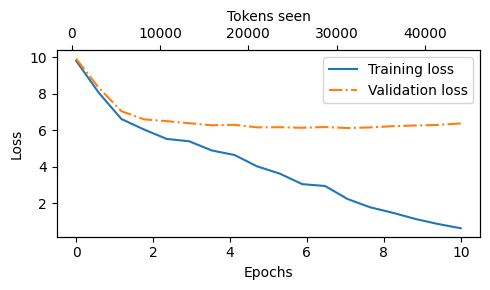

In [67]:
# Import plotting library
import matplotlib.pyplot as plt

# Import MaxNLocator to display only integer values on the x-axis
from matplotlib.ticker import MaxNLocator


# Function to plot training and validation losses
def plot_losses(
        epochs_seen,
        tokens_seen,
        train_losses,
        val_losses):

    # Create a figure and a primary axis
    #
    # figsize = (width, height)
    #
    # Returns:
    # fig  -> entire figure
    # ax1  -> first axis
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # -----------------------------------
    # Plot Training Loss
    # -----------------------------------

    # Plot training loss against epochs
    #
    # x-axis:
    # epochs_seen
    #
    # y-axis:
    # train_losses
    ax1.plot(
        epochs_seen,
        train_losses,
        label="Training loss"
    )

    # -----------------------------------
    # Plot Validation Loss
    # -----------------------------------

    # Plot validation loss against epochs
    #
    # linestyle="-."
    # gives a dash-dot line
    ax1.plot(
        epochs_seen,
        val_losses,
        linestyle="-.",
        label="Validation loss"
    )

    # Label x-axis
    ax1.set_xlabel("Epochs")

    # Label y-axis
    ax1.set_ylabel("Loss")

    # Display legend
    #
    # Shows:
    # Training loss
    # Validation loss
    ax1.legend(loc="upper right")

    # Force x-axis labels to be integers
    #
    # Example:
    # 0,1,2,3,...10
    #
    # instead of:
    # 0.0,2.5,5.0,...
    ax1.xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

    # -----------------------------------
    # Create Secondary X-Axis
    # -----------------------------------

    # Create another x-axis at the top
    #
    # Shares the same y-axis
    ax2 = ax1.twiny()

    # Create an invisible plot
    #
    # Why?
    # Allows matplotlib to align
    # token counts with the same loss values.
    #
    # alpha=0 means fully transparent.
    ax2.plot(
        tokens_seen,
        train_losses,
        alpha=0
    )

    # Label top x-axis
    ax2.set_xlabel("Tokens seen")

    # Automatically adjust spacing
    #
    # Prevents overlapping labels.
    fig.tight_layout()

    # Save figure as PDF
    #
    # File created:
    # loss-plot.pdf
    plt.savefig("loss-plot.pdf")

    # Display the graph
    plt.show()


# Create evenly spaced epoch values
#
# Example:
#
# num_epochs = 10
#
# len(train_losses)=21
#
# Output:
# [0.0, 0.5, 1.0, ..., 10.0]
epochs_tensor = torch.linspace(
    0,
    num_epochs,
    len(train_losses)
)

# Generate loss plot
plot_losses(
    epochs_tensor,
    tokens_seen,
    train_losses,
    val_losses
)

**DECODING STRATEGIES TO CONTROL RANDOMNESS**

In [68]:
# Move the trained GPT model from GPU/MPS to CPU
model.to("cpu")

# Switch the model to evaluation mode
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [69]:
# Load the GPT-2 tokenizer
#
# Why?
# GPT works with token IDs, not raw text.
#
# Example:
# "Hello world"
#      ↓
# [15496, 995]
tokenizer = tiktoken.get_encoding("gpt2")


# Generate text using the trained GPT model
token_ids = generate_text_simple(

    # GPT model used for prediction
    model=model,

    # Convert input text into token IDs
    #
    # Example:
    # "Every effort moves you"
    #         ↓
    # [16833, 3626, 6100, 345]
    idx=text_to_token_ids(
        "Every effort moves you",
        tokenizer
    ),

    # Number of new tokens to generate
    #
    # Example:
    # Prompt = 4 tokens
    #
    # After generation:
    # 4 + 25 = 29 tokens total
    max_new_tokens=25,

    # Maximum context window
    #
    # GPT only looks at the most recent
    # context_length tokens while generating.
    context_size=GPT_CONFIG_124M["context_length"]
)


# Convert generated token IDs back into text
#
# Example:
# [16833, 3626, 6100, ...]
#           ↓
# "Every effort moves you ..."
print(
    "Output text:\n",
    token_ids_to_text(
        token_ids,
        tokenizer
    )
)

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




**DECODING STRATEGY 1: TEMPERATURE SCALING**

In [70]:
# Small vocabulary used for demonstration
#
# Key   = word (token)
# Value = token ID
#
# Example:
# "every" → 1
# "moves" → 5
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}


# Create reverse mapping:
# token ID → word
#
# Example:
# 1 → "every"
# 5 → "moves"
#
# This helps convert predicted token IDs
# back into readable words.
inverse_vocab = {
    v: k
    for k, v in vocab.items()
}


# Raw output scores (logits) from a language model.
#
# Each value corresponds to one word
# in the vocabulary.
#
# Higher value = model prefers that word.
#
# Index 0 → closer
# Index 1 → every
# Index 2 → effort
# Index 3 → forward
# Index 4 → inches
# Index 5 → moves
# Index 6 → pizza
# Index 7 → toward
# Index 8 → you
next_token_logits = torch.tensor(
    [
        4.51,   # closer
        0.89,   # every
       -1.90,   # effort
        6.75,   # forward
        1.63,   # inches
       -1.62,   # moves
       -1.89,   # pizza
        6.28,   # toward
        1.79    # you
    ]
)


# Convert logits into probabilities.
#
# Softmax:
# - Makes all values positive
# - Makes probabilities sum to 1
#
# Example:
# [6.75, 6.28]
#     ↓
# [0.61, 0.39]
probas = torch.softmax(
    next_token_logits,
    dim=0
)

print(probas)


# Greedy Decoding
#
# Select token with highest probability.
#
# argmax() returns the index of
# the largest probability.
next_token_id = torch.argmax(
    probas
).item()


# Convert predicted token ID
# back into the corresponding word.
#
# Example:
# 3 → "forward"
print(next_token_id)

print(inverse_vocab[next_token_id])


tensor([0.0609, 0.0016, 0.0001, 0.5721, 0.0034, 0.0001, 0.0001, 0.3576, 0.0040])
3
forward


In [71]:
# Set random seed for reproducibility.
#
# Ensures sampling produces the same
# result every time the code runs.
torch.manual_seed(123)


# Probabilistic Sampling
#
# Instead of always choosing the most
# probable token, sample according to
# the probability distribution.
#
# Higher probability words are more
# likely to be selected, but lower
# probability words still have a chance.
next_token_id = torch.multinomial(
    probas,
    num_samples=1
).item()


# Convert sampled token ID
# back into a word and print it.
print(
    inverse_vocab[next_token_id]
)

forward


In [72]:
# Function to demonstrate token sampling frequency
# from a probability distribution.
def print_sampled_tokens(probas):

    # Set random seed for reproducibility.
    #
    # Why?
    # The same sequence of random samples
    # will be generated every time.
    torch.manual_seed(123)

    # Generate 1000 token samples.
    #
    # torch.multinomial():
    # Randomly selects an index according to
    # the probabilities in 'probas'.
    #
    # num_samples=1:
    # Select one token each time.
    #
    # .item():
    # Converts tensor value into a Python integer.
    #
    # Example:
    # tensor([3]) → 3
    sample = [
        torch.multinomial(
            probas,
            num_samples=1
        ).item()

        for i in range(1_000)
    ]

    # Count how many times each token ID appears.
    #
    # Example:
    # sample = [3,3,7,3,0]
    #
    # Output:
    # tensor([1,0,0,3,0,0,0,1])
    sampled_ids = torch.bincount(
        torch.tensor(sample)
    )

    # Print frequency of each token.
    #
    # enumerate():
    # i    = token ID
    # freq = count
    for i, freq in enumerate(sampled_ids):

        # Convert token ID back to word
        # using inverse vocabulary.
        print(
            f"{freq} x {inverse_vocab[i]}"
        )


# Call the function using the probability distribution
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [73]:
# Function to apply temperature scaling
# before computing softmax probabilities.
def softmax_with_temperature(logits, temperature):

    # Scale logits by dividing them by temperature.
    #
    # Temperature controls how "confident"
    # or "random" the probability distribution becomes.
    #
    # Small Temperature (T < 1):
    # Makes large logits even larger.
    # Produces sharper probabilities.
    #
    # Large Temperature (T > 1):
    # Reduces differences between logits.
    # Produces flatter probabilities.
    scaled_logits = logits / temperature

    # Convert scaled logits into probabilities.
    #
    # Softmax ensures:
    # - all values are positive
    # - probabilities sum to 1
    return torch.softmax(
        scaled_logits,
        dim=0
    )


# Different temperature values to test
temperatures = [

    # Original distribution
    1,

    # Very confident distribution
    # (less randomness)
    0.1,

    # More random distribution
    # (more diversity)
    5
]


# Compute probability distributions
# for each temperature value.
#
# For every T:
#   logits → scale by T → softmax
scaled_probas = [

    softmax_with_temperature(
        next_token_logits,
        T
    )

    for T in temperatures
]

In [74]:
# Function to apply temperature scaling
# before computing softmax probabilities.
def softmax_with_temperature(logits, temperature):

    # Scale logits by dividing them by temperature.
    #
    # Temperature controls how "confident"
    # or "random" the probability distribution becomes.
    #
    # Small Temperature (T < 1):
    # Makes large logits even larger.
    # Produces sharper probabilities.
    #
    # Large Temperature (T > 1):
    # Reduces differences between logits.
    # Produces flatter probabilities.
    scaled_logits = logits / temperature

    # Convert scaled logits into probabilities.
    #
    # Softmax ensures:
    # - all values are positive
    # - probabilities sum to 1
    return torch.softmax(
        scaled_logits,
        dim=0
    )


# Different temperature values to test
temperatures = [

    # Original distribution
    1,

    # Very confident distribution
    # (less randomness)
    0.1,

    # More random distribution
    # (more diversity)
    5
]


# Compute probability distributions
# for each temperature value.
#
# For every T:
#   logits → scale by T → softmax
scaled_probas = [

    softmax_with_temperature(
        next_token_logits,
        T
    )

    for T in temperatures
]

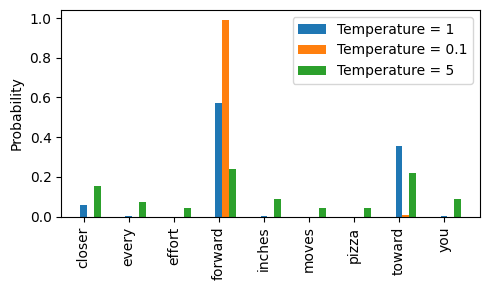

In [75]:
# -----------------------------------------
# Plot Probability Distributions for
# Different Temperature Values
# -----------------------------------------

# Create x-axis positions for each word in the vocabulary.
#
# len(vocab) = 9
#
# Output:
# tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])
#
# Each number represents the position of a word on the x-axis.
x = torch.arange(len(vocab))

# Width of each bar in the grouped bar chart.
#
# Smaller value -> thinner bars
# Larger value  -> wider bars
bar_width = 0.15

# Create a figure and axis object.
#
# figsize=(5,3)
# Width = 5 inches
# Height = 3 inches
#
# fig -> complete figure
# ax  -> plotting area
fig, ax = plt.subplots(figsize=(5, 3))

# Loop through each temperature setting
#
# enumerate() returns:
# i = index number
# T = temperature value
#
# Example:
# i=0, T=1
# i=1, T=0.1
# i=2, T=5
for i, T in enumerate(temperatures):

    # Create bars for the current temperature.
    #
    # x + i*bar_width shifts bars horizontally
    # so bars from different temperatures
    # appear side-by-side instead of overlapping.
    #
    # scaled_probas[i]
    # contains probabilities calculated using
    # the current temperature value.
    #
    # label is used in the legend.
    rects = ax.bar(
        x + i * bar_width,      # x positions
        scaled_probas[i],       # bar heights (probabilities)
        bar_width,              # width of each bar
        label=f'Temperature = {T}'
    )

# Label the y-axis.
#
# The y-axis shows token probabilities.
ax.set_ylabel('Probability')

# Set tick positions on x-axis.
#
# Example:
# [0,1,2,3,4,5,6,7,8]
ax.set_xticks(x)

# Replace numerical positions with vocabulary words.
#
# Example:
#
# 0 -> closer
# 1 -> every
# 2 -> effort
# ...
#
# rotation=90 rotates labels vertically
# so long labels fit neatly.
ax.set_xticklabels(
    vocab.keys(),
    rotation=90
)

# Display legend showing which color
# corresponds to which temperature.
ax.legend()

# Automatically adjust spacing.
#
# Prevents:
# - label overlap
# - axis clipping
# - cut-off text
plt.tight_layout()

# Save chart as a PDF file.
#
# File created:
# temperature-plot.pdf
plt.savefig("temperature-plot.pdf")

# Display chart on screen.
plt.show()

### **DECODING STRATEGY 2: Top-k sampling**

In [76]:
# Define the value of k, i.e., the number of highest-probability tokens
# that will be considered during sampling.
# Here, only the top 3 most likely tokens are kept, while all others
# will be ignored in the next step.
top_k = 3

# torch.topk() finds the k largest values in the tensor.
# next_token_logits contains the model's raw prediction scores (logits)
# for all possible next tokens in the vocabulary.
#
# It returns:
# 1. top_logits -> the highest 3 logit values
# 2. top_pos    -> the indices (token IDs) corresponding to those logits
#
# This is the core step of Top-k Sampling because it restricts token
# selection to only the k most probable candidates.
top_logits, top_pos = torch.topk(next_token_logits, top_k)

# Display the top 3 logit values selected from the vocabulary.
# These scores indicate how strongly the model prefers each candidate token.
print("Top logits:", top_logits)

# Display the positions (token IDs) of the top 3 tokens.
# These IDs can later be mapped back to actual words/tokens using the tokenizer.
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [77]:
# Create a new logits tensor where only the top-k tokens are retained.
# Tokens that are NOT among the top-k candidates are replaced with -infinity.
#
# torch.where(condition, input, other) works as:
# - If condition is True  -> use 'input'
# - If condition is False -> use 'other'

new_logits = torch.where(

    # Check which logits are smaller than the lowest logit
    # among the selected top-k tokens.
    #
    # top_logits[-1] represents the kth largest logit
    # (the minimum value within the top-k set).
    #
    # Any token with a logit below this threshold is excluded.
    condition=next_token_logits < top_logits[-1],

    # Replace excluded tokens with negative infinity.
    #
    # After applying softmax, exp(-inf) = 0,
    # meaning these tokens receive zero probability
    # and can never be sampled.
    input=torch.tensor(float("-inf")),

    # Keep the original logit values for the top-k tokens.
    other=next_token_logits
)

# Display the modified logits.
# Top-k tokens retain their original scores,
# while all other tokens appear as -inf.
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [78]:
# Convert the filtered logits into probabilities using the Softmax function.
#
# new_logits contains:
# - Original logit values for the top-k tokens
# - -infinity for all other tokens
#
# Softmax transforms these logits into a probability distribution
# whose values sum to 1.

topk_probas = torch.softmax(new_logits, dim=0)

# Display the probabilities after applying Top-k filtering.
#
# The top-k tokens will have non-zero probabilities.
# Tokens with -infinity logits become:
# exp(-inf) = 0
# Therefore, their probability becomes 0 and they cannot be selected.
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### **Merge Temperature Scaling and Top-k sampling**



Step 1: For-loop is the same as before: Get logits, and only focus on last time step

Step 2: In this new section, we filter logits with top_k sampling

Step 3: This is the new section where we apply temperature scaling
    
Step 4: Carry out greedy next-token selection as before when temperature scaling is disabled

Step 5: Stop generating early if end-of-sequence token is encountered and eos_id is specified



In [79]:
# Function for generating text token by token using a trained language model.
#
# Features:
# - Supports Top-k Sampling (limits choices to the k most probable tokens)
# - Supports Temperature Scaling (controls randomness)
# - Supports Greedy Decoding (when temperature = 0)
# - Supports Early Stopping using an End-of-Sequence (EOS) token
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # Generate tokens one at a time until the desired number
    # of new tokens has been produced.
    for _ in range(max_new_tokens):

        # Extract only the most recent context_size tokens.
        #
        # GPT models have a fixed context window, so if the
        # sequence becomes longer than context_size, only the
        # latest tokens are used as input.
        idx_cond = idx[:, -context_size:]

        # Disable gradient computation because we are performing
        # inference (text generation), not training.
        with torch.no_grad():

            # Pass the input sequence through the model to obtain
            # prediction scores (logits) for every token position.
            logits = model(idx_cond)

        # Keep only the logits corresponding to the last token position.
        #
        # Shape before:
        # (batch_size, sequence_length, vocab_size)
        #
        # Shape after:
        # (batch_size, vocab_size)
        #
        # We only need the prediction for the next token.
        logits = logits[:, -1, :]

        # ---------------------------------------------------
        # TOP-K SAMPLING
        # ---------------------------------------------------
        # If top_k is specified, restrict token selection
        # to only the k most probable candidates.
        if top_k is not None:

            # Retrieve the top_k highest logits.
            #
            # top_logits contains the k largest values.
            # We ignore the token indices here using '_'.
            top_logits, _ = torch.topk(logits, top_k)

            # Find the smallest logit among the selected top-k tokens.
            #
            # This value serves as the threshold.
            min_val = top_logits[:, -1]

            # Replace all logits below the threshold with -infinity.
            #
            # After softmax:
            # exp(-inf) = 0
            #
            # Therefore, these tokens receive zero probability
            # and cannot be sampled.
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )

        # ---------------------------------------------------
        # TEMPERATURE SCALING
        # ---------------------------------------------------
        # Apply temperature-based sampling if temperature > 0.
        if temperature > 0.0:

            # Scale logits by temperature.
            #
            # Lower temperature (<1):
            #   Sharper distribution, more deterministic output.
            #
            # Higher temperature (>1):
            #   Flatter distribution, more random output.
            logits = logits / temperature

            # Convert logits into probabilities using Softmax.
            #
            # Shape:
            # (batch_size, vocab_size)
            #
            # Probabilities sum to 1.
            probs = torch.softmax(logits, dim=-1)

            # Randomly sample one token according to the probability
            # distribution obtained from Softmax.
            #
            # Unlike argmax, this introduces controlled randomness.
            idx_next = torch.multinomial(
                probs,
                num_samples=1
            )  # Shape: (batch_size, 1)

        # ---------------------------------------------------
        # GREEDY DECODING
        # ---------------------------------------------------
        # If temperature = 0, use deterministic decoding.
        else:

            # Select the token with the highest logit.
            #
            # This is Greedy Decoding:
            # always choose the most probable next token.
            idx_next = torch.argmax(
                logits,
                dim=-1,
                keepdim=True
            )  # Shape: (batch_size, 1)

        # ---------------------------------------------------
        # EARLY STOPPING
        # ---------------------------------------------------
        # Stop generation if the End-of-Sequence token
        # has been generated.
        if idx_next == eos_id:

            # Exit the generation loop immediately.
            break

        # Append the newly generated token to the sequence.
        #
        # Previous shape:
        # (batch_size, current_length)
        #
        # New shape:
        # (batch_size, current_length + 1)
        idx = torch.cat(
            (idx, idx_next),
            dim=1
        )

    # Return the complete generated token sequence.
    return idx

In [80]:
# Set a random seed for reproducibility.
#
# Sampling methods such as Top-k Sampling and Temperature Sampling
# involve randomness. Setting the seed ensures that the same tokens
# are sampled every time the code is executed, making results repeatable.
torch.manual_seed(123)

# Generate text using the trained GPT model.
token_ids = generate(

    # The language model used to predict the next token.
    model=model,

    # Convert the input prompt ("Every effort moves you")
    # into token IDs that the model can process.
    idx=text_to_token_ids(
        "Every effort moves you",
        tokenizer
    ),

    # Generate up to 15 new tokens beyond the prompt.
    max_new_tokens=15,

    # Maximum number of previous tokens the model can use
    # as context while predicting the next token.
    #
    # For GPT-2 124M, this is typically 1024 tokens.
    context_size=GPT_CONFIG_124M["context_length"],

    # Top-k Sampling:
    #
    # At each generation step, only the 25 most probable
    # candidate tokens are considered.
    #
    # This prevents the model from selecting extremely
    # unlikely tokens while still allowing diversity.
    top_k=25,

    # Temperature Scaling:
    #
    # Temperature > 1 increases randomness.
    #
    # temperature = 1.4 makes the probability distribution
    # flatter, encouraging more diverse and creative outputs.
    #
    # Lower values (<1) would make the output more focused
    # and deterministic.
    temperature=1.4
)

# Convert the generated token IDs back into readable text.
#
# The tokenizer maps token IDs to words/subwords so the
# generated sequence can be understood by humans.
print(
    "Output text:\n",
    token_ids_to_text(token_ids, tokenizer)
)

Output text:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head


## **LOADING AND SAVING MODEL WEIGHTS IN PYTORCH**

In [81]:
# Create an instance of the GPT model using the configuration
# stored in GPT_CONFIG_124M.
#
# The configuration typically contains parameters such as:
# - Vocabulary size
# - Context length
# - Embedding dimension
# - Number of attention heads
# - Number of transformer layers
#
# At this point, the model architecture is created and its
# parameters (weights and biases) are initialized.
model = GPTModel(GPT_CONFIG_124M)

# Save the model's learned parameters to a file named "model.pth".
#
# model.state_dict() returns a Python dictionary containing:
# - Layer weights
# - Layer biases
# - Embedding matrices
# - All trainable parameters of the model
#
# torch.save() serializes this dictionary and stores it on disk.
#
# Why save state_dict instead of the entire model?
# - Smaller file size
# - More portable
# - Recommended PyTorch practice
# - Allows the model architecture code to be updated separately
#
# The file "model.pth" can later be loaded to restore the model's
# trained weights without retraining.
torch.save(model.state_dict(), "model.pth")

In [82]:
# Create a new instance of the GPT model using the same
# configuration that was used when the model weights were saved.
#
# The model architecture must be recreated before the saved
# weights can be loaded into it.
#
# Important:
# The architecture (number of layers, embedding size,
# attention heads, etc.) must exactly match the model
# that originally produced "model.pth".
model = GPTModel(GPT_CONFIG_124M)

# Load the saved model parameters from the file "model.pth"
# and copy them into the model.
#
# torch.load("model.pth")
#     Reads the saved state dictionary from disk.
#
# model.load_state_dict(...)
#     Assigns the saved weights and biases to the
#     corresponding layers in the model.
#
# After this step, the model contains the same learned
# parameters that were present when it was saved.
model.load_state_dict(torch.load("model.pth"))

# Switch the model to evaluation (inference) mode.
#
# Some layers behave differently during training and inference:
#
# 1. Dropout
#    - Training: randomly drops neurons.
#    - Evaluation: uses all neurons.
#
# 2. Batch Normalization (if present)
#    - Training: updates batch statistics.
#    - Evaluation: uses stored statistics.
#
# GPT models typically contain Dropout layers, so calling
# eval() ensures consistent and deterministic behavior
# during text generation.
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [83]:
# Create an AdamW optimizer for training the GPT model.
#
# AdamW is a popular optimization algorithm used for training transformer-based models such as GPT.
#
# model.parameters()
#     Returns all trainable parameters (weights and biases)
#     of the model that need to be updated during training.
#
# lr=0.0004
#     Learning rate that controls the size of each parameter update.
#
# weight_decay=0.1
#     L2 regularization term that helps prevent overfitting by
#     discouraging excessively large weights.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1
)

# Save both the model state and optimizer state into a checkpoint file.
#
# If training is interrupted and later resumed, the optimizer
# needs its internal information (momentum, adaptive learning rates,
# step counts, etc.) to continue training correctly.
#
# Saving only model weights allows inference.
# Saving model + optimizer allows training to resume seamlessly.
torch.save(

    {
        # Save all learned model parameters.
        #
        # Contains:
        # - Embedding weights
        # - Attention weights
        # - Feed-forward network weights
        # - Biases
        "model_state_dict": model.state_dict(),

        # Save the optimizer's internal state.
        #
        # Contains:
        # - Momentum estimates
        # - Running averages
        # - Learning rate information
        # - Training step counters
        "optimizer_state_dict": optimizer.state_dict(),
    },

    # Name of the checkpoint file where everything is stored.
    "model_and_optimizer.pth"
)

In [84]:
# Load the checkpoint file from disk.
#
# torch.load() reads the saved file and returns the dictionary
# that was stored using torch.save().
#
# The returned dictionary contains:
# - model_state_dict
# - optimizer_state_dict
checkpoint = torch.load("model_and_optimizer.pth")

# Create a new GPT model instance using the same configuration
# that was used when the checkpoint was created.
#
# This recreates the model architecture with randomly
# initialized parameters.
model = GPTModel(GPT_CONFIG_124M)

# Load the saved model weights into the newly created model.
#
# checkpoint["model_state_dict"] contains all learned parameters such as:
# - Embedding weights
# - Attention weights
# - Feed-forward network weights
# - Biases
#
# After this step, the model has the same learned knowledge
# it had when the checkpoint was saved.
model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Create a new AdamW optimizer.
#
# The optimizer must be created before its saved state can be restored.
#
# model.parameters()
# returns all trainable parameters that the optimizer
# will update during training.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=0.1
)

# Restore the optimizer's internal state from the checkpoint.
#
# This loads:
# - Momentum values
# - Running averages
# - Adaptive learning-rate statistics
# - Step counters
#
# As a result, training can continue exactly from where it was previously stopped.
optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

# Switch the model to training mode.
#
# This enables training-specific behavior such as:
#
# 1. Dropout
#    - Randomly disables neurons during training
#    - Helps prevent overfitting
#
# 2. Batch Normalization (if present)
#    - Updates running statistics
#
# Since we want to continue training rather than perform
# inference, train() is used instead of eval().
model.train();

## **LOADING PRETRAINED WEIGHTS FROM OPENAI**

In [85]:
import importlib
import gpt_download3

importlib.reload(gpt_download3)

print(hasattr(gpt_download3, "download_and_load_gpt2"))

True


In [86]:
# Import the function that downloads GPT-2 files and loads the pretrained weights.
# We use this function so that we don't have to manually download model checkpoints,
# configuration files, and tokenizer data from OpenAI's GPT-2 release.
from gpt_download3 import download_and_load_gpt2

In [87]:
# Download the pretrained GPT-2 124M model files (if not already present)
# and load both the model configuration settings and learned parameters.
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 149kiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 724kiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verificati

In [88]:
# Display the GPT-2 configuration settings loaded from the model files.
# This helps verify the architecture details such as vocabulary size,
# context length, embedding dimension, number of heads, and layers.
print("Settings:", settings)

# Display the top-level keys in the parameter dictionary.
# This helps inspect how the pretrained weights are organized and
# identify the different model components whose weights were loaded.
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [89]:
# Store architecture settings for different GPT-2 model sizes in a dictionary.
# This makes it easy to switch between GPT-2 variants without rewriting configuration values.
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Select the GPT-2 model variant whose pretrained weights will be loaded.
# The chosen model name is used as a key to retrieve its architecture settings.
model_name = "gpt2-small (124M)"  # Example model name

# Create a copy of the base GPT configuration to avoid modifying the original dictionary.
# This serves as the starting configuration for the selected GPT-2 model.
NEW_CONFIG = GPT_CONFIG_124M.copy()

# Update the copied configuration with the embedding size, number of layers,
# and number of attention heads corresponding to the selected GPT-2 model.
# This ensures the custom model architecture matches the pretrained weights.
NEW_CONFIG.update(model_configs[model_name])

In [90]:
# Update the configuration with GPT-2 specific settings required by the pretrained weights.
# The context length must match GPT-2's maximum sequence length, and qkv_bias must be enabled
# because GPT-2 uses bias terms in its Query, Key, and Value projections.
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

# Create a GPT model using the finalized configuration.
# This initializes the model architecture (layers, embeddings, attention blocks, etc.)
# that will later receive the pretrained GPT-2 weights.
gpt = GPTModel(NEW_CONFIG)

# Switch the model to evaluation mode.
# This disables training-specific behaviors such as dropout and ensures
# consistent outputs during inference and weight loading verification.
gpt.eval();

In [91]:
# Define a helper function to copy pretrained weights into a PyTorch model parameter.
# It verifies that both tensors have the same shape before assignment.
def assign(left, right):

    # Check whether the shape of the model parameter and the pretrained weight match.
    # Matching shapes are required because each value in the pretrained tensor must
    # correspond to a specific position in the model parameter tensor.
    if left.shape != right.shape:

        # Stop execution and display an error if the shapes differ.
        # This helps detect architecture mismatches before loading weights.
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")

    # Convert the pretrained weight array into a PyTorch tensor and wrap it as a trainable Parameter so it can replace the existing model parameter.
    return torch.nn.Parameter(torch.tensor(right))

In [92]:
import numpy as np


# Define a function that copies all pretrained GPT-2 weights into the custom GPT model.
# 'gpt' is the PyTorch model and 'params' contains OpenAI's pretrained weights.
def load_weights_into_gpt(gpt, params):

    # Load pretrained positional embeddings (position → vector mapping).
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])

    # Load pretrained token embeddings (token ID → vector mapping).
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    # Iterate through all transformer blocks and load their weights one by one.
    for b in range(len(params["blocks"])):

        # GPT-2 stores Query, Key, and Value weights in a single matrix.
        # Split that matrix into three separate matrices along the last dimension.
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)

        # Load Query projection weights.
        # Transpose because OpenAI and PyTorch store linear layer weights differently.
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)

        # Load Key projection weights.
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)

        # Load Value projection weights.
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        # GPT-2 stores Query, Key, and Value biases together.
        # Split them into separate bias vectors.
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)

        # Load Query bias.
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)

        # Load Key bias.
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)

        # Load Value bias.
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        # Load output projection weights of the multi-head attention layer.
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)

        # Load output projection bias of the attention layer.
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        # Load weights of the first feed-forward layer (expands dimensions).
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)

        # Load bias of the first feed-forward layer.
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])

        # Load weights of the second feed-forward layer (projects back).
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)

        # Load bias of the second feed-forward layer.
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        # Load scale parameter (gamma) of the first LayerNorm.
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])

        # Load shift parameter (beta) of the first LayerNorm.
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])

        # Load scale parameter (gamma) of the second LayerNorm.
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])

        # Load shift parameter (beta) of the second LayerNorm.
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    # Load scale parameter of the final LayerNorm applied before output generation.
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])

    # Load shift parameter of the final LayerNorm.
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])

    # Load output layer weights.
    # GPT-2 uses weight tying, so the output projection shares the same weights as the token embedding matrix.
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [93]:
# Copy all pretrained GPT-2 weights from the parameter dictionary into the custom GPT model.
# This replaces the randomly initialized weights with the learned weights from OpenAI's GPT-2.
load_weights_into_gpt(gpt, params)

# Move the model to the specified device (CPU or GPU).
# This ensures that all model parameters are stored on the same device used for inference.
gpt.to(device);

In [94]:
# Set a fixed random seed so that token sampling produces reproducible results.
# Using the same seed ensures that the same sequence of random choices is made each run.
torch.manual_seed(123)

# Generate new text tokens using the pretrained GPT-2 model.
# The generation starts from the prompt "Every effort moves you" and continues
# by predicting one token at a time until 25 new tokens have been produced.
token_ids = generate(
    model=gpt,

    # Convert the input text prompt into token IDs and move them to the same
    # device (CPU/GPU) as the model before generation begins.
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),

    # Maximum number of new tokens the model should generate.
    # These tokens are appended to the original prompt.
    max_new_tokens=25,

    # Maximum context window the model can attend to while generating text.
    # GPT-2 Small supports up to 1024 tokens.
    context_size=NEW_CONFIG["context_length"],

    # Apply Top-k sampling by keeping only the 50 most probable next-token candidates.
    # This removes very unlikely tokens and improves output quality.
    top_k=50,

    # Apply temperature scaling to control randomness.
    # A value greater than 1 makes the probability distribution flatter,
    # producing more diverse and creative outputs.
    temperature=1.5
)

# Convert the generated token IDs back into readable text and display it.
# This allows us to see the final text generated by the model.
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


# **FINETUNING FOR CLASSIFICATION**

**Step 1: Download Dataset**

In [95]:
# Import urllib.request to download files from a URL
import urllib.request

# Import SSL module to handle secure HTTPS connections
import ssl

# Import zipfile module to extract ZIP archives
import zipfile

# Import os module for operating system related file operations
import os

# Import Path for convenient and platform-independent file path handling
from pathlib import Path

# URL of the SMS Spam Collection dataset hosted by UCI
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

# Local filename where the downloaded ZIP file will be stored
zip_path = "sms_spam_collection.zip"

# Directory where the ZIP contents will be extracted
extracted_path = "sms_spam_collection"

# Path to the final dataset file after extraction and renaming
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

# Function to download, extract, and prepare the spam dataset
def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):

    # Skip download if the dataset file already exists
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Create an SSL context that bypasses certificate verification
    ssl_context = ssl._create_unverified_context()

    # Open the dataset URL and download the ZIP file
    with urllib.request.urlopen(url, context=ssl_context) as response:

        # Create a local ZIP file in binary write mode
        with open(zip_path, "wb") as out_file:

            # Write the downloaded content into the ZIP file
            out_file.write(response.read())

    # Open the downloaded ZIP archive in read mode
    with zipfile.ZipFile(zip_path, "r") as zip_ref:

        # Extract all files into the specified directory
        zip_ref.extractall(extracted_path)

    # Path of the extracted dataset file without extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"

    # Rename the extracted file to have a .tsv extension
    os.rename(original_file_path, data_file_path)

    # Display confirmation message after successful preparation
    print(f"File downloaded and saved as {data_file_path}")

# Execute the function to download and prepare the dataset
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv
File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv
File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [96]:
# Import the pandas library for data loading and manipulation
import pandas as pd

# Read the TSV (Tab-Separated Values) dataset into a DataFrame
df = pd.read_csv(
    data_file_path,      # Path to the SMS Spam Collection dataset
    sep="\t",            # Columns are separated by tab characters
    header=None,         # Original file does not contain column names
    names=["Label", "Text"]  # Assign custom column names
)

# Display the DataFrame
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [97]:
# Count the number of occurrences of each unique label (ham and spam)
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [98]:
# Function to create a balanced dataset with equal numbers of ham and spam messages
def create_balanced_dataset(df):

    # Count the total number of spam messages
    num_spam = df[df["Label"] == "spam"].shape[0]

    # Randomly select the same number of ham messages as spam messages
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam,          # Number of samples to select
        random_state=123   # Fixed seed for reproducible results
    )

    # Combine the sampled ham messages with all spam messages
    balanced_df = pd.concat([
        ham_subset,
        df[df["Label"] == "spam"]
    ])

    # Return the balanced DataFrame
    return balanced_df

# Create a balanced version of the original dataset
balanced_df = create_balanced_dataset(df)

# Verify that both classes now contain the same number of samples
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [99]:
# Convert text labels into numerical labels
# "ham" messages are mapped to 0
# "spam" messages are mapped to 1
balanced_df["Label"] = balanced_df["Label"].map({
    "ham": 0,
    "spam": 1
})

In [100]:
# Function to randomly shuffle and split the dataset into
# training, validation, and test sets
def random_split(df, train_frac, validation_frac):

    # Randomly shuffle all rows in the DataFrame
    # frac=1 means use 100% of the data but in a random order
    # random_state ensures the same shuffle every time
    # reset_index(drop=True) creates new sequential indices
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate the ending index of the training set
    train_end = int(len(df) * train_frac)

    # Calculate the ending index of the validation set
    validation_end = train_end + int(len(df) * validation_frac)

    # Select rows from the beginning up to train_end
    train_df = df[:train_end]

    # Select rows between train_end and validation_end
    validation_df = df[train_end:validation_end]

    # Select all remaining rows for testing
    test_df = df[validation_end:]

    # Return the three datasets
    return train_df, validation_df, test_df

# Split the balanced dataset into:
# 70% training, 10% validation, and 20% testing
train_df, validation_df, test_df = random_split(
    balanced_df,
    0.7,  # Training fraction
    0.1   # Validation fraction
)

# The remaining 20% automatically becomes the test set

In [101]:
# Display the number of samples in the training dataset
print(len(train_df))

# Display the number of samples in the validation dataset
print(len(validation_df))

# Display the number of samples in the test dataset
print(len(test_df))

1045
149
300


In [102]:
# Save the training dataset to a CSV file
# index=None prevents pandas from writing row indices into the file
train_df.to_csv("train.csv", index=None)

# Save the validation dataset to a CSV file
# This file will be used to evaluate the model during training
validation_df.to_csv("validation.csv", index=None)

# Save the test dataset to a CSV file
# This file will be used for final model evaluation
test_df.to_csv("test.csv", index=None)

**Step 2: Creating Dataloader**

In [103]:
# Import PyTorch library for tensor operations
import torch

# Import Dataset base class used to create custom datasets
from torch.utils.data import Dataset


# Define a custom dataset class for spam classification
# Inherits functionality from PyTorch's Dataset class
class SpamDataset(Dataset):

    # Constructor called when the dataset object is created
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):

        # Load the CSV file into a pandas DataFrame
        self.data = pd.read_csv(csv_file)

        # Convert every text message into token IDs before training
        # This is called pre-tokenization
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        # If no maximum sequence length is provided
        if max_length is None:

            # Find the length of the longest tokenized message
            self.max_length = self._longest_encoded_length()

        else:

            # Use the user-specified maximum length
            self.max_length = max_length

            # Cut off sequences longer than max_length
            # This prevents extremely long inputs
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad shorter sequences so every sequence has the same length
        # Required because tensors in a batch must have identical dimensions
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    # Called when accessing a single dataset sample
    def __getitem__(self, index):

        # Retrieve tokenized text at the given index
        encoded = self.encoded_texts[index]

        # Retrieve corresponding label (0 = ham, 1 = spam)
        label = self.data.iloc[index]["Label"]

        # Return input tokens and label as PyTorch tensors
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    # Returns the total number of samples in the dataset
    def __len__(self):
        return len(self.data)

    # Helper function to find the longest tokenized sequence
    def _longest_encoded_length(self):

        # Initialize maximum length
        max_length = 0

        # Iterate through all tokenized texts
        for encoded_text in self.encoded_texts:

            # Compute length of current sequence
            encoded_length = len(encoded_text)

            # Update maximum length if current sequence is longer
            if encoded_length > max_length:
                max_length = encoded_length

        # Return the length of the longest sequence
        return max_length

In [104]:
# Create a SpamDataset object using the training data
train_dataset = SpamDataset(

    # CSV file containing training samples
    csv_file="train.csv",

    # Automatically determine the maximum sequence length
    # by finding the longest tokenized text in the dataset
    max_length=None,

    # Tokenizer used to convert text into token IDs
    tokenizer=tokenizer
)

# Display the maximum sequence length found in the training dataset
print(train_dataset.max_length)

120


In [105]:
# Create a dataset object for the validation data
val_dataset = SpamDataset(

    # CSV file containing validation samples
    csv_file="validation.csv",

    # Use the same maximum sequence length as the training dataset
    # This ensures consistent input dimensions across datasets
    max_length=train_dataset.max_length,

    # Tokenizer used to convert text into token IDs
    tokenizer=tokenizer
)

# Create a dataset object for the test data
test_dataset = SpamDataset(

    # CSV file containing test samples
    csv_file="test.csv",

    # Use the same maximum sequence length as the training dataset
    # Any longer sequence will be truncated and shorter ones padded
    max_length=train_dataset.max_length,

    # Tokenizer used to convert text into token IDs
    tokenizer=tokenizer
)

In [106]:
# Import DataLoader for creating mini-batches from a dataset
from torch.utils.data import DataLoader

# Number of worker processes used for loading data
# 0 means data loading happens in the main process
num_workers = 0

# Number of samples processed together in one batch
batch_size = 8

# Set a random seed for reproducibility
# Ensures the same shuffling order across runs
torch.manual_seed(123)

# Create DataLoader for the training dataset
train_loader = DataLoader(

    # Dataset object containing tokenized training samples
    dataset=train_dataset,

    # Number of samples per batch
    batch_size=batch_size,

    # Randomly shuffle data at the beginning of every epoch
    shuffle=True,

    # Number of worker processes for loading data
    num_workers=num_workers,

    # Drop the last incomplete batch if its size is less than batch_size
    drop_last=True,
)

# Create DataLoader for the validation dataset
val_loader = DataLoader(

    # Dataset object containing validation samples
    dataset=val_dataset,

    # Number of samples per batch
    batch_size=batch_size,

    # Number of worker processes for loading data
    num_workers=num_workers,

    # Keep the final smaller batch if dataset size is not divisible by batch_size
    drop_last=False,
)

# Create DataLoader for the test dataset
test_loader = DataLoader(

    # Dataset object containing test samples
    dataset=test_dataset,

    # Number of samples per batch
    batch_size=batch_size,

    # Number of worker processes for loading data
    num_workers=num_workers,

    # Keep the final incomplete batch for evaluation
    drop_last=False,
)

In [107]:
# Display a heading indicating that we are inspecting the training DataLoader
print("Train loader:")

# Iterate through all batches in the training DataLoader
for input_batch, target_batch in train_loader:

    # Do nothing for each batch
    # The loop continues until the last batch is reached
    pass

# After the loop finishes, input_batch contains the last batch of inputs
# Display the shape of the input tensor
print("Input batch dimensions:", input_batch.shape)

# Display the shape of the corresponding label tensor
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [108]:
# Display the total number of batches in the training DataLoader
print(f"{len(train_loader)} training batches")

# Display the total number of batches in the validation DataLoader
print(f"{len(val_loader)} validation batches")

# Display the total number of batches in the test DataLoader
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


**Step 3: INITIALIZING A MODEL WITH PRETRAINED WEIGHTS**

In [109]:
# Selects which GPT-2 variant will be used.
# WHY: Different GPT-2 models have different sizes (number of parameters).
# Here we choose the smallest version (124M parameters) for faster loading and lower memory usage.
CHOOSE_MODEL = "gpt2-small (124M)"


# Defines the starting text (prompt) that will be given to the model for text generation.
# WHY: The model needs some initial context before it can predict the next tokens.
INPUT_PROMPT = "Every effort moves"


# Creates a dictionary containing configuration settings that are common
# to all GPT-2 model variants.
# WHY: Instead of repeating these settings for every model, we define them once.
BASE_CONFIG = {

    # Total number of unique tokens that GPT-2 can recognize.
    # WHY: The tokenizer converts text into token IDs ranging from 0 to 50256.
    "vocab_size": 50257,

    # Maximum number of tokens the model can process at one time.
    # WHY: GPT-2 was trained with a context window of 1024 tokens.
    # Any sequence longer than this cannot be processed directly.
    "context_length": 1024,

    # Dropout probability.
    # WHY: Dropout is typically used during training to prevent overfitting.
    # Since we are loading pretrained weights for inference, it is set to 0.0.
    "drop_rate": 0.0,

    # Indicates whether bias terms are included in Query, Key, and Value projections.
    # WHY: OpenAI's GPT-2 architecture uses biases in these linear layers.
    # We must match the original architecture before loading pretrained weights.
    "qkv_bias": True
}


# Stores the architecture-specific settings for each GPT-2 model size.
# WHY: Larger models have larger embeddings, more transformer blocks,
# and more attention heads.
model_configs = {

    # GPT-2 Small: 124 million parameters
    "gpt2-small (124M)": {
        "emb_dim": 768,      # Embedding dimension
        "n_layers": 12,      # Number of transformer blocks
        "n_heads": 12        # Number of attention heads
    },

    # GPT-2 Medium: 355 million parameters
    "gpt2-medium (355M)": {
        "emb_dim": 1024,
        "n_layers": 24,
        "n_heads": 16
    },

    # GPT-2 Large: 774 million parameters
    "gpt2-large (774M)": {
        "emb_dim": 1280,
        "n_layers": 36,
        "n_heads": 20
    },

    # GPT-2 XL: 1.5 billion parameters
    "gpt2-xl (1558M)": {
        "emb_dim": 1600,
        "n_layers": 48,
        "n_heads": 25
    },
}


# Adds the configuration of the selected model into BASE_CONFIG.
# For GPT-2 Small, emb_dim=768, n_layers=12, and n_heads=12
# are inserted into BASE_CONFIG.
#
# WHY: This creates one complete configuration dictionary that can be
# passed directly when constructing the GPT model.
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])


# Verifies that the dataset sequence length does not exceed the model's
# maximum context length.
#
# WHY: The model can only process sequences up to its context window
# (1024 tokens for GPT-2). Longer sequences would cause errors.
assert train_dataset.max_length <= BASE_CONFIG["context_length"], (

    # Error message shown if the assertion fails.
    # WHY: Helps the user understand exactly why the dataset is incompatible.
    f"Dataset length {train_dataset.max_length} exceeds model's context "

    # Displays the model's maximum supported context length.
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "

    # Suggests how to fix the issue by recreating the dataset
    # using the model's supported maximum length.
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [110]:
# Extracts only the model size from the selected model string.
# Example:
# "gpt2-small (124M)" → "124M"
#
# PROCESS:
# split(" ") breaks the string into:
# ["gpt2-small", "(124M)"]
# [-1] selects "(124M)"
# lstrip("(") removes the opening parenthesis
# rstrip(")") removes the closing parenthesis
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")


# Imports a helper function that downloads GPT-2 files and loads pretrained parameters into Python.
#
# Instead of manually downloading checkpoint files, tokenizer files and configuration files from OpenAI, this utility automates the process.
from gpt_download3 import download_and_load_gpt2


# Downloads (if necessary) and loads the pretrained GPT-2 model.
#
# model_size=model_size
# → specifies which GPT-2 variant to load (124M here).
#
# models_dir="gpt2"
# → directory where downloaded files will be stored.
#
# Returns:
# settings → model configuration information
# params   → pretrained weights (all learned parameters)
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)


# Creates an empty GPT model architecture using BASE_CONFIG.
#
# Constructs all layers:
# - Token embedding layer
# - Position embedding layer
# - Transformer blocks
# - Final normalization layer
# - Output projection layer
#
# At this stage the model structure exists, but the weights are randomly initialized and do not contain GPT-2 knowledge yet.
model = GPTModel(BASE_CONFIG)


# Copies pretrained GPT-2 weights into the model.
#
# Matches each parameter in 'params' with the corresponding layer in our GPT implementation and replaces random weights with pretrained values.
#
# Without this step, the model would behave like a randomly initialized network and generate meaningless text.
load_weights_into_gpt(model, params)


# Switches the model to evaluation (inference) mode.
#
# Disables training-specific behavior such as dropout.
#
# During text generation we want deterministic predictions and do not want neurons randomly dropped.
#
# This is standard practice whenever using a pretrained model for inference rather than training.
model.eval();

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2/124M/checkpoint


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2/124M/encoder.json


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

File already exists and is up-to-date: gpt2/124M/model.ckpt.index


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2/124M/model.ckpt.meta


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [111]:
# Input prompt that will be given to the pretrained GPT-2 model.
#
# GPT models generate text by predicting the next token based on previously seen tokens. This prompt serves as the starting context.
text_1 = "Every effort moves you"


# Generates new tokens using the pretrained GPT-2 model.
#
# The model receives the tokenized version of the input text and predicts one token at a time until 15 new tokens have been generated.
token_ids = generate_text_simple(

    # The pretrained GPT-2 model loaded with OpenAI weights.
    #
    # WHY:
    # This model contains learned language patterns and knowledge
    # from pretraining.
    model=model,

    # Converts the input text into token IDs.
    #
    # Example:
    # "Every effort moves you"
    #      ↓
    # [6109, 3626, 6100, 345]
    #
    # WHY:
    # Neural networks cannot process raw text directly.
    # GPT works only with numerical token IDs.
    idx=text_to_token_ids(text_1, tokenizer),

    # Number of additional tokens to generate.
    #
    # WHY:
    # The model will repeatedly predict the next token
    # 15 times beyond the original prompt.
    max_new_tokens=15,

    # Maximum context window supported by GPT-2.
    #
    # WHY:
    # During generation, the model can only attend to
    # tokens within its context length.
    context_size=BASE_CONFIG["context_length"]
)


# Converts generated token IDs back into human-readable text.
#
# WHAT:
# token_ids_to_text() performs the reverse of tokenization.
#
# Example:
# [6109, 3626, 6100, 345, ...]
#          ↓
# "Every effort moves you ..."
#
# WHY:
# Generated output is produced as token IDs, but users need text.
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [112]:
# Creates a text prompt asking the model to classify a message as spam or not.
#
# The prompt contains:
# 1. An instruction:
#    "Answer with 'yes' or 'no'"
# 2. A message to evaluate.
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"

    # Beginning of the message being evaluated.
    #
    # WHY:
    # This message contains common spam indicators such as:
    # - "winner"
    # - "specially selected"
    # - cash rewards
    # - prize offers
    " 'You are a winner you have been specially"

    # Continuation of the message.
    #
    # Spam messages often use attractive rewards to persuade users to take action.
    " selected to receive $1000 cash or a $2000 award.'"
)


# Generates a continuation of the prompt using the pretrained GPT-2 model.
#
# WHAT:
# The model reads the entire prompt and predicts the next tokens.
#
# WHY:
# We want the model to continue the text with an answer such as
# "yes" or "no" (although GPT-2 is not specifically trained as
# a classifier).
token_ids = generate_text_simple(

    # Pretrained GPT-2 model containing learned language knowledge.
    model=model,

    # Converts the prompt text into token IDs.
    #
    # WHY:
    # GPT can only process numerical token representations.
    idx=text_to_token_ids(text_2, tokenizer),

    # Generate up to 23 new tokens after the prompt.
    #
    # WHY:
    # Gives the model enough room to produce an answer and possibly
    # additional explanation.
    max_new_tokens=23,

    # Maximum sequence length GPT-2 can process.
    #
    # WHY:
    # Ensures the generation function respects the model's
    # context window.
    context_size=BASE_CONFIG["context_length"]
)


# Converts generated token IDs back into readable text.
#
# WHAT:
# Decodes both the original prompt and the newly generated tokens.
#
# WHY:
# Human-readable output is needed to inspect the model's response.
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


## **ADDING A CLASSIFICATION HEAD**

In [113]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [114]:
# Iterates through every parameter (weight and bias) in the model.
#
# model.parameters() returns all trainable tensors inside GPT-2:
# - Token embedding weights
# - Position embedding weights
# - Attention weights
# - Feed-forward network weights
# - LayerNorm parameters
# - Output layer weights
#
# We want to modify the training behavior of all model parameters.
for param in model.parameters():

    # Freezes the parameter by disabling gradient computation.
    #
    # requires_grad=False tells PyTorch:
    # "Do not compute gradients for this parameter during backpropagation."
    #
    # The pretrained GPT-2 weights already contain valuable knowledge learned from massive text datasets.
    #
    # Instead of updating every parameter, we freeze them and train only a small number of newly added layers.
    param.requires_grad = False

In [115]:
# Sets the random seed for PyTorch.
#
# Ensures that random operations produce the same results every time the code is run.
#
# The new classification layer will be initialized with random weights.
# Setting a seed makes the initialization reproducible, which is useful for experiments and debugging.
torch.manual_seed(123)


# Defines the number of output classes for the classification task.
#
# We have two possible categories:
# 0 → Not Spam
# 1 → Spam
#
# The output layer must produce one score (logit) for each class.
num_classes = 2


# Replaces GPT-2's original output head with a new classification head.
#
# Creates a fully connected (Linear) layer:
#
# Input Size  = BASE_CONFIG["emb_dim"] = 768 (for GPT-2 Small)
# Output Size = 2 (spam / not spam)
#
# Architecture:
#
# GPT Representation (768 features)
#                 ↓
#        Linear Layer
#                 ↓
#      [logit_0, logit_1]
#
# WHY:
# The original GPT-2 output head predicts probabilities over 50,257 vocabulary tokens for text generation.
#
# For spam classification, we don't need token predictions.
# Instead, we need only two outputs:
# - Not Spam
# - Spam
#
# Therefore, we replace the language-modeling head with a classification head.
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

In [ ]:
# Accesses the last Transformer block in GPT-2 and iterates through all of its parameters.
#
# model.trf_blocks contains all Transformer blocks.
#
# For GPT-2 Small:
#
# trf_blocks[0]  → Block 1
# trf_blocks[1]  → Block 2
# ...
# trf_blocks[11] → Block 12 (last block)
#
# [-1] selects the final Transformer block.
#
# Instead of training the entire GPT-2 model, we selectively unfreeze only the last Transformer block so it can adapt to the new task.
for param in model.trf_blocks[-1].parameters():

    # Re-enables gradient computation for parameters in the last block.
    #
    # These parameters will now participate in:
    # - Backpropagation
    # - Gradient updates
    # - Learning
    #
    # The last Transformer block contains high-level language features.
    # Allowing it to learn helps GPT-2 adjust its representations for spam classification while keeping most pretrained knowledge intact.
    param.requires_grad = True



# Accesses the final LayerNorm layer of GPT-2.
#
# final_norm is the normalization layer applied after all Transformer blocks and before the output head.
#
# Since the output head is being replaced for classification, it is beneficial to let the final normalization layer adapt its outputs to the new task.
for param in model.final_norm.parameters():

    # Makes the LayerNorm parameters trainable.
    #
    # LayerNorm contains learnable parameters:
    # - Scale (gamma)
    # - Shift (beta)
    #
    # These parameters can adjust the distribution of features sent to the classification head, improving performance.
    param.requires_grad = True

In [117]:
# Converts the input text into GPT-2 token IDs.
#
# tokenizer.encode() breaks the sentence into subword tokens and assigns a numerical ID to each token.
#
# Example:
# "Do you have time"
#      ↓
# [5211, 345, 423, 640]
#
# WHY:
# Neural networks cannot process raw text directly.
# GPT models work with token IDs.
inputs = tokenizer.encode("Do you have time")


# Converts the list of token IDs into a PyTorch tensor.
#
# torch.tensor() transforms the Python list into a tensor object.
#
# PyTorch models require tensor inputs for computations.
inputs = torch.tensor(inputs)


# Adds a batch dimension at position 0.
#
# Before unsqueeze:
# Shape = (4,)
#
# After unsqueeze(0):
# Shape = (1, 4)
#
# GPT expects inputs in the form:
# (batch_size, sequence_length)
#
# Even though we have only one sentence, we still need a batch dimension.
inputs = inputs.unsqueeze(0)


# Displays the token IDs.
#
# Example Output:
# tensor([[5211, 345, 423, 640]])
#
# Useful for verifying how the tokenizer converted the text.
print("Inputs:", inputs)


# Displays the tensor shape.
#
# Shape = (1, 4)
#
# Interpretation:
# 1 → batch size (one sentence)
# 4 → number of tokens in the sentence
#
# Ensures the input format matches what GPT expects.
print("Inputs dimensions:", inputs.shape)  # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [118]:
# Disables gradient tracking during the forward pass.
#
# PyTorch will not store intermediate computations needed for backpropagation.
#
# We are only making predictions (inference), not training the model.
# This reduces memory usage and speeds up computation.
with torch.no_grad():

    # Passes the input tensor through the GPT model.
    #
    # The input token IDs go through:
    # 1. Token Embedding Layer
    # 2. Positional Embedding Layer
    # 3. Transformer Blocks
    # 4. Final LayerNorm
    # 5. Classification Head (Linear 768 → 2)
    #
    # We want the model to produce classification scores (logits) for each token position.
    outputs = model(inputs)


# Prints the raw output tensor produced by the model.
#
# Each token receives two scores (logits):
# - Score for class 0 (Not Spam)
# - Score for class 1 (Spam)
#
# Example:
# tensor([[[ 0.15, -0.32],
#          [ 0.27, -0.11],
#          [ 0.42, -0.08],
#          [ 0.91, -0.45]]])
#
# Useful for inspecting the model's predictions before converting them into probabilities or class labels.
print("Outputs:\n", outputs)


# Prints the shape of the output tensor.
#
# Shape = (batch_size, num_tokens, num_classes)
#
# For our example:
# batch_size = 1
# num_tokens = 4 ("Do", "you", "have", "time")
# num_classes = 2 (Not Spam, Spam)
#
# Example shape:
# torch.Size([1, 4, 2])
#
# Confirms that the classification head is producing two class scores for every token in the sequence.
print("Outputs dimensions:", outputs.shape)  # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [119]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


## **CALCULATING THE CLASSIFICATION LOSS AND ACCURACY**

In [120]:
# Converts the model's raw output scores (logits) into probabilities.
#
# outputs shape:
# (batch_size, num_tokens, num_classes)
#
# Example:
# (1, 4, 2)
#
# outputs[:, -1, :]
# ----------------
# :   → select all sequences in the batch
# -1  → select the last token position
# :   → select all class scores
#
# Result shape:
# (1, 2)
#
# For sequence classification, we use the representation of the last token because it has attended to all previous tokens and contains information about the entire input sequence.
#
# softmax() converts logits into probabilities that sum to 1.
#
# Example:
# Logits:
# [2.5, 0.5]
#
# Softmax:
# [0.88, 0.12]
probas = torch.softmax(outputs[:, -1, :], dim=-1)


# Finds the index of the class with the highest probability.
#
# argmax() returns the position of the largest value.
#
# Example:
# Probabilities:
# [0.88, 0.12]
#
# Largest probability is at index 0
# → Predicted class = 0
#
# If:
# [0.25, 0.75]
#
# Largest probability is at index 1
# → Predicted class = 1
#
# The class with the highest probability is considered the model's prediction.
label = torch.argmax(probas)


# Converts the tensor containing the predicted class into a Python integer
# and prints it.
#
# label is a tensor:
# tensor(0)
#
# label.item() converts it to:
# 0
#
# Easier to read and use outside of PyTorch.
print("Class label:", label.item())

Class label: 1


In [121]:
# Defines a function to calculate classification accuracy on a dataset.
#
# Measures how many predictions are correct.
#
# Accuracy is a common evaluation metric for classification tasks such as spam vs not-spam classification.
def calc_accuracy_loader(data_loader, model, device, num_batches=None):

    # Switches the model to evaluation mode.
    #
    # Disables training-specific behavior such as dropout.
    #
    # During evaluation we want consistent predictions.
    model.eval()

    # Initializes counters.
    #
    # correct_predictions:
    # Number of samples classified correctly.
    #
    # num_examples:
    # Total number of samples evaluated.
    correct_predictions, num_examples = 0, 0


    # If num_batches is not specified,
    # evaluate the entire data loader.
    #
    # Useful when computing accuracy on the full dataset.
    if num_batches is None:
        num_batches = len(data_loader)

    # Otherwise evaluate only a subset of batches.
    #
    # Faster during debugging or quick experiments.
    else:
        num_batches = min(num_batches, len(data_loader))


    # Iterates through batches from the DataLoader.
    #
    # i:
    # Batch index
    #
    # input_batch:
    # Input token IDs
    #
    # target_batch:
    # True class labels
    for i, (input_batch, target_batch) in enumerate(data_loader):

        # Process only the desired number of batches.
        if i < num_batches:

            # Moves data to the selected device.
            #
            # Possible devices:
            # - CPU
            # - CUDA GPU
            #
            input_batch, target_batch = (
                input_batch.to(device),
                target_batch.to(device)
            )


            # Disables gradient tracking.
            #
            with torch.no_grad():

                # Forward pass through the model.
                #
                # model(input_batch) shape:
                # (batch_size, num_tokens, num_classes)
                #
                # Example:
                # (8, 120, 2)
                #
                # [:, -1, :]
                # Selects the logits from the last token position.
                #
                # Result shape:
                # (batch_size, num_classes)
                #
                # The last token representation summarizes the entire sequence.
                logits = model(input_batch)[:, -1, :]


            # Converts logits into class predictions.
            #
            # Chooses the class with the highest score.
            #
            # Example:
            # [[2.1, 0.4],
            #  [0.3, 1.8]]
            #
            # Predicted:
            # [0, 1]
            #
            # Shape:
            # (batch_size,)
            predicted_labels = torch.argmax(logits, dim=-1)


            # Adds the number of samples in the current batch.
            #
            # Example:
            # predicted_labels shape = (8,)
            #
            # num_examples += 8
            num_examples += predicted_labels.shape[0]


            # Counts how many predictions are correct.
            #
            # Example:
            # predicted_labels = [0,1,1,0]
            # target_batch     = [0,0,1,0]
            #
            # Comparison:
            # [True, False, True, True]
            #
            # Sum:
            # 3 correct predictions
            #
            # .item() converts tensor → Python number.
            correct_predictions += (
                predicted_labels == target_batch
            ).sum().item()

        # Stop once the required number of batches is processed.
        else:
            break


    # Computes classification accuracy.
    #
    # Formula:
    #
    # Accuracy =
    # Correct Predictions
    # -------------------
    # Total Examples
    #
    # Example:
    # 950 / 1000 = 0.95
    #
    # Returns:
    # 0.95
    return correct_predictions / num_examples

In [122]:
# Selects the best available computing device.
#
# Checks whether a CUDA-compatible GPU is available.
#
# If available:
#     device = "cuda"
#
# Otherwise:
#     device = "cpu"
#
# GPUs perform tensor operations much faster than CPUs, especially for deep learning models.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# Alternative device selection code (commented out)
# ------------------------------------------------------------

# This version supports:
# - NVIDIA GPUs via CUDA
# - Apple Silicon GPUs via MPS (Metal Performance Shaders)
# - CPU fallback

# if torch.cuda.is_available():
#
#     # Use NVIDIA GPU
#     device = torch.device("cuda")
#
# elif torch.backends.mps.is_available():
#
#     # Use Apple Silicon GPU
#     device = torch.device("mps")
#
# else:
#
#     # Fall back to CPU
#     device = torch.device("cpu")
#
# print(f"Running on {device} device.")


# Moves the entire model to the selected device.
#
# Transfers all model parameters and buffers to:
# - GPU (cuda)
# - Apple GPU (mps)
# - CPU
#
# NOTE:
# nn.Module.to() modifies the model in place,
# so no reassignment is required.
#
# Correct:
# model.to(device)
#
# Also valid but unnecessary:
# model = model.to(device)
model.to(device)


# Sets the random seed for reproducibility.
#
# Ensures that random operations produce the same results every time the notebook is run.
#
torch.manual_seed(123)


# Computes classification accuracy on a subset of the training data.
#
# Evaluates the model on the first 10 batches of train_loader.
#
# Using only 10 batches is much faster than evaluating the entire dataset during experimentation.
train_accuracy = calc_accuracy_loader(
    train_loader,
    model,
    device,
    num_batches=10
)


# Computes validation accuracy.
#
# WHAT:
# Evaluates performance on unseen validation samples.
#
# WHY:
# Validation accuracy estimates how well the model
# generalizes beyond the training data.
val_accuracy = calc_accuracy_loader(
    val_loader,
    model,
    device,
    num_batches=10
)


# Computes test accuracy.
#
# Evaluates the model on the test dataset.
# Test accuracy provides the final unbiased estimate of model performance.
test_accuracy = calc_accuracy_loader(
    test_loader,
    model,
    device,
    num_batches=10
)


# Displays training accuracy as a percentage.
#
# train_accuracy is returned as a decimal:
#
# Example:
# 0.82
#
# Multiplying by 100 converts it to:
# 82.00%
#
# :.2f formats the number with 2 decimal places.
print(f"Training accuracy: {train_accuracy*100:.2f}%")


# Displays validation accuracy.
# Helps compare training vs validation performance and detect overfitting.
print(f"Validation accuracy: {val_accuracy*100:.2f}%")


# Displays test accuracy.
# Shows final classifier performance on unseen data.
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [123]:
# Defines a function to compute the classification loss for a single batch.
#
# Takes one batch of input texts and their true labels, runs them through the model, and computes the cross-entropy loss.
#
def calc_loss_batch(input_batch, target_batch, model, device):

    # Moves the input tokens and target labels to the selected device.
    #
    # Transfers tensors to CPU, CUDA GPU, or MPS.
    input_batch, target_batch = (
        input_batch.to(device),
        target_batch.to(device)
    )


    # Performs a forward pass through the model and extracts
    # the logits corresponding to the last token.
    #
    # model(input_batch) shape:
    # (batch_size, num_tokens, num_classes)
    #
    # Example:
    # (8, 120, 2)
    #
    # [:, -1, :]
    # ----------
    # :   → all samples in batch
    # -1  → last token position
    # :   → all class scores
    #
    # Result shape:
    # (batch_size, num_classes)
    #
    # Example:
    # (8, 2)
    logits = model(input_batch)[:, -1, :]


    # Computes the cross-entropy loss.
    #
    # Compares:
    # - Predicted logits
    # - True labels
    #
    # logits shape:
    # (batch_size, num_classes)
    #
    # target_batch shape:
    # (batch_size,)
    #
    # Example:
    # logits:
    # [[ 2.5, 0.3],
    #  [ 0.2, 1.8]]
    #
    # target_batch:
    # [0, 1]
    #
    # Cross-entropy is the standard loss function for multi-class classification problems.
    #
    # Lower loss  → better predictions
    # Higher loss → worse predictions
    loss = torch.nn.functional.cross_entropy(
        logits,
        target_batch
    )


    # Returns the computed loss tensor.
    #
    # Example:
    # tensor(0.42)
    #
    # This loss will later be used for backpropagation:
    #
    # loss.backward()
    #
    # to update trainable parameters.
    return loss

In [124]:
# Defines a function to compute the average loss across multiple batches.
#
# WHAT:
# Iterates through a DataLoader, computes the loss for each batch, and returns the average loss.
#
# A single batch may not represent the entire dataset well.
# Averaging over many batches provides a more reliable estimate of model performance.
def calc_loss_loader(data_loader, model, device, num_batches=None):

    # Initializes the running sum of losses.
    #
    # Stores the cumulative loss from all processed batches.
    #
    # We need to accumulate losses before computing the average.
    total_loss = 0.


    # Checks whether the DataLoader is empty.
    #
    # len(data_loader) returns the number of batches.
    #
    # Prevents division by zero later when calculating
    # the average loss.
    if len(data_loader) == 0:

        # Returns NaN (Not a Number).
        #
        # Average loss is undefined when no batches exist.
        return float("nan")


    # If the user does not specify a batch limit,
    # evaluate all batches in the DataLoader.
    elif num_batches is None:

        # Total number of batches.
        num_batches = len(data_loader)


    # Otherwise evaluate only a subset of batches.
    else:

        # Ensures we never request more batches than exist.
        #
        # Example:
        # DataLoader has 20 batches
        # num_batches = 50
        #
        # Result:
        # num_batches = 20
        #
        # Prevents unnecessary iterations and errors.
        num_batches = min(num_batches, len(data_loader))


    # Iterates through the DataLoader batch by batch.
    #
    # i:
    # Current batch index
    #
    # input_batch:
    # Batch of tokenized inputs
    #
    # target_batch:
    # Corresponding class labels
    for i, (input_batch, target_batch) in enumerate(data_loader):


        # Process only the requested number of batches.
        if i < num_batches:

            # Computes the classification loss for one batch.
            #
            # Calls calc_loss_batch(), which:
            # 1. Moves data to device
            # 2. Performs forward pass
            # 3. Extracts last-token logits
            # 4. Computes CrossEntropyLoss
            #
            # Returns:
            # tensor(scalar loss)
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )


            # Adds the batch loss to the running total.
            #
            # loss.item() converts:
            #
            # tensor(0.5231)
            #
            # into:
            #
            # 0.5231
            #
            total_loss += loss.item()


        # Stop after the requested number of batches.
        else:
            break


    # Computes the average loss.
    #
    # Formula:
    #
    # Average Loss =
    # Sum of Batch Losses
    # --------------------
    # Number of Batches
    #
    # Average loss is easier to interpret than the sum
    # because it is independent of dataset size.
    return total_loss / num_batches

In [125]:
# Disables gradient tracking.
#
# Prevents PyTorch from storing intermediate values needed for backpropagation.
#
# We are only evaluating the model, not training it.
with torch.no_grad():

    # Computes the average training loss using the first 5 batches.
    #
    # Calls calc_loss_loader(), which:
    # 1. Iterates through batches
    # 2. Computes batch loss using CrossEntropyLoss
    # 3. Averages the losses
    #
    # WHY:
    # Provides a quick estimate of how well the model fits the training data.
    train_loss = calc_loss_loader(
        train_loader,
        model,
        device,
        num_batches=5
    )


    # Computes the average validation loss using 5 batches.
    #
    # Measures how well the model generalizes to unseen validation examples.
    val_loss = calc_loss_loader(
        val_loader,
        model,
        device,
        num_batches=5
    )


    # Computes the average test loss using 5 batches.
    #
    # Gives an estimate of performance on completely unseen data.
    test_loss = calc_loss_loader(
        test_loader,
        model,
        device,
        num_batches=5
    )


# Prints the average training loss.
#
# :.3f formats the value with 3 decimal places.
#
# Example:
# 0.73456 → 0.735
print(f"Training loss: {train_loss:.3f}")


# Prints the validation loss.
# Comparing training and validation losses helps detect overfitting.
print(f"Validation loss: {val_loss:.3f}")


# Prints the test loss.
# Provides an estimate of the model's performance on unseen data.
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


## **FINETUNING THE MODEL ON SUPERVISED DATA**

    



In [126]:
# Defines a training function for the GPT-based classifier.
#
# Trains the model for multiple epochs and tracks:
# - Training loss
# - Validation loss
# - Training accuracy
# - Validation accuracy
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):

    # Lists for storing evaluation metrics during training.
    #
    # train_losses:
    # Stores training loss values collected during training.
    #
    # val_losses:
    # Stores validation loss values.
    #
    # train_accs:
    # Stores training accuracies after each epoch.
    #
    # val_accs:
    # Stores validation accuracies after each epoch.
    train_losses, val_losses, train_accs, val_accs = [], [], [], []


    # Tracks progress through the dataset.
    #
    # examples_seen:
    # Total number of training examples processed.
    #
    # global_step:
    # Counts optimization steps.
    #
    # Starts at -1 so the first batch becomes step 0.
    examples_seen, global_step = 0, -1


    # --------------------------------------------------
    # Main Epoch Loop
    # --------------------------------------------------
    #
    # Repeats training over the dataset multiple times.
    # One pass through the dataset is often insufficient for the model to learn useful patterns.
    for epoch in range(num_epochs):


        # Switch model to training mode.
        #
        # Enables training-specific behavior such as dropout.
        model.train()


        # --------------------------------------------------
        # Mini-Batch Training Loop
        # --------------------------------------------------
        #
        # Processes one batch at a time.
        for input_batch, target_batch in train_loader:


            # Clears gradients from the previous iteration.
            #
            # PyTorch accumulates gradients by default.
            # Without zero_grad(), gradients from earlier
            # batches would be added together.
            optimizer.zero_grad()


            # Computes the classification loss for this batch.
            #
            # Internally:
            # Input Batch
            #      ↓
            # GPT Classifier
            #      ↓
            # Last Token Logits
            #      ↓
            # CrossEntropyLoss
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )


            # Performs backpropagation.
            #
            # Computes gradients of the loss with respect to all trainable parameters.
            #
            # Gradients tell us how each parameter should change to reduce the loss.
            loss.backward()


            # Updates model parameters.
            #
            # Uses the gradients computed above.
            #
            # Example:
            # weight = weight - learning_rate × gradient
            #
            # This is the actual learning step.
            optimizer.step()


            # Tracks how many examples have been processed.
            #
            # input_batch shape:
            # (batch_size, sequence_length)
            #
            # input_batch.shape[0]
            # = batch size
            #
            # Useful for plotting learning curves later.
            examples_seen += input_batch.shape[0]


            # Increment optimization step counter.
            global_step += 1


            # --------------------------------------------------
            # Periodic Evaluation
            # --------------------------------------------------
            #
            # Example:
            # eval_freq = 50
            #
            # Evaluate every 50 training steps.
            if global_step % eval_freq == 0:


                # Computes training and validation losses.
                #
                # evaluate_model():
                # - switches to evaluation mode
                # - computes average losses
                # - switches back to training mode
                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    eval_iter
                )


                # Store losses for later analysis/plotting.
                train_losses.append(train_loss)
                val_losses.append(val_loss)


                # Print training progress.
                #
                # Example:
                # Ep 1 (Step 000050):
                # Train loss 0.423, Val loss 0.471
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )


        # --------------------------------------------------
        # End-of-Epoch Accuracy Evaluation
        # --------------------------------------------------

        # Compute training accuracy.
        #
        # Measures classification performance on training data.
        train_accuracy = calc_accuracy_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter
        )


        # Compute validation accuracy.
        #
        # Measures generalization performance.
        val_accuracy = calc_accuracy_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter
        )


        # Display epoch results.
        #
        # Example:
        # Training accuracy: 95.25%
        # Validation accuracy: 93.10%
        print(
            f"Training accuracy: {train_accuracy*100:.2f}% | ",
            end=""
        )

        print(
            f"Validation accuracy: {val_accuracy*100:.2f}%"
        )


        # Store accuracies for plotting later.
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)


    # --------------------------------------------------
    # Return Training Statistics
    # --------------------------------------------------
    #
    # train_losses:
    # Loss values collected during training.
    #
    # val_losses:
    # Validation losses.
    #
    # train_accs:
    # Accuracy after each epoch.
    #
    # val_accs:
    # Validation accuracy after each epoch.
    #
    # examples_seen:
    # Total number of samples processed.
    return (
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        examples_seen
    )

In [127]:
# Defines a helper function to evaluate the model during training.
#
# Computes:
# - Training loss
# - Validation loss
#
# WHY:
# Monitoring these losses helps us determine whether the model is learning and whether it is overfitting.
#
# This function is called periodically inside the training loop.
def evaluate_model(model, train_loader, val_loader, device, eval_iter):


    # Switches the model to evaluation mode.
    #
    # Disables training-specific behaviors such as:
    # - Dropout
    # - BatchNorm updates (if present)
    #
    # We want stable and deterministic evaluation results.
    model.eval()


    # Disables gradient computation.
    #
    # PyTorch will not build a computational graph.
    #
    # During evaluation we do not perform:
    #
    # loss.backward()
    #
    # Therefore storing gradients would waste memory and computation.
    with torch.no_grad():


        # Computes average loss on the training set.
        #
        # Evaluates only eval_iter batches.
        #
        # Faster than evaluating the entire training dataset every time this function is called.
        train_loss = calc_loss_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter
        )


        # Computes average loss on the validation set.
        #
        # Validation loss measures how well the model generalizes to unseen examples.
        val_loss = calc_loss_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter
        )


    # Switches the model back to training mode.
    #
    # Re-enables training-specific behaviors such as dropout.
    #
    # After evaluation, training will continue in the main loop.
    #
    # Without this line, the model would remain in evaluation mode and training behavior would be incorrect.
    model.train()


    # Returns both loss values.
    #
    # Example:
    # train_loss = 0.432
    # val_loss   = 0.518
    #
    # Returned as:
    # (0.432, 0.518)
    return train_loss, val_loss

In [128]:
# Imports Python's built-in time module.
# Used for measuring training duration.
import time


# Records the starting time before training begins.
start_time = time.time()


# Sets the random seed for reproducible training results.
torch.manual_seed(123)


# Creates the AdamW optimizer.
#
# model.parameters():
# All trainable parameters of the model.
#
# lr=5e-5:
# Learning rate = 0.00005
#
# weight_decay=0.1:
# L2 regularization term applied during optimization.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.1
)


# Number of complete passes through the training dataset.
num_epochs = 5


# Starts the training process.
#
# Returned values:
# train_losses  -> training loss values collected during training
# val_losses    -> validation loss values collected during training
# train_accs    -> training accuracies after each epoch
# val_accs      -> validation accuracies after each epoch
# examples_seen -> total number of training examples processed
train_losses, val_losses, train_accs, val_accs, examples_seen = (
    train_classifier_simple(
        model,
        train_loader,
        val_loader,
        optimizer,
        device,
        num_epochs=num_epochs,

        # Evaluate losses every 50 optimization steps.
        eval_freq=50,

        # Use 5 batches when computing evaluation metrics.
        eval_iter=5,
    )
)


# Records the ending time after training finishes.
end_time = time.time()


# Converts training time from seconds to minutes.
execution_time_minutes = (end_time - start_time) / 60


# Displays total training time.
#
# Example:
# Training completed in 2.35 minutes.
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.98 mi

In [129]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

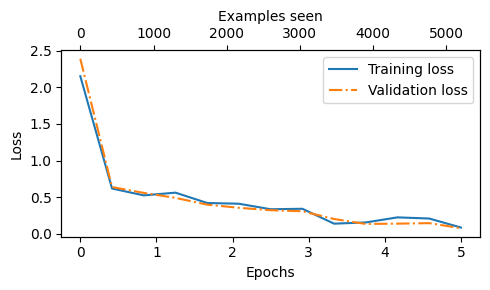

In [130]:
# Creates evenly spaced values representing epoch positions
# for each recorded training loss.
#
# torch.linspace(start, end, steps)
#
# start = 0
# end = num_epochs
# steps = len(train_losses)
#
# Example:
# num_epochs = 5
# len(train_losses) = 11
#
# Result:
# tensor([0.0, 0.5, 1.0, 1.5, ..., 5.0])
#
# These values become the x-axis coordinates for plotting losses.
epochs_tensor = torch.linspace(
    0,
    num_epochs,
    len(train_losses)
)


# Creates evenly spaced values representing the cumulative
# number of training examples processed.
#
# WHAT:
# Generates x-axis positions for the second axis
# ("Examples seen").
#
# Example:
# examples_seen = 20000
# len(train_losses) = 11
#
# Result:
# tensor([    0.,  2000.,  4000., ..., 20000.])
examples_seen_tensor = torch.linspace(
    0,
    examples_seen,
    len(train_losses)
)


# Creates and displays the loss plot.
#
# Parameters:
#
# epochs_tensor:
# Bottom x-axis (epochs)
#
# examples_seen_tensor:
# Top x-axis (examples processed)
#
# train_losses:
# Training loss values
#
# val_losses:
# Validation loss values
#
# Since label is not specified,
# the default value "loss" is used.
plot_values(
    epochs_tensor,
    examples_seen_tensor,
    train_losses,
    val_losses
)

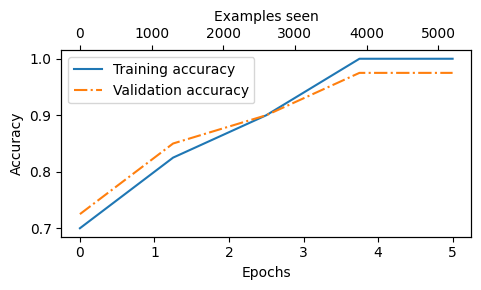

In [131]:
# Creates evenly spaced epoch values for each recorded accuracy value.
#
# Generates x-axis coordinates corresponding to the accuracy measurements.
#
# Example:
# num_epochs = 5
# len(train_accs) = 5
#
# Result:
# tensor([0.0000, 1.2500, 2.5000, 3.7500, 5.0000])
epochs_tensor = torch.linspace(
    0,
    num_epochs,
    len(train_accs)
)


# Creates evenly spaced values representing the total number
# of training examples processed.
#
# Generates x-axis coordinates for the secondary axis
# ("Examples seen").
#
# Example:
# examples_seen = 25000
# len(train_accs) = 5
#
# Result:
# tensor([    0.,  6250., 12500., 18750., 25000.])
examples_seen_tensor = torch.linspace(
    0,
    examples_seen,
    len(train_accs)
)


# Creates and displays the accuracy plot.
#
# epochs_tensor:
# Bottom x-axis (epochs)
#
# examples_seen_tensor:
# Top x-axis (examples processed)
#
# train_accs:
# Training accuracy values
#
# val_accs:
# Validation accuracy values
#
# label="accuracy":
# Sets the y-axis label to "Accuracy"
# and saves the figure as accuracy-plot.pdf
plot_values(
    epochs_tensor,
    examples_seen_tensor,
    train_accs,
    val_accs,
    label="accuracy"
)

In [132]:
# Computes classification accuracy on the entire training dataset.
#
# Iterates through all batches in train_loader and:
# 1. Generates predictions
# 2. Compares predictions with true labels
# 3. Counts correct predictions
# 4. Returns accuracy
#
# Returned value:
# A number between 0 and 1
#
# Example:
# 0.96 → 96% accuracy
train_accuracy = calc_accuracy_loader(
    train_loader,
    model,
    device
)


# Computes classification accuracy on the validation dataset.
#
# Evaluates the model on unseen validation samples.
#
# Returned value:
# Example:
# 0.94
val_accuracy = calc_accuracy_loader(
    val_loader,
    model,
    device
)


# Computes classification accuracy on the test dataset.
#
# Evaluates the model on completely unseen test samples.
#
# Returned value:
# Example:
# 0.93
test_accuracy = calc_accuracy_loader(
    test_loader,
    model,
    device
)


# Converts training accuracy to percentage format and prints it.
#
# Example:
# train_accuracy = 0.96
#
# 0.96 × 100 = 96.00
#
# :.2f displays two digits after the decimal point.
print(f"Training accuracy: {train_accuracy*100:.2f}%")


# Converts validation accuracy to percentage format and prints it.
#
# Example output:
# Validation accuracy: 94.25%
print(f"Validation accuracy: {val_accuracy*100:.2f}%")


# Converts test accuracy to percentage format and prints it.
#
# Example output:
# Test accuracy: 93.87%
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


## **USING THE LLM AS A SPAM CLASSIFIER**
    
Step 1: Prepare inputs to the model

Step 2: Truncate sequences if they too long
    
Step 3: Pad sequences to the longest sequence

Step 4: Add batch dimension

Step 5: Model inference without gradient tracking
    
Step 6: Logits of the last output token

Step 7: Return the classified result

In [133]:
# Defines a function that classifies a text message as
# either "spam" or "not spam".
#
# Parameters:
#
# text:
# Input text to classify.
#
# model:
# Trained GPT-based classifier.
#
# tokenizer:
# GPT tokenizer used to convert text into token IDs.
#
# device:
# CPU, CUDA GPU, or MPS device.
#
# max_length:
# Maximum sequence length used during training.
#
# pad_token_id:
# Token used for padding shorter sequences.
# GPT-2 commonly uses 50256 (end-of-text token).
def classify_review(
    text,
    model,
    tokenizer,
    device,
    max_length=None,
    pad_token_id=50256
):


    # Switches the model into evaluation mode.
    #
    # Disables training-specific behavior such as dropout.
    model.eval()


    # --------------------------------------------------
    # Text → Token IDs
    # --------------------------------------------------

    # Converts the input text into token IDs.
    #
    # Example:
    #
    # "You won $1000"
    #
    # ↓
    #
    # [1639, 1839, 720, 12825]
    input_ids = tokenizer.encode(text)


    # Retrieves the maximum context length supported by the model.
    #
    # pos_emb shape:
    #
    # (1024, 768) for GPT-2 Small
    #
    # shape[0] = 1024
    #
    # Meaning:
    # The model can process up to 1024 tokens.
    supported_context_length = model.pos_emb.weight.shape[0]


    # Book correction:
    #
    # shape[0] = context length (1024)
    #
    # shape[1] = embedding dimension (768)
    #
    # Using shape[1] would incorrectly limit
    # sequences to 768 tokens.
    #
    # Note: In the book, this was originally written as
    # pos_emb.weight.shape[1] by mistake.
    #
    # It didn't break the code but would have caused
    # unnecessary truncation.


    # --------------------------------------------------
    # Sequence Truncation
    # --------------------------------------------------

    # Keeps only the allowed number of tokens.
    #
    # Example:
    #
    # max_length = 120
    #
    # input_ids length = 200
    #
    # Result:
    #
    # First 120 tokens retained.
    input_ids = input_ids[
        :min(max_length, supported_context_length)
    ]


    # --------------------------------------------------
    # Sequence Padding
    # --------------------------------------------------

    # Pads shorter sequences up to max_length.
    #
    # Example:
    #
    # Current:
    # [10, 20, 30]
    #
    # max_length = 6
    #
    # Result:
    # [10, 20, 30, 50256, 50256, 50256]
    input_ids += [pad_token_id] * (
        max_length - len(input_ids)
    )


    # Converts token IDs into a PyTorch tensor.
    #
    # device=device
    #
    # Places tensor on CPU/GPU.
    #
    # unsqueeze(0)
    #
    # Adds batch dimension.
    #
    # Before:
    # (max_length,)
    #
    # After:
    # (1, max_length)
    input_tensor = torch.tensor(
        input_ids,
        device=device
    ).unsqueeze(0)


    # --------------------------------------------------
    # Model Inference
    # --------------------------------------------------

    # Disables gradient tracking.
    with torch.no_grad():

        # Runs the input through the classifier.
        #
        # Output shape:
        #
        # (batch_size, sequence_length, num_classes)
        #
        # Example:
        # (1, 120, 2)
        #
        # [:, -1, :]
        #
        # Selects:
        # - all batch items
        # - last token
        # - all class scores
        #
        # Result shape:
        # (1, 2)
        logits = model(input_tensor)[:, -1, :]


    # Selects the class with the highest score.
    #
    # Example:
    #
    # logits:
    # [[2.1, 0.3]]
    #
    # argmax → 0
    #
    # logits:
    # [[0.5, 3.4]]
    #
    # argmax → 1
    predicted_label = torch.argmax(
        logits,
        dim=-1
    ).item()


    # --------------------------------------------------
    # Final Classification
    # --------------------------------------------------

    # Converts numeric class labels into readable text.
    #
    # Class Mapping:
    #
    # 0 → not spam
    # 1 → spam
    return (
        "spam"
        if predicted_label == 1
        else "not spam"
    )

In [134]:
# Creates a sample message to test the trained spam classifier.
#
# The message contains phrases commonly found in spam:
# - "winner"
# - "specially selected"
# - cash rewards
# - prize offers
#
# The two string literals are automatically concatenated by Python.
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)


# Passes the text through the spam-classification pipeline
# and prints the predicted category.
print(
    classify_review(

        # Input text to classify.
        text_1,

        # Fine-tuned GPT classifier.
        model,

        # GPT tokenizer used to convert text into token IDs.
        tokenizer,

        # Device on which inference is performed
        # (CPU, CUDA GPU, or MPS).
        device,

        # Maximum sequence length used during training.
        #
        # Ensures the input is padded/truncated in the same
        # way as the training examples.
        max_length=train_dataset.max_length
    )
)

spam


In [135]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [136]:
# Saves the trained model's parameters to a file.
#
# model.state_dict() returns a dictionary containing all
# learnable parameters of the model:
#
# - Embedding weights
# - Transformer block weights
# - LayerNorm parameters
# - Classification head weights
#
# The dictionary is then written to disk using torch.save().
torch.save(

    # Dictionary containing the model's learned parameters.
    model.state_dict(),

    # File name where the parameters will be stored.
    "review_classifier.pth"
)

In [137]:
# Loads the saved model parameters from the file.
#
# torch.load() reads the contents of "review_classifier.pth"
# and reconstructs the saved state dictionary.
#
# Returned object:
# A Python dictionary containing all model parameters.
#
# Example:
# {
#     "tok_emb.weight": ...,
#     "pos_emb.weight": ...,
#     ...
#     "out_head.weight": ...,
#     "out_head.bias": ...
# }
model_state_dict = torch.load("review_classifier.pth")


# Loads the saved parameters into the model.
#
# Replaces the model's current parameter values with the
# parameters stored in model_state_dict.
#
# The architecture of the model must match the architecture
# that was used when the checkpoint was saved.
#
# Example:
# Saved:
# Linear(768 → 2)
#
# Current model:
# Linear(768 → 2)
#
# Then loading succeeds.
model.load_state_dict(model_state_dict)

<All keys matched successfully>

# **INSTRUCTION FINE-TUNING**
## **STEP 1: PREPARING DATASET**

In [138]:
# Import module for working with JSON data
import json

# Import module for interacting with the operating system
# (used here to check if a file already exists)
import os

# Import module for downloading data from URLs
import urllib

# Import SSL module for handling secure HTTPS connections
import ssl


# Function to download a JSON file from a URL
# and load its contents into Python
def download_and_load_file(file_path, url):

    # Create an SSL context object
    ssl_context = ssl.create_default_context()

    # Disable hostname verification
    # (useful when SSL certificate validation causes issues)
    ssl_context.check_hostname = False

    # Disable SSL certificate verification
    ssl_context.verify_mode = ssl.CERT_NONE

    # Check whether the file already exists locally
    if not os.path.exists(file_path):

        # Open the URL and download the file contents
        with urllib.request.urlopen(url, context=ssl_context) as response:

            # Read bytes from the response and convert them to text
            text_data = response.read().decode("utf-8")

        # Save the downloaded text into a local file
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    else:
        # If the file already exists, read its contents
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    # Open the JSON file again
    with open(file_path, "r", encoding="utf-8") as file:

        # Convert JSON data into Python objects
        # (list, dictionary, etc.)
        data = json.load(file)

    # Return the loaded data
    return data


# Name of the local file where data will be stored
file_path = "instruction-data.json"

# URL containing the JSON dataset
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

# Download the file (if needed) and load its contents
data = download_and_load_file(file_path, url)

# Print the number of entries in the dataset
print("Number of entries:", len(data))

Number of entries: 1100


In [139]:
# Print the label "Example entry:" followed by the 51st record in the dataset
# (Python indexing starts from 0, so index 50 refers to the 51st entry)
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [140]:
# Print a heading followed by the 1000th entry in the dataset
# (Python uses zero-based indexing, so index 999 refers to the 1000th record)
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


### **CONVERTING INSTRUCTIONS INTO ALPACA FORMAT**

In [141]:
# Function to format a dataset entry into an instruction prompt
def format_input(entry):

    # Create the main instruction section
    # entry['instruction'] contains the task description
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    # Add an Input section only if the input field is not empty
    # If entry["input"] contains text:
    #     "\n\n### Input:\n<input text>"
    # Otherwise:
    #     ""
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    # Return the complete prompt
    return instruction_text + input_text

In [142]:
# Format the 51st dataset entry into the instruction prompt format
# (includes Instruction and optional Input sections)
model_input = format_input(data[50])

# Create the target response section using the corresponding output
# from the dataset entry
desired_response = f"\n\n### Response:\n{data[50]['output']}"

# Print the complete training example:
# Instruction + Input (if present) + Expected Response
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [143]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


### **SPLITTING DATASET INTO TRAIN-TEST-VALIDATION**

In [144]:
# Calculate the number of examples for the training set
# 85% of the entire dataset
train_portion = int(len(data) * 0.85)

# Calculate the number of examples for the test set
# 10% of the entire dataset
test_portion = int(len(data) * 0.1)

# Assign the remaining examples to the validation set
# This ensures all data points are used
val_portion = len(data) - train_portion - test_portion


# Select the first 85% of examples for training
train_data = data[:train_portion]

# Select the next 10% of examples for testing
test_data = data[train_portion:train_portion + test_portion]

# Select the remaining 5% of examples for validation
val_data = data[train_portion + test_portion:]

In [145]:
# Print the number of examples in the training dataset
print("Training set length:", len(train_data))

# Print the number of examples in the validation dataset
print("Validation set length:", len(val_data))

# Print the number of examples in the test dataset
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## **STEP 2: ORGANIZING DATA INTO TRAINING BATCHES**

In [146]:
# Import PyTorch library
import torch

# Import the Dataset base class
# Custom datasets usually inherit from this class
from torch.utils.data import Dataset


# Define a custom dataset class for instruction-following data
class InstructionDataset(Dataset):

    # Constructor method
    # Runs when an object of this class is created
    def __init__(self, data, tokenizer):

        # Store the original dataset
        self.data = data

        # Create an empty list to store tokenized texts
        self.encoded_texts = []

        # Loop through every example in the dataset
        for entry in data:

            # Create the prompt containing Instruction and optional Input
            instruction_plus_input = format_input(entry)

            # Create the Response section
            response_text = f"\n\n### Response:\n{entry['output']}"

            # Combine prompt and response into one training example
            full_text = instruction_plus_input + response_text

            # Convert text into token IDs
            # tokenizer.encode() returns a list of integers
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    # Returns a single item from the dataset
    # Called automatically when using dataset[index]
    def __getitem__(self, index):

        # Return the tokenized example at the specified index
        return self.encoded_texts[index]

    # Returns the number of examples in the dataset
    # Called automatically when using len(dataset)
    def __len__(self):

        # Return total number of entries
        return len(self.data)

In [147]:
# Import the tiktoken library used for GPT-style tokenization
import tiktoken

# Load the GPT-2 tokenizer
# This tokenizer converts text into token IDs and vice versa
tokenizer = tiktoken.get_encoding("gpt2")

# Encode the special GPT token <|endoftext|>
# allowed_special tells the tokenizer to treat this string
# as a special token instead of ordinary text
print(
    tokenizer.encode(
        "<|endoftext|>",
        allowed_special={"<|endoftext|>"}
    )
)

[50256]


In [148]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,   # GPT-2's <|endoftext|> token
    device="cpu"          # Device where tensors will be stored
):

    # Find the longest sequence in the batch
    # Add +1 because we will append one extra token (<|endoftext|>)
    # to every sequence before padding
    batch_max_length = max(len(item) + 1 for item in batch)

    # List to store padded input tensors
    inputs_lst = []

    # Process each sequence in the batch
    for item in batch:

        # Create a copy so the original sequence remains unchanged
        new_item = item.copy()

        # Append the <|endoftext|> token
        new_item += [pad_token_id]

        # Pad shorter sequences up to batch_max_length
        padded = (
            new_item +
            [pad_token_id] * (batch_max_length - len(new_item))
        )

        # Remove the final token
        # (explained below)
        inputs = torch.tensor(padded[:-1])

        # Store the padded sequence
        inputs_lst.append(inputs)

    # Stack all sequences into one tensor
    # Shape: (batch_size, sequence_length)
    inputs_tensor = torch.stack(inputs_lst).to(device)

    # Return the batch tensor
    return inputs_tensor

In [149]:
# First sequence (length = 5)
inputs_1 = [0, 1, 2, 3, 4]

# Second sequence (length = 2)
inputs_2 = [5, 6]

# Third sequence (length = 3)
inputs_3 = [7, 8, 9]

# Combine the sequences into a batch
# A batch is simply a collection of examples
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

# Pass the batch through the custom collate function
# to add padding and convert everything into a tensor
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


#### **CREATING TARGET TOKEN IDS FOR TRAINING**

In [150]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,   # GPT-2 <|endoftext|> token
    device="cpu"          # Device to store tensors (CPU/GPU)
):

    # Find the longest sequence in the batch
    # +1 because we append an <|endoftext|> token
    batch_max_length = max(len(item) + 1 for item in batch)

    # Lists to store input and target sequences
    inputs_lst, targets_lst = [], []

    # Process each sequence in the batch
    for item in batch:

        # Create a copy to avoid modifying the original sequence
        new_item = item.copy()

        # Append <|endoftext|> token
        new_item += [pad_token_id]

        # Pad sequence to the maximum length
        padded = (
            new_item +
            [pad_token_id] * (batch_max_length - len(new_item))
        )

        # Input sequence:
        # remove the last token
        inputs = torch.tensor(padded[:-1])

        # Target sequence:
        # remove the first token (shift right by 1)
        targets = torch.tensor(padded[1:])

        # Store results
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of tensors into a batch tensor
    inputs_tensor = torch.stack(inputs_lst).to(device)

    # Convert target list into a batch tensor
    targets_tensor = torch.stack(targets_lst).to(device)

    # Return both inputs and targets
    return inputs_tensor, targets_tensor

In [151]:
# First sequence (length = 5)
inputs_1 = [0, 1, 2, 3, 4]

# Second sequence (length = 2)
inputs_2 = [5, 6]

# Third sequence (length = 3)
inputs_3 = [7, 8, 9]

# Create a batch containing all sequences
batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

# Generate input-target pairs
inputs, targets = custom_collate_draft_2(batch)

# Print input tensor
print(inputs)

# Print target tensor
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [152]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,      # GPT-2 <|endoftext|> token
    ignore_index=-100,       # Value ignored by CrossEntropyLoss
    allowed_max_length=None, # Optional sequence length limit
    device="cpu"             # CPU or GPU
):

    # Find the longest sequence in the batch
    # +1 because an <|endoftext|> token will be added
    batch_max_length = max(len(item) + 1 for item in batch)

    # Lists for storing processed inputs and targets
    inputs_lst, targets_lst = [], []

    # Process each sequence in the batch
    for item in batch:

        # Create a copy to avoid modifying original data
        new_item = item.copy()

        # Append end-of-text token
        new_item += [pad_token_id]

        # Pad shorter sequences to the maximum length
        padded = (
            new_item +
            [pad_token_id] * (batch_max_length - len(new_item))
        )

        # Input sequence
        inputs = torch.tensor(padded[:-1])

        # Target sequence (shifted by one position)
        targets = torch.tensor(padded[1:])

        # ----------------------------------------------------
        # NEW PART: Ignore extra padding tokens in targets
        # ----------------------------------------------------

        # Find positions containing pad_token_id
        mask = targets == pad_token_id

        # Get indices where mask is True
        indices = torch.nonzero(mask).squeeze()

        # If more than one padding token exists
        if indices.numel() > 1:

            # Keep the first <|endoftext|>
            # Replace remaining padding tokens with -100
            targets[indices[1:]] = ignore_index

        # ----------------------------------------------------
        # NEW PART: Optional truncation
        # ----------------------------------------------------

        # Limit sequence length if requested
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        # Store processed tensors
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Stack into batch tensors
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [153]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [154]:
# Create model output scores (logits)
# Each row represents one training example
# Each column represents a class

logits_1 = torch.tensor(
    [[-1.0, 1.0],   # Example 1: scores for Class 0 and Class 1
     [-0.5, 1.5]]  # Example 2: scores for Class 0 and Class 1
)

# True class labels
# Example 1 belongs to Class 0
# Example 2 belongs to Class 1
targets_1 = torch.tensor([0, 1])

# Compute cross-entropy loss
# Compares predicted logits with true labels
loss_1 = torch.nn.functional.cross_entropy(
    logits_1,
    targets_1
)

# Print the loss value
print(loss_1)

tensor(1.1269)


In [155]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)
tensor(0.7936)
tensor(0.7936)


In [156]:
# Target labels for three examples
# 0  -> Class 0 is correct
# 1  -> Class 1 is correct
# -100 -> Ignore this example when computing loss
targets_3 = torch.tensor([0, 1, -100])

# Compute cross-entropy loss
# By default, CrossEntropyLoss uses ignore_index=-100
# so the third example will not contribute to the loss
loss_3 = torch.nn.functional.cross_entropy(
    logits_2,
    targets_3
)

# Print the computed loss
print(loss_3)

# Compare loss_1 and loss_3
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


## **STEP 3: CREATING DATALOADERS FOR AN INSTRUCTION DATASET**

In [157]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is much faster than on an Apple CPU (as measured on an M3 MacBook Air).
# However, the resulting loss values may be slightly different.

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [158]:
# Imports the partial function, which allows us to create a new function
# by fixing some arguments of an existing function in advance.
from functools import partial

# Creates a customized version of custom_collate_fn with the device
# and allowed_max_length arguments already set.
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [159]:
# Imports the DataLoader class used to load data in batches during training and evaluation.
from torch.utils.data import DataLoader


# Sets the number of worker processes used for loading data.
# 0 means data loading happens in the main process.
num_workers = 0

# Specifies the number of samples to include in each batch.
batch_size = 8

# Sets the random seed to make shuffling and other random operations reproducible.
torch.manual_seed(123)

# Creates a training dataset by converting the training data into tokenized examples.
train_dataset = InstructionDataset(train_data, tokenizer)

# Creates a DataLoader for the training dataset.
train_loader = DataLoader(
    train_dataset,                    # Dataset containing training samples.
    batch_size=batch_size,            # Loads 8 samples per batch.
    collate_fn=customized_collate_fn, # Processes and combines samples into a batch.
    shuffle=True,                     # Randomly shuffles data at the start of each epoch.
    drop_last=True,                   # Drops the final batch if it contains fewer than 8 samples.
    num_workers=num_workers           # Uses the specified number of worker processes.
)

# Creates a validation dataset by converting validation data into tokenized examples.
val_dataset = InstructionDataset(val_data, tokenizer)

# Creates a DataLoader for the validation dataset.
val_loader = DataLoader(
    val_dataset,                      # Dataset containing validation samples.
    batch_size=batch_size,            # Loads 8 samples per batch.
    collate_fn=customized_collate_fn, # Processes and combines samples into a batch.
    shuffle=False,                    # Keeps data order unchanged during validation.
    drop_last=False,                  # Keeps the final smaller batch if it exists.
    num_workers=num_workers           # Uses the specified number of worker processes.
)

# Creates a test dataset by converting test data into tokenized examples.
test_dataset = InstructionDataset(test_data, tokenizer)

# Creates a DataLoader for the test dataset.
test_loader = DataLoader(
    test_dataset,                     # Dataset containing test samples.
    batch_size=batch_size,            # Loads 8 samples per batch.
    collate_fn=customized_collate_fn, # Processes and combines samples into a batch.
    shuffle=False,                    # Keeps data order unchanged during testing.
    drop_last=False,                  # Keeps the final smaller batch if it exists.
    num_workers=num_workers           # Uses the specified number of worker processes.
)

In [160]:
# Prints a heading to indicate that the following output
# belongs to the training DataLoader.
print("Train loader:")

# Iterates through the training DataLoader one batch at a time.
# Each batch contains:
#   inputs  -> tokenized input sequences
#   targets -> corresponding target labels/tokens
for inputs, targets in train_loader:

    # Displays the shape of the input tensor and target tensor
    # for the current batch.
    # Example output:
    # torch.Size([8, 1024]) torch.Size([8, 1024])
    # where:
    #   8     = batch size
    #   1024  = sequence length
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

## **STEP 4: LOADING A PRETRAINED LLM**

In [161]:
# Imports the function used to download a pretrained GPT-2 model
# and load its configuration settings and weight parameters.
from gpt_download3 import download_and_load_gpt2


# Defines configuration settings that are common to all GPT-2 model sizes.
BASE_CONFIG = {

    # Total number of tokens in GPT-2's vocabulary.
    "vocab_size": 50257,

    # Maximum number of tokens the model can process at once.
    "context_length": 1024,

    # Dropout probability.
    # Set to 0.0 because we are using a pretrained model for inference/fine-tuning.
    "drop_rate": 0.0,

    # Enables bias terms in query, key, and value projection layers.
    "qkv_bias": True
}


# Stores architecture-specific settings for different GPT-2 variants.
model_configs = {

    # GPT-2 Small: 124 million parameters.
    "gpt2-small (124M)": {
        "emb_dim": 768,   # Embedding dimension
        "n_layers": 12,   # Number of transformer blocks
        "n_heads": 12     # Number of attention heads
    },

    # GPT-2 Medium: 355 million parameters.
    "gpt2-medium (355M)": {
        "emb_dim": 1024,
        "n_layers": 24,
        "n_heads": 16
    },

    # GPT-2 Large: 774 million parameters.
    "gpt2-large (774M)": {
        "emb_dim": 1280,
        "n_layers": 36,
        "n_heads": 20
    },

    # GPT-2 XL: 1.558 billion parameters.
    "gpt2-xl (1558M)": {
        "emb_dim": 1600,
        "n_layers": 48,
        "n_heads": 25
    },
}


# Selects the GPT-2 model version to use.
CHOOSE_MODEL = "gpt2-medium (355M)"


# Adds the architecture settings of the selected model
# into the base configuration dictionary.
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])


# Extracts only the model size string.
# Example:
# "gpt2-medium (355M)" -> "355M"
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")


# Downloads the selected pretrained GPT-2 model (if not already present)
# and loads:
#   settings -> model configuration information
#   params   -> pretrained weight tensors
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)


# Creates a GPTModel instance using the final configuration.
model = GPTModel(BASE_CONFIG)


# Copies the pretrained GPT-2 weights into the model.
load_weights_into_gpt(model, params)


# Switches the model to evaluation mode.
# This disables training-specific behaviors such as dropout.
model.eval();

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 159kiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 643kiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verificati

In [162]:
# Sets the random seed to 123 to ensure reproducible results.
# Any random operations performed afterward will produce
# the same output each time the code is run.
torch.manual_seed(123)

# Retrieves the first validation example from val_data
# and formats it into the instruction prompt expected by GPT.
# The format_input() function typically combines the instruction,
# input, and prompt template into a single text string.
input_text = format_input(val_data[0])

# Displays the formatted input prompt.
# This allows us to inspect exactly what text will be fed into the GPT model for generation.
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [163]:
# Generates a response from the GPT model based on the input prompt.
# The output is returned as token IDs (integer representations of words/subwords).
token_ids = generate(

    # The pretrained GPT model used for text generation.
    model=model,

    # Converts the input text prompt into token IDs that GPT can process.
    idx=text_to_token_ids(input_text, tokenizer),

    # Specifies the maximum number of new tokens the model can generate.
    # Generation will stop after producing 35 new tokens unless EOS is encountered first.
    max_new_tokens=35,

    # Sets the maximum context length the model can use.
    # For GPT-2, this is typically 1024 tokens.
    context_size=BASE_CONFIG["context_length"],

    # End-of-sequence token ID.
    # If GPT generates this token, text generation stops immediately.
    eos_id=50256,
)

# Converts the generated token IDs back into readable text.
# This transforms the model's numerical output into natural language.
generated_text = token_ids_to_text(token_ids, tokenizer)

In [164]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the
### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the
### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## **STEP 5: FINETUNING THE LLM ON INSTRUCTION DATA**

In [165]:
# Computes the loss for a single batch of data.
def calc_loss_batch(input_batch, target_batch, model, device):

    # Moves the input and target tensors to the specified device (CPU/GPU).
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)

    # Passes the input batch through the model to obtain prediction logits.
    logits = model(input_batch)

    # Computes the cross-entropy loss between predicted logits and target tokens.
    # flatten(0, 1) merges the batch and sequence dimensions so that
    # CrossEntropyLoss receives tensors of shape:
    # logits  -> [batch_size * seq_length, vocab_size]
    # targets -> [batch_size * seq_length]
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    # Returns the computed loss value.
    return loss


# Computes the average loss over multiple batches from a DataLoader.
def calc_loss_loader(data_loader, model, device, num_batches=None):

    # Initializes a variable to accumulate losses.
    total_loss = 0.

    # Checks whether the DataLoader is empty.
    if len(data_loader) == 0:

        # Returns NaN if no batches are available.
        return float("nan")

    # If num_batches is not specified, evaluate all batches.
    elif num_batches is None:
        num_batches = len(data_loader)

    else:
        # Ensures num_batches does not exceed the number of batches
        # available in the DataLoader.
        num_batches = min(num_batches, len(data_loader))

    # Iterates through the DataLoader batch by batch.
    for i, (input_batch, target_batch) in enumerate(data_loader):

        # Processes only the requested number of batches.
        if i < num_batches:

            # Computes loss for the current batch.
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            # Converts the tensor loss into a Python scalar and accumulates it.
            total_loss += loss.item()

        else:
            # Stops once the required number of batches has been processed.
            break

    # Returns the average loss across all evaluated batches.
    return total_loss / num_batches


# Trains the model using a simple training loop.
def train_model_simple(
        model,
        train_loader,
        val_loader,
        optimizer,
        device,
        num_epochs,
        eval_freq,
        eval_iter,
        start_context,
        tokenizer):

    # Stores training losses recorded during training.
    train_losses = []

    # Stores validation losses recorded during training.
    val_losses = []

    # Stores the number of tokens processed at each evaluation point.
    track_tokens_seen = []

    # Tracks total tokens processed during training.
    tokens_seen = 0

    # Tracks the total number of optimization steps.
    global_step = -1

    # Main epoch loop.
    for epoch in range(num_epochs):

        # Switches the model to training mode.
        # Enables dropout and other training-specific layers.
        model.train()

        # Iterates through all batches in the training set.
        for input_batch, target_batch in train_loader:

            # Clears gradients from the previous optimization step.
            optimizer.zero_grad()

            # Computes the loss for the current batch.
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            # Performs backpropagation to compute gradients.
            loss.backward()

            # Updates model parameters using the optimizer.
            optimizer.step()

            # Counts the total number of tokens processed in this batch.
            # numel() returns the total number of elements in input_batch.
            tokens_seen += input_batch.numel()

            # Increments the training step counter.
            global_step += 1

            # Performs periodic evaluation during training.
            if global_step % eval_freq == 0:

                # Computes training and validation losses.
                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    eval_iter
                )

                # Records the training loss.
                train_losses.append(train_loss)

                # Records the validation loss.
                val_losses.append(val_loss)

                # Records the total tokens processed so far.
                track_tokens_seen.append(tokens_seen)

                # Displays training progress.
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )

        # Generates a sample response after each epoch
        # to monitor qualitative model improvements.
        generate_and_print_sample(
            model,
            tokenizer,
            device,
            start_context
        )

    # Returns recorded training statistics.
    return train_losses, val_losses, track_tokens_seen

In [166]:
# Moves the model and all its parameters to the specified device.
# The device can be a CPU or GPU depending on the system configuration.
model.to(device)

# Sets the random seed for reproducibility.
# This ensures that any random operations produce the same results
# every time the code is executed.
torch.manual_seed(123)

# Disables gradient computation temporarily.
# This reduces memory usage and speeds up evaluation since
# gradients are not needed when only calculating losses.
with torch.no_grad():

    # Computes the average training loss using the first 5 batches
    # from the training DataLoader.
    train_loss = calc_loss_loader(
        train_loader,
        model,
        device,
        num_batches=5
    )

    # Computes the average validation loss using the first 5 batches
    # from the validation DataLoader.
    val_loss = calc_loss_loader(
        val_loader,
        model,
        device,
        num_batches=5
    )

# Displays the average training loss.
print("Training loss:", train_loss)

# Displays the average validation loss.
print("Validation loss:", val_loss)

Training loss: 3.82590913772583
Validation loss: 3.7619335651397705


In [167]:
# Imports Python's built-in time module.
# It is used here to measure how long the training process takes.
import time


# Records the current time (in seconds) before training starts.
# This will later be used to calculate the total training duration.
start_time = time.time()


# Sets the random seed to ensure reproducible training results.
# The same initialization and random operations will occur
# each time the code is executed.
torch.manual_seed(123)


# Creates an AdamW optimizer for updating the model parameters.
optimizer = torch.optim.AdamW(

    # Specifies the parameters of the model that should be optimized.
    model.parameters(),

    # Learning rate controls the size of weight updates.
    # A small value (0.00005) helps fine-tune the pretrained model carefully.
    lr=0.00005,

    # Weight decay applies L2 regularization to reduce overfitting.
    weight_decay=0.1
)


# Specifies the number of complete passes through the training dataset.
num_epochs = 1


# Starts the training process.
# The function returns:
#   train_losses -> training loss values recorded during training
#   val_losses   -> validation loss values recorded during training
#   tokens_seen  -> cumulative number of tokens processed
train_losses, val_losses, tokens_seen = train_model_simple(

    # GPT model being fine-tuned.
    model,

    # DataLoader containing training batches.
    train_loader,

    # DataLoader containing validation batches.
    val_loader,

    # Optimizer used to update model weights.
    optimizer,

    # Device where computations occur (CPU/GPU).
    device,

    # Number of training epochs.
    num_epochs=num_epochs,

    # Perform evaluation every 5 training steps.
    eval_freq=5,

    # Use 5 batches when computing train/validation loss.
    eval_iter=5,

    # Initial prompt used for generating a sample response
    # after each epoch.
    start_context=format_input(val_data[0]),

    # Tokenizer used for encoding and decoding text.
    tokenizer=tokenizer
)


# Records the current time immediately after training finishes.
end_time = time.time()


# Computes the total training time in minutes.
# (end_time - start_time) gives the duration in seconds.
execution_time_minutes = (end_time - start_time) / 60


# Prints the total training time rounded to 2 decimal places.
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.103
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.533, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.568, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.604, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.710
Ep 1 (Step 000090): Train loss 0.563, Val loss

In [168]:
# Imports Matplotlib's plotting module for creating graphs and visualizations.
import matplotlib.pyplot as plt

# Imports MaxNLocator, which helps control tick marks on axes.
# It is used here to ensure only integer values appear on the x-axis.
from matplotlib.ticker import MaxNLocator


# Defines a function for plotting training and validation losses.
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):

    # Creates a figure and a set of axes.
    # figsize=(5,3) sets the width and height of the plot in inches.
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs

    # Draws the training loss curve.
    ax1.plot(
        epochs_seen,
        train_losses,
        label="Training loss"
    )

    # Draws the validation loss curve using a dash-dot line style.
    ax1.plot(
        epochs_seen,
        val_losses,
        linestyle="-.",
        label="Validation loss"
    )

    # Labels the primary x-axis.
    ax1.set_xlabel("Epochs")

    # Labels the y-axis.
    ax1.set_ylabel("Loss")

    # Displays the legend showing which line corresponds
    # to training loss and validation loss.
    ax1.legend(loc="upper right")

    # Ensures only integer values appear on the epoch axis.
    # Example: 0, 1, 2, 3 instead of 0.5, 1.5, etc.
    ax1.xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

    # Create a second x-axis for tokens seen

    # Creates a second x-axis at the top of the figure.
    # This axis shares the same y-axis as ax1.
    ax2 = ax1.twiny()

    # Creates an invisible plot used only for aligning
    # token counts with the loss values.
    # alpha=0 makes the line completely transparent.
    ax2.plot(
        tokens_seen,
        train_losses,
        alpha=0
    )

    # Labels the top x-axis.
    ax2.set_xlabel("Tokens seen")

    # Automatically adjusts spacing so labels and axes
    # do not overlap.
    fig.tight_layout()

    # Saves the figure as a PDF file.
    plt.savefig("loss-plot.pdf")

    # Displays the plot on the screen.
    plt.show()

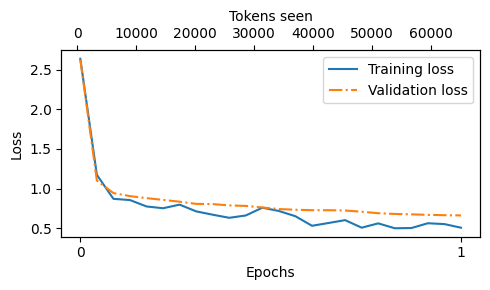

In [169]:
# Creates a tensor containing evenly spaced epoch values.
# These values will be used as x-axis coordinates when plotting losses.
#
# Parameters:
#   start = 0
#   end = num_epochs
#   steps = len(train_losses)
#
# Example:
# If num_epochs = 1 and len(train_losses) = 6,
# the output might be:
# tensor([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
epochs_tensor = torch.linspace(
    0,
    num_epochs,
    len(train_losses)
)

# Calls the plotting function to visualize training and validation losses.
#
# Arguments:
#   epochs_tensor -> x-axis values representing training progress in epochs
#   tokens_seen   -> token counts used for the secondary x-axis
#   train_losses  -> recorded training loss values
#   val_losses    -> recorded validation loss values
plot_losses(
    epochs_tensor,
    tokens_seen,
    train_losses,
    val_losses
)

## **STEP 6: EXTRACTING AND SAVING RESPONSES**

In [170]:
# Sets the random seed to ensure reproducible text generation.
# Using the same seed helps produce the same generated outputs
# across multiple runs when sampling is involved.
torch.manual_seed(123)


# Iterates through the first three examples in the test dataset.
for entry in test_data[:3]:

    # Converts the current test example into the instruction format
    # expected by the GPT model.
    input_text = format_input(entry)

    # Generates a response from the model.
    token_ids = generate(

        # Fine-tuned GPT model.
        model=model,

        # Converts the input prompt into token IDs and moves them
        # to the specified device (CPU/GPU).
        idx=text_to_token_ids(
            input_text,
            tokenizer
        ).to(device),

        # Maximum number of new tokens the model is allowed to generate.
        max_new_tokens=256,

        # Maximum context length supported by the model.
        context_size=BASE_CONFIG["context_length"],

        # End-of-sequence token.
        # Generation stops if this token is produced.
        eos_id=50256
    )

    # Converts the generated token IDs back into readable text.
    generated_text = token_ids_to_text(
        token_ids,
        tokenizer
    )

    # Extracts only the model-generated response.
    response_text = (

        # Removes the original prompt from the generated text.
        generated_text[len(input_text):]

        # Removes any remaining "### Response:" marker.
        .replace("### Response:", "")

        # Removes leading and trailing whitespace.
        .strip()
    )

    # Displays the original formatted prompt.
    print(input_text)

    # Displays the correct answer from the dataset.
    print(
        f"\nCorrect response:\n>> {entry['output']}"
    )

    # Displays the model-generated answer.
    print(
        f"\nModel response:\n>> {response_text.strip()}"
    )

    # Prints a separator line between examples.
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is a type of cloud that typically forms in the atmosphere over a region of high pressure. It typically produces a strong wind that blows across the area, creating a dense, dense cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruc

In [171]:
# Imports tqdm, a library used to display a progress bar
# while iterating through loops.
from tqdm import tqdm


# Iterates through all examples in the test dataset.
# enumerate() provides:
#   i     -> index of the current example
#   entry -> current test example
#
# tqdm() wraps the loop and displays a progress bar.
# total=len(test_data) tells tqdm how many items will be processed.
for i, entry in tqdm(
    enumerate(test_data),
    total=len(test_data)
):

    # Formats the current test example into the instruction prompt
    # expected by the GPT model.
    input_text = format_input(entry)

    # Generates a response using the fine-tuned model.
    token_ids = generate(

        # GPT model used for generation.
        model=model,

        # Converts the prompt into token IDs and moves them
        # to the selected device (CPU/GPU).
        idx=text_to_token_ids(
            input_text,
            tokenizer
        ).to(device),

        # Maximum number of new tokens that can be generated.
        max_new_tokens=256,

        # Maximum context length supported by GPT-2.
        context_size=BASE_CONFIG["context_length"],

        # End-of-sequence token.
        eos_id=50256
    )

    # Converts generated token IDs back into human-readable text.
    generated_text = token_ids_to_text(
        token_ids,
        tokenizer
    )

    # Extracts only the generated response.
    response_text = (

        # Removes the original prompt.
        generated_text[len(input_text):]

        # Removes any remaining response marker.
        .replace("### Response:", "")

        # Removes extra whitespace.
        .strip()
    )

    # Adds the generated response as a new field
    # inside the current test example.
    test_data[i]["model_response"] = response_text


# Opens a JSON file in write mode.
# If the file does not exist, it will be created.
with open(
    "instruction-data-with-response.json",
    "w"
) as file:

    # Saves the updated test dataset to disk.
    # Each entry now contains:
    #   instruction
    #   input
    #   output
    #   model_response
    #
    # indent=4 makes the JSON file easier to read.
    json.dump(
        test_data,
        file,
        indent=4
    )

100%|██████████| 110/110 [01:33<00:00,  1.17it/s]


In [172]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


In [173]:
# Imports Python's regular expression (regex) module.
# It is used here to modify the model name when creating a filename.
import re


# Creates a filename for saving the fine-tuned model.
#
# re.sub(r'[ ()]', '', CHOOSE_MODEL) removes:
#   - spaces (' ')
#   - opening parenthesis ('(')
#   - closing parenthesis (')')
#
# Example:
#   "gpt2-medium (355M)"
# becomes:
#   "gpt2-medium355M"
#
# Then "-sft.pth" is appended:
#   "gpt2-medium355M-sft.pth"
#
# SFT = Supervised Fine-Tuning
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft.pth"


# Saves the model's learned parameters (state dictionary)
# to the specified file.
#
# state_dict() contains all trainable weights and biases
# of the neural network.
torch.save(
    model.state_dict(),
    file_name
)


# Displays the name of the saved model file.
print(f"Model saved as {file_name}")


# To load the saved model later:
#
# 1. Create a model with the same architecture.
# 2. Load the saved parameters into that model.
#
# Example:
# model.load_state_dict(
#     torch.load("gpt2-medium355M-sft.pth")
# )

Model saved as gpt2-medium355M-sft.pth


## **STEP 7: EVALUATING THE FINE-TUNED LLM**

In [177]:
!apt-get update -qq
!apt-get install -y zstd

!curl -fsSL https://ollama.com/install.sh | sh

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 76 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (16.7 MB/s)
Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Cleaning up old version at /usr/local/lib/ollama
>>> In

In [178]:
import subprocess
import time

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)
print("Ollama server started")

Ollama server started


In [179]:
!ollama pull llama3

In [180]:
!ollama run llama3 "Hello"

Hello! It's nice to meet you. Is there something I can help you with, or wo
would you like to chat?



In [181]:
# Imports the psutil library.
# psutil provides information about running processes,
# system utilization, memory, CPU usage, and more.
import psutil


# Defines a function that checks whether a specific process
# is currently running on the system.
def check_if_running(process_name):

    # Initially assume the process is not running.
    running = False

    # Iterates through all currently running processes.
    # ["name"] tells psutil to retrieve only the process name,
    # making the iteration more efficient.
    for proc in psutil.process_iter(["name"]):

        # Checks whether the specified process name
        # appears in the current process name.
        #
        # Example:
        # process_name = "ollama"
        # proc.info["name"] = "ollama.exe"
        #
        # Result: True
        if process_name in proc.info["name"]:

            # Process found.
            running = True

            # Stops searching because the process
            # has already been located.
            break

    # Returns True if the process was found,
    # otherwise returns False.
    return running


# Checks whether the Ollama process is running.
# The result will be either:
#   True
#   False
ollama_running = check_if_running("ollama")


# If Ollama is not running,
# stop the program immediately.
if not ollama_running:

    # Raises an exception with a custom error message.
    raise RuntimeError(
        "Ollama not running. Launch ollama before proceeding."
    )


# Prints the current status of the Ollama process.
print(
    "Ollama running:",
    check_if_running("ollama")
)

Ollama running: True


In [182]:
# Imports Python's urllib.request module.
# It is used to send HTTP requests to web services and APIs.
import urllib.request


# Defines a function that sends a prompt to an Ollama model
# and returns the generated response.
def query_model(

    # User input or instruction to send to the model.
    prompt,

    # Specifies which Ollama model to use.
    # Default model is llama3.
    model="llama3",

    # URL of the Ollama chat API endpoint.
    url="http://localhost:11434/api/chat"
):

    # Create the request payload as a Python dictionary.
    data = {

        # Name of the model that will generate the response.
        "model": model,

        # Chat messages sent to the model.
        # Here we send a single user message.
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],

        # Model configuration options.
        "options": {

            # Fixed random seed for reproducible responses.
            "seed": 123,

            # Temperature controls randomness.
            # 0 means highly deterministic output.
            "temperature": 0,

            # Maximum context window size.
            # Determines how many tokens can be processed.
            "num_ctx": 2048
        }
    }


    # Converts the dictionary into JSON format.
    # encode("utf-8") transforms the JSON string into bytes,
    # which are required for HTTP transmission.
    payload = json.dumps(data).encode("utf-8")


    # Creates an HTTP POST request.
    request = urllib.request.Request(

        # API endpoint.
        url,

        # JSON payload to send.
        data=payload,

        # HTTP method.
        method="POST"
    )

    # Adds a header indicating that JSON data is being sent.
    request.add_header(
        "Content-Type",
        "application/json"
    )


    # Variable that will store the complete model response.
    response_data = ""


    # Sends the request to the Ollama server.
    with urllib.request.urlopen(request) as response:

        # Read the streamed response line by line.
        while True:

            # Reads one line from the response stream
            # and converts it from bytes to text.
            line = response.readline().decode("utf-8")

            # Stop when no more data is available.
            if not line:
                break

            # Converts the JSON response line into a Python dictionary.
            response_json = json.loads(line)

            # Extracts the generated text from the response
            # and appends it to the accumulated output.
            response_data += response_json["message"]["content"]


    # Returns the complete generated response.
    return response_data

In [183]:
# Specifies which Ollama model should be used for the query.
# Here, the Llama 3 model is selected.
model = "llama3"


# Sends the prompt to the selected model using the query_model() function.
#
# Arguments:
#   "What do Llamas eat?" -> user prompt/question
#   model                -> model name ("llama3")
#
# The function:
#   1. Creates a JSON request payload
#   2. Sends it to the Ollama API
#   3. Receives the generated response
#   4. Returns the response text
result = query_model(
    "What do Llamas eat?",
    model
)


# Displays the model's generated response.
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy munching on dry hay as a snack or as a supplement to their grazing.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their feed. However, it's essential to provide these grains in moderation, as they can be high in calories and low in fiber.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach. These treats are great for providing essential vitamins and minerals.
5. Minerals: Llamas need access to mineral supplements, which can include salt, calcium, and phosphorus. You can provide these minerals in the form of loose minerals or blocks.

Som

In [184]:
# Iterates through the first three examples in the test dataset.
for entry in test_data[:3]:

    # Creates an evaluation prompt for the Llama 3 judge model.
    # The prompt contains:
    #   1. The original instruction/input
    #   2. The correct dataset response
    #   3. The model-generated response
    #   4. A request to score the response from 0 to 100
    prompt = (

        # Provides the original task given to the model.
        f"Given the input `{format_input(entry)}` "

        # Provides the ground-truth (expected) answer.
        f"and correct output `{entry['output']}`, "

        # Provides the model's generated answer.
        f"score the model response `{entry['model_response']}`"

        # Requests a numerical score.
        f" on a scale from 0 to 100, where 100 is the best score. "
    )

    # Prints a heading for the reference answer.
    print("\nDataset response:")

    # Displays the correct answer from the dataset.
    print(">>", entry['output'])

    # Prints a heading for the generated answer.
    print("\nModel response:")

    # Displays the model-generated response.
    print(">>", entry["model_response"])

    # Prints a heading for the score.
    print("\nScore:")

    # Sends the evaluation prompt to Llama 3.
    # The judge model compares:
    #   Correct Response
    #   vs
    #   Model Response
    # and returns a score.
    print(">>", query_model(prompt))

    # Prints a separator line between examples.
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> I'd rate the model response "The car is as fast as a bullet." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to something else (in this case, a bullet).
* The comparison is relevant and makes sense, as bullets are known for their high velocity.
* The phrase "as fast as" is used consistently in both the original sentence and the rewritten one, which helps maintain clarity and coherence.

The only reason I wouldn't give it a perfect score is that some people might not immediately think of bullets when they hear "fast," whereas lightning is often an intuitive comparison for speed. However, "as fast as a bullet" is still a strong simile that effectively conveys the idea that the car is very quick!

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

In [185]:
# Defines a function that evaluates model-generated responses
# using another LLM (e.g., Llama 3) as an automatic judge.
def generate_model_scores(

    # Dataset containing instructions, outputs,
    # and model-generated responses.
    json_data,

    # Name of the field containing the model response
    # to be evaluated.
    json_key,

    # Judge model used for scoring.
    # Default: llama3.
    model="llama3"
):

    # Creates an empty list to store the scores.
    scores = []

    # Iterates through all dataset entries.
    #
    # tqdm displays a progress bar during evaluation.
    for entry in tqdm(
        json_data,
        desc="Scoring entries"
    ):

        # Constructs a prompt for the judge model.
        # The prompt includes:
        #   - Original instruction
        #   - Correct output
        #   - Model-generated response
        #   - Request for a score from 0 to 100
        prompt = (

            # Original task.
            f"Given the input `{format_input(entry)}` "

            # Ground-truth answer.
            f"and correct output `{entry['output']}`, "

            # Generated response to evaluate.
            f"score the model response `{entry[json_key]}`"

            # Scoring scale.
            f" on a scale from 0 to 100, where 100 is the best score. "

            # Forces the judge model to return only a number.
            f"Respond with the integer number only."
        )

        # Sends the evaluation prompt to the judge model.
        # Example result:
        #   "95"
        score = query_model(
            prompt,
            model
        )

        try:

            # Converts the returned text score
            # into an integer.
            scores.append(
                int(score)
            )

        except ValueError:

            # Handles cases where the judge model
            # returns something other than an integer.
            #
            # Example:
            # "I would give this response a score of 90."
            #
            # int() would fail in this case.
            print(
                f"Could not convert score: {score}"
            )

            # Skip this example and continue.
            continue

    # Returns the list of successfully collected scores.
    return scores